<a href="https://colab.research.google.com/github/raw-fun/Colab-Script/blob/main/Boss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# ══════════════════════════════════════════════════════════════
# CELL 01 — MASTER FOUNDATION
# Package install + imports + Enums + Config + Helpers
# ══════════════════════════════════════════════════════════════

import subprocess
subprocess.run(
    ["pip", "install", "-q",
     "Pillow>=10.0.0,<12.0.0", "qrcode[pil]",
     "fpdf2", "ipywidgets", "tqdm"],
    capture_output=True
)

import os, sys, io, json, csv, zipfile, textwrap
import time, math, random, base64, hashlib
import urllib.request, urllib.error
import dataclasses
import inspect
import builtins
import traceback
from pathlib import Path
from datetime import datetime
from typing import Optional, Dict, List, Tuple, Any, Union
from dataclasses import dataclass, field, asdict
from enum import Enum
from collections import defaultdict

import numpy as np
import cv2
from PIL import (
    Image, ImageDraw, ImageFont,
    ImageFilter, ImageEnhance, ImageChops, ImageColor
)
import qrcode

try:
    from fpdf import FPDF
    FPDF_AVAILABLE = True
except ImportError:
    FPDF_AVAILABLE = False

try:
    from tqdm.notebook import tqdm
except ImportError:
    class tqdm:
        def __init__(self, iterable=None, total=None, desc="", **kw):
            self.iterable = iterable or []
            self.n = 0
        def __iter__(self):
            for x in self.iterable:
                yield x; self.n += 1
        def __enter__(self): return self
        def __exit__(self, *a): pass
        def update(self, n=1): self.n += n
        def set_postfix(self, d=None, **kw): pass

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ── Availability flags ────────────────────────────────────────
REMBG_AVAILABLE   = False
SKLEARN_AVAILABLE = False
CV2_AVAILABLE     = True  # cv2 already imported above

try:
    import rembg as _rembg
    REMBG_AVAILABLE = True
except ImportError:
    pass
try:
    import sklearn as _sk
    SKLEARN_AVAILABLE = True
except ImportError:
    pass

# Global scope — সব cell থেকে access করা যাবে
builtins.REMBG_AVAILABLE    = REMBG_AVAILABLE
builtins.SKLEARN_AVAILABLE  = SKLEARN_AVAILABLE
builtins.CV2_AVAILABLE      = CV2_AVAILABLE
builtins.FPDF_AVAILABLE     = FPDF_AVAILABLE

print(f"✅ NumPy {np.__version__} | Pillow {Image.__version__} | OpenCV {cv2.__version__}")

# ══════════════════════════════════════════════════════════════
# SECTION A — ENUMS
# ══════════════════════════════════════════════════════════════

class GradientDirection(Enum):
    VERTICAL   = "vertical"
    HORIZONTAL = "horizontal"
    DIAGONAL   = "diagonal"
    RADIAL     = "radial"

class TextureType(Enum):
    NONE      = "none"
    PAPER     = "paper"
    GRAIN     = "grain"
    GEOMETRIC = "geometric"
    LINES     = "lines"
    DOTS      = "dots"

class ImageShape(Enum):
    CIRCLE         = "circle"
    STAR           = "star"
    HEXAGON        = "hexagon"
    HEART          = "heart"
    ROUNDED_SQUARE = "rounded_square"
    DIAMOND        = "diamond"
    TRIANGLE       = "triangle"

class QRStyle(Enum):
    SQUARE  = "square"
    ROUNDED = "rounded"
    DOTS    = "dots"

class TextEffect(Enum):
    NONE     = "none"
    GRADIENT = "gradient"
    NEON     = "neon"
    OUTLINED = "outlined"
    EMBOSSED = "embossed"
    SHADOW   = "shadow"

# ══════════════════════════════════════════════════════════════
# SECTION B — CONFIG
# ══════════════════════════════════════════════════════════════

@dataclass
class Config:
    # Directories
    FONT_DIR:        str  = "fonts"
    OUTPUT_DIR:      str  = "outputs"
    EXPORT_DIR:      str  = "exports"
    BULK_DIR:        str  = "bulk"
    BRAND_DIR:       str  = "brand_kits"
    ASSET_DIR:       str  = "assets"
    CACHE_DIR:       str  = "cache"
    TEMP_DIR:        str  = "temp"
    # Canvas
    DEFAULT_WIDTH:   int  = 1080
    DEFAULT_HEIGHT:  int  = 1080
    DEFAULT_DPI:     int  = 96
    MAX_CANVAS_SIZE: int  = 5000
    # Quality
    JPEG_QUALITY:    int  = 93
    WEBP_QUALITY:    int  = 88
    # Processing
    MAX_WORKERS:     int  = 2
    CHUNK_SIZE:      int  = 10
    MAX_BULK:        int  = 500
    RETRY_COUNT:     int  = 3
    TIMEOUT:         int  = 30
    THREAD_POOL:     int  = 2
    # Features
    CACHE_ENABLED:   bool = True
    PROGRESS_BAR:    bool = True
    AUTO_SAVE:       bool = True
    TIMESTAMP_FILES: bool = True
    WATERMARK:       bool = False
    WATERMARK_TEXT:  str  = "ColabCanvas"
    OUTPUT_PREFIX:   str  = "bulk_"
    REPORT_FORMAT:   str  = "json"
    ZIP_COMPRESSION: int  = 6
    PREVIEW_SIZE:    int  = 400
    LOG_LEVEL:       str  = "INFO"

    def create_dirs(self):
        for d in [self.FONT_DIR, self.OUTPUT_DIR,
                  self.EXPORT_DIR, self.BULK_DIR,
                  self.BRAND_DIR, self.ASSET_DIR,
                  self.CACHE_DIR, self.TEMP_DIR]:
            os.makedirs(d, exist_ok=True)

CONFIG = Config()
CONFIG.create_dirs()

# ══════════════════════════════════════════════════════════════
# SECTION C — CONSTANTS
# ══════════════════════════════════════════════════════════════

FONT_SCALE = {
    "display":     96,  "display_sm":  80,  "display_md":  96,
    "display_lg": 120,  "display_xl": 144,
    "h1": 80, "h2": 64, "h3": 52, "h4": 42, "h5": 34,
    "h1_sm": 64, "h2_sm": 52, "h3_sm": 42,
    "h1_lg": 96, "h2_lg": 80, "h3_lg": 64,
    "subtitle": 30, "body_lg": 26, "body": 22,
    "body_sm": 18, "caption": 16, "micro": 13,
    "xl": 80, "lg": 64, "md": 52, "sm": 34, "xs": 22,
    "2xs": 16, "3xs": 13, "xxl": 100, "giant": 140,
    "huge": 120, "hero": 110, "jumbo": 130, "tiny": 12,
    "price": 88, "price_lg": 110, "price_sm": 64,
    "tag": 48, "tag_sm": 36, "tag_lg": 60,
    "label": 24, "label_sm": 18, "label_lg": 32,
    "overline": 18, "eyebrow": 20,
    "numeral": 100, "numeral_sm": 72, "numeral_lg": 130,
    "bengali_hero": 100, "bengali_h1": 80,
    "bengali_h2": 64, "bengali_body": 28,
}

SPACING = {
    "xs": 8, "sm": 16, "md": 24,
    "lg": 40, "xl": 60, "2xl": 80, "3xl": 120,
}

LAYOUT = {
    "instagram_post":  {"w": 1080, "h": 1080, "margin": 80},
    "instagram_story": {"w": 1080, "h": 1920, "margin": 80},
    "facebook_cover":  {"w": 1640, "h":  624, "margin": 60},
    "youtube_thumb":   {"w": 1280, "h":  720, "margin": 60},
    "twitter_header":  {"w": 1500, "h":  500, "margin": 60},
    "linkedin_banner": {"w": 1584, "h":  396, "margin": 60},
    "a4_portrait":     {"w": 2480, "h": 3508, "margin": 120},
    "a4_landscape":    {"w": 3508, "h": 2480, "margin": 120},
    "square_sm":       {"w":  800, "h":  800, "margin": 60},
    "wide_sm":         {"w": 1200, "h":  628, "margin": 60},
}

GRADIENT_PRESETS = {
    "sunset":   ("#FF6B6B", "#FFA726"),
    "ocean":    ("#0F2027", "#2C5364"),
    "purple":   ("#6A0572", "#AB83A1"),
    "neon":     ("#00F0FF", "#6366F1"),
    "gold":     ("#F6D365", "#FDA085"),
    "forest":   ("#11998E", "#38EF7D"),
    "fire":     ("#F7971E", "#FFD200"),
    "midnight": ("#0F0C29", "#302B63"),
    "rose":     ("#F953C6", "#B91D73"),
    "royal":    ("#141E30", "#243B55"),
}

EFFECT_PRESETS = {
    "none":      [],
    "minimal":   ["vignette"],
    "cinematic": ["vignette", "grain", "color_grade"],
    "neon":      ["bokeh", "vignette", "grain"],
    "elegant":   ["vignette", "texture"],
    "vibrant":   ["bokeh", "vignette"],
}

# Global scope — সব পরবর্তী cell-এ পাওয়া যাবে
builtins.FONT_SCALE       = FONT_SCALE
builtins.SPACING          = SPACING
builtins.LAYOUT           = LAYOUT
builtins.GRADIENT_PRESETS = GRADIENT_PRESETS
builtins.EFFECT_PRESETS   = EFFECT_PRESETS

# ══════════════════════════════════════════════════════════════
# SECTION D — HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════

def clamp(val, lo, hi):
    return max(lo, min(hi, val))

def safe_int(val, default: int = 0) -> int:
    """'center'/'right'/'left'/None → default; অন্যথা int()"""
    if val is None: return default
    if isinstance(val, int): return val
    if isinstance(val, float): return int(val)
    if isinstance(val, str):
        v = val.strip().lower()
        if v in ('center','centre','left','right','top','bottom','middle'):
            return default
        try: return int(v)
        except: return default
    return default

def hex_to_rgb(hex_color: str) -> Tuple[int, int, int]:
    h = hex_color.strip().lstrip('#')
    if len(h) == 3:
        h = ''.join(c*2 for c in h)
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def rgb_to_hex(r: int, g: int, b: int) -> str:
    return f"#{int(r):02x}{int(g):02x}{int(b):02x}"

def hex_with_alpha(hex_color: str, alpha: float) -> Tuple:
    r, g, b = hex_to_rgb(hex_color)
    return (r, g, b, int(255 * clamp(alpha, 0, 1)))

def blend_colors(c1: str, c2: str, t: float) -> str:
    r1,g1,b1 = hex_to_rgb(c1)
    r2,g2,b2 = hex_to_rgb(c2)
    t = clamp(t, 0, 1)
    return rgb_to_hex(
        int(r1+(r2-r1)*t),
        int(g1+(g2-g1)*t),
        int(b1+(b2-b1)*t)
    )

def interpolate_color(c1: str, c2: str, ratio: float) -> tuple:
    ratio = clamp(ratio, 0.0, 1.0)
    r1,g1,b1 = hex_to_rgb(c1)
    r2,g2,b2 = hex_to_rgb(c2)
    return (
        int(r1+(r2-r1)*ratio),
        int(g1+(g2-g1)*ratio),
        int(b1+(b2-b1)*ratio)
    )

def luminance(hex_color: str) -> float:
    def lin(c):
        c /= 255
        return c/12.92 if c <= 0.04045 else ((c+0.055)/1.055)**2.4
    r,g,b = hex_to_rgb(hex_color)
    return 0.2126*lin(r) + 0.7152*lin(g) + 0.0722*lin(b)

def contrast_ratio(c1: str, c2: str) -> float:
    l1,l2 = luminance(c1), luminance(c2)
    hi,lo = max(l1,l2), min(l1,l2)
    return (hi+0.05)/(lo+0.05)

def auto_text_color(bg: str) -> str:
    return "#FFFFFF" if luminance(bg) < 0.4 else "#111111"

def make_gradient_image(
    w: int, h: int,
    c1: str, c2: str,
    direction: str = "horizontal"
) -> Image.Image:
    arr = np.zeros((h, w, 4), dtype=np.uint8)
    r1,g1,b1 = hex_to_rgb(c1)
    r2,g2,b2 = hex_to_rgb(c2)
    if direction == "vertical":
        t = np.tile(np.linspace(0,1,h)[:,None], (1,w))
    elif direction == "diagonal":
        row_t = np.linspace(0,1,h)[:,None]
        col_t = np.linspace(0,1,w)[None,:]
        t     = (row_t + col_t) / 2
    else:  # horizontal
        t = np.tile(np.linspace(0,1,w)[None,:], (h,1))
    arr[:,:,0] = (r1+(r2-r1)*t).astype(np.uint8)
    arr[:,:,1] = (g1+(g2-g1)*t).astype(np.uint8)
    arr[:,:,2] = (b1+(b2-b1)*t).astype(np.uint8)
    arr[:,:,3] = 255
    return Image.fromarray(arr, "RGBA")

def extract_dominant_colors(
    image_bytes: bytes, n_colors: int = 5
) -> List[str]:
    img    = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img    = img.resize((100, 100), Image.Resampling.LANCZOS)
    pixels = np.array(img).reshape(-1, 3).astype(np.float32)
    rng    = np.random.default_rng(42)
    centers = pixels[rng.choice(len(pixels), n_colors, replace=False)]
    for _ in range(100):
        diff   = pixels[:,None,:] - centers[None,:,:]
        dists  = np.einsum('nkd,nkd->nk', diff, diff)
        labels = np.argmin(dists, axis=1)
        new_c  = np.array([
            pixels[labels==k].mean(axis=0)
            if np.any(labels==k) else centers[k]
            for k in range(n_colors)
        ])
        if np.allclose(centers, new_c, atol=0.5):
            break
        centers = new_c
    return [rgb_to_hex(*c.astype(int)) for c in centers]

def remove_background(img_input) -> Image.Image:
    """OpenCV GrabCut background removal"""
    try:
        if isinstance(img_input, bytes):
            arr    = np.frombuffer(img_input, np.uint8)
            img_cv = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        elif isinstance(img_input, Image.Image):
            img_cv = cv2.cvtColor(
                np.array(img_input.convert("RGB")), cv2.COLOR_RGB2BGR)
        else:
            img_cv = img_input

        h, w      = img_cv.shape[:2]
        mask      = np.zeros((h, w), np.uint8)
        bgd_model = np.zeros((1,65), np.float64)
        fgd_model = np.zeros((1,65), np.float64)
        m         = max(10, min(h,w)//10)
        rect      = (m, m, w-2*m, h-2*m)
        cv2.grabCut(img_cv, mask, rect, bgd_model, fgd_model,
                    5, cv2.GC_INIT_WITH_RECT)
        fg = np.where((mask==2)|(mask==0), 0, 255).astype(np.uint8)
        fg = cv2.GaussianBlur(fg, (5,5), 0)
        _, fg = cv2.threshold(fg, 127, 255, cv2.THRESH_BINARY)
        rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        return Image.fromarray(np.dstack([rgb, fg]), 'RGBA')
    except Exception:
        if isinstance(img_input, bytes):
            return Image.open(io.BytesIO(img_input)).convert("RGBA")
        return (img_input.convert("RGBA")
                if hasattr(img_input, 'convert')
                else Image.new("RGBA", (200,200), (0,0,0,0)))

# Global helpers
builtins.safe_int            = safe_int
builtins.interpolate_color   = interpolate_color
builtins.make_gradient_image = make_gradient_image
builtins.auto_text_color     = auto_text_color
builtins.blend_colors        = blend_colors
builtins.extract_dominant_colors = extract_dominant_colors
builtins.remove_background   = remove_background

print("✅ Enums, Config, Constants, Helpers — সব ready!")
print(f"   CONFIG: {len(dataclasses.fields(CONFIG))} fields")
print(f"   GRADIENT_PRESETS: {len(GRADIENT_PRESETS)}")
print(f"   EFFECT_PRESETS:   {len(EFFECT_PRESETS)}")

✅ NumPy 2.0.2 | Pillow 11.3.0 | OpenCV 4.13.0
✅ Enums, Config, Constants, Helpers — সব ready!
   CONFIG: 31 fields
   GRADIENT_PRESETS: 10
   EFFECT_PRESETS:   6


In [38]:
# ══════════════════════════════════════════════════════════════
# CELL 02 — FONT SYSTEM
# Download + Cache + FontManager
# ══════════════════════════════════════════════════════════════

FONT_CATALOG = {
    "bengali_bold": {
        "file": "bengali_bold.ttf",
        "url":  "https://github.com/google/fonts/raw/main/ofl/hindsiliguri/HindSiliguri-Bold.ttf",
    },
    "bengali_semibold": {
        "file": "bengali_semibold.ttf",
        "url":  "https://github.com/google/fonts/raw/main/ofl/hindsiliguri/HindSiliguri-SemiBold.ttf",
    },
    "bengali_regular": {
        "file": "bengali_regular.ttf",
        "url":  "https://github.com/google/fonts/raw/main/ofl/hindsiliguri/HindSiliguri-Regular.ttf",
    },
    "bengali_light": {
        "file": "bengali_light.ttf",
        "url":  "https://github.com/google/fonts/raw/main/ofl/hindsiliguri/HindSiliguri-Light.ttf",
    },
    "english_bold": {
        "file": "english_bold.ttf",
        "url":  "https://github.com/JulietaUla/Montserrat/raw/master/fonts/ttf/Montserrat-Bold.ttf",
        "fallback": "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Regular.ttf",
    },
    "english_semibold": {
        "file": "english_semibold.ttf",
        "url":  "https://github.com/JulietaUla/Montserrat/raw/master/fonts/ttf/Montserrat-SemiBold.ttf",
        "fallback": "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Regular.ttf",
    },
    "english_regular": {
        "file": "english_regular.ttf",
        "url":  "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Regular.ttf",
    },
    "english_light": {
        "file": "english_light.ttf",
        "url":  "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Light.ttf",
        "fallback": "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Regular.ttf",
    },
    "english_italic": {
        "file": "english_italic.ttf",
        "url":  "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Italic.ttf",
        "fallback": "https://github.com/rsms/inter/raw/master/docs/font-files/Inter-Regular.ttf",
    },
}

def _dl_font(url: str, dest: str) -> bool:
    if os.path.exists(dest) and os.path.getsize(dest) > 1000:
        return True
    try:
        req = urllib.request.Request(
            url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=20) as r:
            data = r.read()
        if len(data) < 1000:
            return False
        with open(dest, 'wb') as f:
            f.write(data)
        return True
    except Exception:
        return False

class FontManager:
    def __init__(self):
        self._cache: Dict[str, ImageFont.FreeTypeFont] = {}

    def download_all(self) -> int:
        ok = 0
        for alias, info in FONT_CATALOG.items():
            dest = os.path.join(CONFIG.FONT_DIR, info['file'])
            got  = _dl_font(info["url"], dest)
            if not got and info.get("fallback"):
                got = _dl_font(info["fallback"], dest)
            if got:
                ok += 1
                size = os.path.getsize(dest)//1024
                print(f"  ✅ {alias:<22} ({size}KB)")
            else:
                print(f"  ❌ {alias:<22} (failed — system font fallback active)")
        return ok

    def get(self, alias: str, size: int) -> ImageFont.FreeTypeFont:
        key = f"{alias}@{size}"
        if key in self._cache:
            return self._cache[key]
        font = self._load(alias, size)
        self._cache[key] = font
        return font

    def _load(self, alias: str, size: int) -> ImageFont.FreeTypeFont:
        candidates = []
        if alias in FONT_CATALOG:
            candidates.append(
                os.path.join(CONFIG.FONT_DIR, FONT_CATALOG[alias]['file'])
            )
        # Bengali fallbacks
        candidates += [
            os.path.join(CONFIG.FONT_DIR, "bengali_regular.ttf"),
            os.path.join(CONFIG.FONT_DIR, "bengali_bold.ttf"),
        ]
        for p in candidates:
            if os.path.exists(p):
                try:
                    return ImageFont.truetype(p, size)
                except Exception:
                    continue
        try:
            return ImageFont.load_default(size=size)
        except Exception:
            return ImageFont.load_default()

    def clear_cache(self):
        self._cache.clear()
        print("  🗑️  Font cache cleared")

    def ready_count(self) -> int:
        return sum(
            1 for info in FONT_CATALOG.values()
            if os.path.exists(
                os.path.join(CONFIG.FONT_DIR, info['file'])
            )
        )

    # ── Shortcuts ─────────────────────────────────────────────
    def heading(self, size):    return self.get("bengali_bold",     size)
    def subheading(self, size): return self.get("bengali_semibold", size)
    def body(self, size):       return self.get("bengali_regular",  size)
    def light(self, size):      return self.get("bengali_light",    size)
    def en_bold(self, size):    return self.get("english_bold",     size)
    def en_semi(self, size):    return self.get("english_semibold", size)
    def en_reg(self, size):     return self.get("english_regular",  size)
    def en_light(self, size):   return self.get("english_light",    size)
    def en_italic(self, size):  return self.get("english_italic",   size)

    def get_by_scale(self, alias: str, scale_key: str) -> ImageFont.FreeTypeFont:
        """FONT_SCALE key দিয়ে font লোড করুন"""
        size = FONT_SCALE.get(scale_key, 40)
        return self.get(alias, size)

print("\n🔤 Downloading fonts...")
font_manager = FontManager()
font_ok = font_manager.download_all()
print(f"  📊 {font_ok}/{len(FONT_CATALOG)} fonts ready\n")
print("✅ FontManager ready")


🔤 Downloading fonts...
  ✅ bengali_bold           (280KB)
  ✅ bengali_semibold       (266KB)
  ✅ bengali_regular        (244KB)
  ✅ bengali_light          (253KB)
  ✅ english_bold           (444KB)
  ✅ english_semibold       (444KB)
  ❌ english_regular        (failed — system font fallback active)
  ❌ english_light          (failed — system font fallback active)
  ❌ english_italic         (failed — system font fallback active)
  📊 6/9 fonts ready

✅ FontManager ready


In [39]:
# ══════════════════════════════════════════════════════════════
# CELL 03 — BRAND KIT SYSTEM
# ══════════════════════════════════════════════════════════════

@dataclass
class BrandKitToken:
    name:           str = "Default"
    primary:        str = "#1E293B"
    secondary:      str = "#334155"
    accent:         str = "#6366F1"
    background:     str = "#0F172A"
    text_primary:   str = "#F8FAFC"
    text_secondary: str = "#94A3B8"
    font_heading:   str = "bengali_bold"
    font_body:      str = "bengali_regular"
    font_accent:    str = "english_italic"

    def to_json(self) -> str:
        return json.dumps(asdict(self), indent=2, ensure_ascii=False)

    @classmethod
    def from_json(cls, s: str) -> 'BrandKitToken':
        """Unknown fields gracefully ignore করে (backward compatible)"""
        data  = json.loads(s)
        valid = {f.name for f in dataclasses.fields(cls)}
        return cls(**{k: v for k, v in data.items() if k in valid})

    def get_auto_text_color(self) -> str:
        return auto_text_color(self.background)

    def preview(self):
        """Terminal-friendly preview"""
        print(f"  🎨 {self.name}")
        print(f"     primary:    {self.primary}")
        print(f"     secondary:  {self.secondary}")
        print(f"     accent:     {self.accent}")
        print(f"     background: {self.background}")
        print(f"     text:       {self.text_primary} / {self.text_secondary}")

BRAND_KITS: Dict[str, BrandKitToken] = {
    "ModernTech": BrandKitToken(
        name="ModernTech", primary="#0F172A", secondary="#1E293B",
        accent="#6366F1", background="#020617",
        text_primary="#F8FAFC", text_secondary="#94A3B8",
    ),
    "VibrantCreative": BrandKitToken(
        name="VibrantCreative", primary="#EC4899", secondary="#8B5CF6",
        accent="#FBBF24", background="#1a0533",
        text_primary="#FFFFFF", text_secondary="#F3E8FF",
    ),
    "ElegantMinimal": BrandKitToken(
        name="ElegantMinimal", primary="#FFFFFF", secondary="#F1F5F9",
        accent="#1E293B", background="#F8FAFC",
        text_primary="#0F172A", text_secondary="#475569",
        font_heading="english_italic", font_body="english_light",
    ),
    "DarkNeon": BrandKitToken(
        name="DarkNeon", primary="#000000", secondary="#0D0D0D",
        accent="#00F0FF", background="#050505",
        text_primary="#FFFFFF", text_secondary="#A0A0A0",
    ),
    "BengaliVibrant": BrandKitToken(
        name="BengaliVibrant", primary="#006A4E", secondary="#F42A41",
        accent="#FFD700", background="#003825",
        text_primary="#FFFFFF", text_secondary="#F0F0F0",
    ),
    "BoldCorporate": BrandKitToken(
        name="BoldCorporate", primary="#1D1D1B", secondary="#2C2C2C",
        accent="#E63946", background="#111111",
        text_primary="#FFFFFF", text_secondary="#CCCCCC",
    ),
    "SunriseWarm": BrandKitToken(
        name="SunriseWarm", primary="#FF6B6B", secondary="#FFA726",
        accent="#FFD700", background="#1A0A00",
        text_primary="#FFFFFF", text_secondary="#FFE0C0",
    ),
    "OceanBreeze": BrandKitToken(
        name="OceanBreeze", primary="#0077B6", secondary="#00B4D8",
        accent="#90E0EF", background="#03045E",
        text_primary="#FFFFFF", text_secondary="#CAF0F8",
    ),
}

class BrandKitManager:
    def __init__(self):
        os.makedirs(CONFIG.BRAND_DIR, exist_ok=True)
        for name, kit in BRAND_KITS.items():
            p = os.path.join(CONFIG.BRAND_DIR, f"{name}.json")
            with open(p, "w", encoding="utf-8") as f:
                f.write(kit.to_json())

    def save(self, kit: BrandKitToken) -> str:
        path = os.path.join(CONFIG.BRAND_DIR, f"{kit.name}.json")
        with open(path, "w", encoding="utf-8") as f:
            f.write(kit.to_json())
        BRAND_KITS[kit.name] = kit
        return path

    def load(self, name: str) -> Optional[BrandKitToken]:
        if name in BRAND_KITS:
            return BRAND_KITS[name]
        p = os.path.join(CONFIG.BRAND_DIR, f"{name}.json")
        if os.path.exists(p):
            with open(p, encoding="utf-8") as f:
                return BrandKitToken.from_json(f.read())
        return None

    def list_kits(self) -> List[str]:
        disk = [p.stem for p in Path(CONFIG.BRAND_DIR).glob("*.json")]
        return sorted(set(list(BRAND_KITS.keys()) + disk))

    def get_or_default(self, name: str) -> BrandKitToken:
        """Kit না পেলে ModernTech return করে"""
        return self.load(name) or BRAND_KITS["ModernTech"]

    def create_custom(
        self, name: str, primary: str, accent: str,
        background: str, **kwargs
    ) -> BrandKitToken:
        """দ্রুত custom kit তৈরি করুন"""
        tp   = auto_text_color(background)
        ts   = blend_colors(tp, background, 0.4)
        kit  = BrandKitToken(
            name=name,
            primary=primary,
            secondary=blend_colors(primary, background, 0.5),
            accent=accent,
            background=background,
            text_primary=tp,
            text_secondary=ts,
            **{k: v for k, v in kwargs.items()
               if k in {f.name for f in dataclasses.fields(BrandKitToken)}}
        )
        self.save(kit)
        return kit

brand_manager = BrandKitManager()
print(f"✅ Brand kits: {len(brand_manager.list_kits())} loaded")
print(f"   Kits: {brand_manager.list_kits()}")

✅ Brand kits: 8 loaded
   Kits: ['BengaliVibrant', 'BoldCorporate', 'DarkNeon', 'ElegantMinimal', 'ModernTech', 'OceanBreeze', 'SunriseWarm', 'VibrantCreative']


In [40]:
# ══════════════════════════════════════════════════════════════
# CELL 04 — GRAPHIC ENGINE  (v2 — Premium Methods)
# Core canvas + Advanced text + Filters + Frames + Textures
# ══════════════════════════════════════════════════════════════

_SHAPE_MAP: Dict[str, ImageShape] = {
    "circle": ImageShape.CIRCLE,   "round":  ImageShape.CIRCLE,
    "oval":   ImageShape.CIRCLE,
    "star":   ImageShape.STAR,     "burst":  ImageShape.STAR,
    "cross":  ImageShape.STAR,
    "hexagon": ImageShape.HEXAGON, "hex":    ImageShape.HEXAGON,
    "shield":  ImageShape.HEXAGON,
    "heart":  ImageShape.HEART,    "love":   ImageShape.HEART,
    "rounded_square": ImageShape.ROUNDED_SQUARE,
    "rounded":        ImageShape.ROUNDED_SQUARE,
    "square":         ImageShape.ROUNDED_SQUARE,
    "badge":          ImageShape.ROUNDED_SQUARE,
    "pill":           ImageShape.ROUNDED_SQUARE,
    "diamond":  ImageShape.DIAMOND,   "rhombus":  ImageShape.DIAMOND,
    "triangle": ImageShape.TRIANGLE,  "arrow_up": ImageShape.TRIANGLE,
    "blob":     ImageShape.CIRCLE,
}

class GraphicEngine:
    """Core canvas engine — সব ডিজাইনের ভিত্তি"""

    def __init__(self,
                 width:    int = CONFIG.DEFAULT_WIDTH,
                 height:   int = CONFIG.DEFAULT_HEIGHT,
                 bg_color: str = "#FFFFFF"):
        self.width  = int(clamp(width,  100, CONFIG.MAX_CANVAS_SIZE))
        self.height = int(clamp(height, 100, CONFIG.MAX_CANVAS_SIZE))
        self.canvas = Image.new(
            "RGBA", (self.width, self.height),
            hex_with_alpha(bg_color, 1.0)
        )
        self.draw  = ImageDraw.Draw(self.canvas)
        self._kit: Optional[BrandKitToken] = None

    def __enter__(self):  return self
    def __exit__(self, *a): pass

    def _refresh_draw(self):
        """canvas replace হলে draw object refresh করে"""
        self.draw = ImageDraw.Draw(self.canvas)

    # ══════════════════════════════════════════════════════════
    # BACKGROUND METHODS
    # ══════════════════════════════════════════════════════════
    def create_solid_background(self, color: str) -> 'GraphicEngine':
        self.canvas.paste(
            Image.new("RGBA", (self.width, self.height),
                      hex_with_alpha(color, 1.0))
        )
        self._refresh_draw()
        return self

    def create_gradient_background(
        self,
        color1:    str,
        color2:    str,
        direction: GradientDirection = GradientDirection.VERTICAL,
        color3:    Optional[str]     = None,
    ) -> 'GraphicEngine':
        W, H     = self.width, self.height
        r1,g1,b1 = hex_to_rgb(color1)
        r2,g2,b2 = hex_to_rgb(color2)
        arr = np.zeros((H, W, 4), dtype=np.uint8)

        if direction == GradientDirection.RADIAL:
            cx, cy = W/2, H/2
            maxd   = math.sqrt(cx**2 + cy**2)
            ys, xs = np.mgrid[0:H, 0:W]
            d      = np.sqrt((xs-cx)**2 + (ys-cy)**2)
            t      = np.clip(d / maxd, 0, 1)
        elif direction == GradientDirection.HORIZONTAL:
            t = np.tile(np.linspace(0,1,W), (H,1))
        elif direction == GradientDirection.DIAGONAL:
            row_t = np.linspace(0,1,H)[:,None]
            col_t = np.linspace(0,1,W)[None,:]
            t     = (row_t + col_t) / 2
        else:  # VERTICAL
            t = np.tile(np.linspace(0,1,H)[:,None], (1,W))

        if color3:
            r3,g3,b3 = hex_to_rgb(color3)
            t2 = np.clip(t*2,   0, 1)
            t1 = np.clip(t*2-1, 0, 1)
            arr[:,:,0] = np.where(t<0.5, r1+(r2-r1)*t2, r2+(r3-r2)*t1).astype(np.uint8)
            arr[:,:,1] = np.where(t<0.5, g1+(g2-g1)*t2, g2+(g3-g1)*t1).astype(np.uint8)
            arr[:,:,2] = np.where(t<0.5, b1+(b2-b1)*t2, b2+(b3-b1)*t1).astype(np.uint8)
        else:
            arr[:,:,0] = (r1 + (r2-r1)*t).astype(np.uint8)
            arr[:,:,1] = (g1 + (g2-g1)*t).astype(np.uint8)
            arr[:,:,2] = (b1 + (b2-b1)*t).astype(np.uint8)

        arr[:,:,3] = 255
        self.canvas = Image.fromarray(arr, "RGBA")
        self._refresh_draw()
        return self

    def create_multi_stop_gradient(
        self,
        stops: List[Tuple[float, str]],   # [(0.0, "#hex"), (0.5, "#hex"), (1.0, "#hex")]
        direction: GradientDirection = GradientDirection.VERTICAL,
    ) -> 'GraphicEngine':
        """3+ রঙের gradient — stops = [(position 0-1, color_hex), ...]"""
        W, H  = self.width, self.height
        stops = sorted(stops, key=lambda x: x[0])
        arr   = np.zeros((H, W, 4), dtype=np.uint8)

        if direction == GradientDirection.HORIZONTAL:
            t = np.tile(np.linspace(0,1,W)[None,:], (H,1))
        elif direction == GradientDirection.DIAGONAL:
            row_t = np.linspace(0,1,H)[:,None]
            col_t = np.linspace(0,1,W)[None,:]
            t     = (row_t + col_t) / 2
        elif direction == GradientDirection.RADIAL:
            cx, cy = W/2, H/2
            maxd   = math.sqrt(cx**2+cy**2)
            ys, xs = np.mgrid[0:H, 0:W]
            t      = np.clip(np.sqrt((xs-cx)**2+(ys-cy)**2) / maxd, 0, 1)
        else:
            t = np.tile(np.linspace(0,1,H)[:,None], (1,W))

        r_ch = np.zeros((H,W), dtype=np.float32)
        g_ch = np.zeros((H,W), dtype=np.float32)
        b_ch = np.zeros((H,W), dtype=np.float32)

        for i in range(len(stops)-1):
            p0, c0 = stops[i]
            p1, c1 = stops[i+1]
            r0,g0,bl0 = hex_to_rgb(c0)
            r1,g1,bl1 = hex_to_rgb(c1)
            mask = (t >= p0) & (t <= p1)
            local_t = np.where(mask, (t-p0)/(p1-p0+1e-9), 0.0)
            r_ch  += np.where(mask, r0+(r1-r0)*local_t, 0).astype(np.float32)
            g_ch  += np.where(mask, g0+(g1-g0)*local_t, 0).astype(np.float32)
            b_ch  += np.where(mask, bl0+(bl1-bl0)*local_t, 0).astype(np.float32)

        arr[:,:,0] = np.clip(r_ch, 0, 255).astype(np.uint8)
        arr[:,:,1] = np.clip(g_ch, 0, 255).astype(np.uint8)
        arr[:,:,2] = np.clip(b_ch, 0, 255).astype(np.uint8)
        arr[:,:,3] = 255
        self.canvas = Image.fromarray(arr, "RGBA")
        self._refresh_draw()
        return self

    def set_background_image(
        self, image_bytes: bytes,
        blur: float = 0, brightness: float = 1.0,
        overlay_color: Optional[str] = None,
        overlay_alpha: float = 0.5,
        contrast:      float = 1.0,
        saturation:    float = 1.0,
    ) -> 'GraphicEngine':
        img   = Image.open(io.BytesIO(image_bytes)).convert("RGBA")
        img_r = img.width / img.height
        can_r = self.width / self.height
        if img_r > can_r:
            new_h = self.height
            new_w = int(img.width * self.height / img.height)
        else:
            new_w = self.width
            new_h = int(img.height * self.width / img.width)
        img  = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        left = (new_w - self.width)  // 2
        top  = (new_h - self.height) // 2
        img  = img.crop((left, top, left+self.width, top+self.height))
        if blur > 0:
            img = img.filter(ImageFilter.GaussianBlur(blur))
        if brightness != 1.0:
            img = ImageEnhance.Brightness(img).enhance(brightness)
        if contrast != 1.0:
            img = ImageEnhance.Contrast(img).enhance(contrast)
        if saturation != 1.0:
            img = ImageEnhance.Color(img).enhance(saturation)
        self.canvas = img.copy()
        self._refresh_draw()
        if overlay_color:
            self.add_color_overlay(overlay_color, overlay_alpha)
        return self

    def add_color_overlay(
        self, color: str, alpha: float = 0.5
    ) -> 'GraphicEngine':
        if alpha > 1.0:
            alpha = alpha / 100.0
        alpha   = clamp(float(alpha), 0, 1)
        overlay = Image.new(
            "RGBA", (self.width, self.height),
            hex_with_alpha(color, alpha)
        )
        self.canvas = Image.alpha_composite(self.canvas, overlay)
        self._refresh_draw()
        return self

    # ══════════════════════════════════════════════════════════
    # SHAPE METHODS
    # ══════════════════════════════════════════════════════════
    def add_rectangle(
        self,
        x1: int, y1: int, x2: int, y2: int,
        fill:          Optional[str] = None,
        outline:       Optional[str] = None,
        outline_width: int   = 2,
        radius:        int   = 0,
        alpha:         float = 1.0,
        opacity:       Optional[float] = None,
    ) -> 'GraphicEngine':
        if opacity is not None:
            alpha = opacity/100.0 if opacity > 1.0 else float(opacity)
        alpha = clamp(float(alpha), 0, 1)
        layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        fc    = hex_with_alpha(fill,    alpha) if fill    else None
        oc    = hex_with_alpha(outline, alpha) if outline else None
        if radius > 0:
            d.rounded_rectangle(
                [x1,y1,x2,y2], radius=radius,
                fill=fc, outline=oc, width=outline_width
            )
        else:
            d.rectangle(
                [x1,y1,x2,y2],
                fill=fc, outline=oc, width=outline_width
            )
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    def add_circle(
        self, cx: int, cy: int, r: int,
        fill: Optional[str] = None,
        outline: Optional[str] = None,
        outline_width: int = 2,
        alpha: float = 1.0,
        opacity: Optional[float] = None,
    ) -> 'GraphicEngine':
        if opacity is not None:
            alpha = opacity/100.0 if opacity > 1.0 else float(opacity)
        return self.add_rectangle(
            cx-r, cy-r, cx+r, cy+r,
            fill=fill, outline=outline,
            outline_width=outline_width,
            radius=r, alpha=clamp(float(alpha), 0, 1)
        )

    def add_line(
        self, x1, y1, x2, y2,
        color: str = "#FFFFFF",
        width: int = 2,
        alpha: float = 1.0,
        opacity: Optional[float] = None,
    ) -> 'GraphicEngine':
        if opacity is not None:
            alpha = opacity/100.0 if opacity > 1.0 else float(opacity)
        alpha = clamp(float(alpha), 0, 1)
        layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        ImageDraw.Draw(layer).line(
            [(x1,y1),(x2,y2)],
            fill=hex_with_alpha(color, alpha),
            width=width
        )
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    def add_polygon(
        self, points: List[Tuple[int,int]],
        fill: Optional[str] = None,
        outline: Optional[str] = None,
        outline_width: int = 2,
        alpha: float = 1.0,
    ) -> 'GraphicEngine':
        layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        fc    = hex_with_alpha(fill,    alpha) if fill    else None
        oc    = hex_with_alpha(outline, alpha) if outline else None
        d.polygon(points, fill=fc, outline=oc)
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ══════════════════════════════════════════════════════════
    # DECORATOR METHODS
    # ══════════════════════════════════════════════════════════
    def add_corner_decoration(
        self, color: str, size: int,
        corner: str  = "top-right",
        shape:  str  = "triangle",
        opacity_pct: float = 100,
    ) -> 'GraphicEngine':
        alpha = clamp(opacity_pct / 100, 0.0, 1.0)
        W, H  = self.width, self.height
        layer = Image.new("RGBA", (W, H), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        c     = hex_with_alpha(color, alpha)
        s     = size
        if shape == "triangle":
            pts_map = {
                "top-right":    [(W-s,0),(W,0),(W,s)],
                "top-left":     [(0,0),(s,0),(0,s)],
                "bottom-right": [(W,H-s),(W,H),(W-s,H)],
                "bottom-left":  [(0,H-s),(s,H),(0,H)],
            }
            d.polygon(pts_map.get(corner, [(W-s,0),(W,0),(W,s)]), fill=c)
        elif shape == "square":
            rects = {
                "top-right":    (W-s, 0, W,   s),
                "top-left":     (0,   0, s,   s),
                "bottom-right": (W-s, H-s, W, H),
                "bottom-left":  (0,   H-s, s, H),
            }
            x1,y1,x2,y2 = rects.get(corner, (W-s,0,W,s))
            d.rectangle([x1,y1,x2,y2], fill=c)
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    def add_accent_line(
        self,
        y:         int,
        color:     str   = "#6366F1",
        width_pct: float = 0.15,
        thickness: int   = 4,
        align:     str   = "center",
    ) -> 'GraphicEngine':
        W  = self.width
        lw = int(W * clamp(width_pct, 0.01, 1.0))
        if align == "center":
            x1 = (W - lw) // 2
        elif align == "right":
            x1 = W - lw
        else:
            x1 = 0
        x2 = x1 + lw
        return self.add_rectangle(x1, y, x2, y + thickness, fill=color)

    def add_divider_line(
        self,
        y:         int,
        color:     str   = "#334155",
        alpha:     float = 0.5,
        thickness: int   = 1,
        margin:    int   = 80,
    ) -> 'GraphicEngine':
        return self.add_line(
            margin, y, self.width - margin, y,
            color=color, width=thickness, alpha=alpha
        )

    # ══════════════════════════════════════════════════════════
    # TEXT METHODS
    # ══════════════════════════════════════════════════════════
    def add_text(
        self,
        text:          str,
        x:             Any   = "center",
        y:             int   = 100,
        font_alias:    str   = "bengali_bold",
        font_size:     int   = 60,
        color:         str   = "#FFFFFF",
        alpha:         float = 1.0,
        shadow:        bool  = False,
        shadow_color:  str   = "#000000",
        shadow_offset: Tuple = (3, 4),
        shadow_alpha:  float = 0.5,
        max_width:     Optional[int] = None,
        align:         str   = "center",
        line_spacing:  int   = 8,
        letter_spacing: int  = 0,
    ) -> 'GraphicEngine':
        font   = font_manager.get(font_alias, font_size)
        layer  = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        d      = ImageDraw.Draw(layer)
        fc     = hex_with_alpha(color, clamp(float(alpha), 0, 1))
        mw     = max_width or (self.width - 120)

        lines = self._wrap_text(text, font, mw)

        # line height
        try:
            bb    = font.getbbox("Ay")
            lh    = (bb[3] - bb[1]) + line_spacing
        except Exception:
            lh    = font_size + line_spacing

        total_h = len(lines) * lh - line_spacing
        cur_y   = y

        for line in lines:
            try:
                bb  = font.getbbox(line)
                tw  = bb[2] - bb[0]
            except Exception:
                tw = font_size * len(line) // 2

            if x == "center":
                tx = (self.width - tw) // 2
            elif x == "right":
                tx = self.width - tw - 60
            else:
                tx = safe_int(x, 60)

            # shadow
            if shadow:
                sc = hex_with_alpha(shadow_color, clamp(float(shadow_alpha), 0, 1))
                sx, sy = shadow_offset
                d.text((tx+sx, cur_y+sy), line, font=font, fill=sc)

            # letter spacing (manual render)
            if letter_spacing != 0:
                cx_pos = tx
                for ch in line:
                    d.text((cx_pos, cur_y), ch, font=font, fill=fc)
                    try:
                        cw = font.getbbox(ch)[2] - font.getbbox(ch)[0]
                    except Exception:
                        cw = font_size // 2
                    cx_pos += cw + letter_spacing
            else:
                d.text((tx, cur_y), line, font=font, fill=fc)

            cur_y += lh

        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    def add_gradient_text(
        self,
        text:       str,
        x:          Any = "center",
        y:          int = 100,
        font_alias: str = "bengali_bold",
        font_size:  int = 80,
        color1:     str = "#6366F1",
        color2:     str = "#EC4899",
        direction:  str = "horizontal",
        max_width:  Optional[int] = None,
    ) -> 'GraphicEngine':
        """Gradient-filled text"""
        font  = font_manager.get(font_alias, font_size)
        mw    = max_width or (self.width - 120)
        lines = self._wrap_text(text, font, mw)
        try:
            bb = font.getbbox("Ay")
            lh = (bb[3] - bb[1]) + 10
        except Exception:
            lh = font_size + 10

        cur_y = y
        for line in lines:
            try:
                bb = font.getbbox(line)
                tw, th = bb[2]-bb[0], bb[3]-bb[1]
            except Exception:
                tw, th = font_size * len(line) // 2, font_size

            if x == "center":
                tx = (self.width - tw) // 2
            elif x == "right":
                tx = self.width - tw - 60
            else:
                tx = safe_int(x, 60)

            # Render text to mask
            mask_img = Image.new("L", (self.width, self.height), 0)
            ImageDraw.Draw(mask_img).text((tx, cur_y), line, font=font, fill=255)

            # Gradient image
            grad = make_gradient_image(self.width, self.height, color1, color2, direction)
            grad_rgba = grad.convert("RGBA")

            # Apply mask
            layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
            layer.paste(grad_rgba, mask=mask_img)
            self.canvas = Image.alpha_composite(self.canvas, layer)
            cur_y += lh

        self._refresh_draw()
        return self

    def add_outlined_text(
        self,
        text:         str,
        x:            Any = "center",
        y:            int = 100,
        font_alias:   str = "bengali_bold",
        font_size:    int = 80,
        fill_color:   str = "#FFFFFF",
        stroke_color: str = "#000000",
        stroke_width: int = 3,
        max_width:    Optional[int] = None,
    ) -> 'GraphicEngine':
        """Stroke/outline সহ text"""
        font  = font_manager.get(font_alias, font_size)
        mw    = max_width or (self.width - 120)
        lines = self._wrap_text(text, font, mw)
        try:
            bb = font.getbbox("Ay")
            lh = (bb[3]-bb[1]) + 10
        except Exception:
            lh = font_size + 10

        layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        cur_y = y

        for line in lines:
            try:
                bb = font.getbbox(line)
                tw = bb[2] - bb[0]
            except Exception:
                tw = font_size * len(line) // 2
            if x == "center":
                tx = (self.width - tw) // 2
            elif x == "right":
                tx = self.width - tw - 60
            else:
                tx = safe_int(x, 60)

            # Stroke (draw around in 8 directions)
            sc = hex_with_alpha(stroke_color, 1.0)
            for dx in range(-stroke_width, stroke_width+1):
                for dy in range(-stroke_width, stroke_width+1):
                    if dx*dx + dy*dy <= stroke_width*stroke_width:
                        d.text((tx+dx, cur_y+dy), line, font=font, fill=sc)
            # Fill
            d.text((tx, cur_y), line, font=font, fill=hex_with_alpha(fill_color, 1.0))
            cur_y += lh

        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    def add_badge(
        self,
        text:       str,
        x:          int   = 60,
        y:          int   = 60,
        bg_color:   str   = "#6366F1",
        text_color: str   = "#FFFFFF",
        font_alias: str   = "english_semibold",
        font_size:  int   = 28,
        radius:     int   = 20,
        padding_x:  int   = 24,
        padding_y:  int   = 12,
        alpha:      float = 1.0,
    ) -> 'GraphicEngine':
        font = font_manager.get(font_alias, font_size)
        try:
            bb = font.getbbox(text)
            tw, th = bb[2]-bb[0], bb[3]-bb[1]
        except Exception:
            tw, th = font_size * len(text) // 2, font_size
        bw = tw + padding_x * 2
        bh = th + padding_y * 2
        self.add_rectangle(x, y, x+bw, y+bh,
                           fill=bg_color, radius=radius, alpha=alpha)
        self.add_text(text, x=x+padding_x, y=y+padding_y,
                      font_alias=font_alias, font_size=font_size,
                      color=text_color, alpha=alpha)
        return self

    def add_qr_code(
        self,
        data:       str,
        x:          int = 60,
        y:          int = 60,
        size:       int = 200,
        fill_color: str = "#000000",
        back_color: str = "#FFFFFF",
    ) -> 'GraphicEngine':
        qr = qrcode.QRCode(
            error_correction=qrcode.constants.ERROR_CORRECT_M,
            box_size=10, border=2
        )
        qr.add_data(data)
        qr.make(fit=True)
        qr_img = qr.make_image(
            fill_color=fill_color,
            back_color=back_color
        ).convert("RGBA")
        qr_img = qr_img.resize((size, size), Image.Resampling.LANCZOS)
        layer  = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        layer.paste(qr_img, (x, y))
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ══════════════════════════════════════════════════════════
    # ✨ NEW PREMIUM METHODS
    # ══════════════════════════════════════════════════════════

    # ── 1. Noise / Grain Texture ──────────────────────────────
    def add_noise_texture(
        self,
        strength:    float = 0.08,
        color:       str   = "#FFFFFF",
        blend_mode:  str   = "screen",
    ) -> 'GraphicEngine':
        """Film grain / noise texture overlay"""
        W, H  = self.width, self.height
        rng   = np.random.default_rng(42)
        noise = rng.random((H, W)).astype(np.float32)
        r,g,b = hex_to_rgb(color)
        arr   = np.zeros((H, W, 4), dtype=np.uint8)
        arr[:,:,0] = (r * noise * strength * 255).clip(0,255).astype(np.uint8)
        arr[:,:,1] = (g * noise * strength * 255).clip(0,255).astype(np.uint8)
        arr[:,:,2] = (b * noise * strength * 255).clip(0,255).astype(np.uint8)
        arr[:,:,3] = (noise * strength * 255).clip(0,255).astype(np.uint8)
        layer = Image.fromarray(arr, "RGBA")
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ── 2. Duotone Filter ─────────────────────────────────────
    def add_duotone_filter(
        self,
        shadow_color:    str   = "#0F0C29",
        highlight_color: str   = "#EC4899",
        strength:        float = 0.85,
    ) -> 'GraphicEngine':
        """Duotone effect — দুটি রঙে image map করে"""
        img_rgb = self.canvas.convert("RGB")
        gray    = np.array(img_rgb.convert("L"), dtype=np.float32) / 255.0
        rs, gs, bs = hex_to_rgb(shadow_color)
        rh, gh, bh = hex_to_rgb(highlight_color)
        H, W       = gray.shape
        r_ch = (rs + (rh-rs)*gray).clip(0,255).astype(np.uint8)
        g_ch = (gs + (gh-gs)*gray).clip(0,255).astype(np.uint8)
        b_ch = (bs + (bh-bs)*gray).clip(0,255).astype(np.uint8)
        duo  = Image.fromarray(np.stack([r_ch,g_ch,b_ch], axis=2), "RGB").convert("RGBA")
        # Blend with original
        orig = self.canvas.copy()
        result = Image.blend(orig, duo, clamp(strength, 0, 1))
        self.canvas = result.convert("RGBA")
        self._refresh_draw()
        return self

    # ── 3. Vignette ───────────────────────────────────────────
    def add_vignette(
        self,
        strength: float = 0.5,
        color:    str   = "#000000",
    ) -> 'GraphicEngine':
        """Vignette — corner darkening effect"""
        W, H  = self.width, self.height
        cx, cy = W/2, H/2
        ys, xs = np.mgrid[0:H, 0:W]
        dist   = np.sqrt(((xs-cx)/cx)**2 + ((ys-cy)/cy)**2)
        vig    = np.clip(dist * strength, 0, 1)
        r,g,b  = hex_to_rgb(color)
        arr    = np.zeros((H,W,4), dtype=np.uint8)
        arr[:,:,0] = r
        arr[:,:,1] = g
        arr[:,:,2] = b
        arr[:,:,3] = (vig * 255).astype(np.uint8)
        layer  = Image.fromarray(arr, "RGBA")
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ── 4. Decorative Border Frame ────────────────────────────
    def add_border_frame(
        self,
        style:   str   = "solid",    # solid | double | dashed | corner_marks | film
        color:   str   = "#FFFFFF",
        width:   int   = 8,
        alpha:   float = 1.0,
        margin:  int   = 0,
        radius:  int   = 0,
    ) -> 'GraphicEngine':
        """Decorative border frame — multiple styles"""
        W, H = self.width, self.height
        m    = margin
        layer = Image.new("RGBA", (W, H), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        c     = hex_with_alpha(color, clamp(alpha, 0, 1))

        if style == "solid":
            if radius > 0:
                d.rounded_rectangle([m,m,W-m,H-m], radius=radius,
                                    outline=c, width=width)
            else:
                d.rectangle([m,m,W-m,H-m], outline=c, width=width)

        elif style == "double":
            d.rectangle([m,m,W-m,H-m], outline=c, width=width)
            gap = width + 6
            d.rectangle([m+gap,m+gap,W-m-gap,H-m-gap], outline=c, width=max(1,width//2))

        elif style == "dashed":
            dash_len = 30
            gap_len  = 15
            # top & bottom
            for side in ["top","bottom"]:
                ys_val = m if side=="top" else H-m
                x = m
                while x < W-m:
                    x2 = min(x+dash_len, W-m)
                    d.line([(x,ys_val),(x2,ys_val)], fill=c, width=width)
                    x += dash_len + gap_len
            # left & right
            for side in ["left","right"]:
                xs_val = m if side=="left" else W-m
                y_pos = m
                while y_pos < H-m:
                    y2 = min(y_pos+dash_len, H-m)
                    d.line([(xs_val,y_pos),(xs_val,y2)], fill=c, width=width)
                    y_pos += dash_len + gap_len

        elif style == "corner_marks":
            mark = max(40, min(W,H) // 10)
            pts  = [
                # top-left
                [(m,m+mark),(m,m),(m+mark,m)],
                # top-right
                [(W-m-mark,m),(W-m,m),(W-m,m+mark)],
                # bottom-left
                [(m,H-m-mark),(m,H-m),(m+mark,H-m)],
                # bottom-right
                [(W-m-mark,H-m),(W-m,H-m),(W-m,H-m-mark)],
            ]
            for pts_set in pts:
                for i in range(len(pts_set)-1):
                    d.line([pts_set[i], pts_set[i+1]], fill=c, width=width)

        elif style == "film":
            # film strip perforations on left & right
            perf_w, perf_h = 18, 28
            perf_gap = 18
            for side in ["left","right"]:
                xs_val = m if side=="left" else W-m-perf_w
                y_pos  = perf_gap
                while y_pos + perf_h < H - perf_gap:
                    d.rounded_rectangle(
                        [xs_val, y_pos, xs_val+perf_w, y_pos+perf_h],
                        radius=4, fill=c
                    )
                    y_pos += perf_h + perf_gap
            # top & bottom strip bars
            bar_h = max(m, 30)
            d.rectangle([0, 0, W, bar_h], fill=hex_with_alpha(color, clamp(alpha*0.8,0,1)))
            d.rectangle([0, H-bar_h, W, H], fill=hex_with_alpha(color, clamp(alpha*0.8,0,1)))

        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ── 5. Glassmorphism Card ─────────────────────────────────
    def add_glassmorphism_card(
        self,
        x1: int, y1: int, x2: int, y2: int,
        tint_color:   str   = "#FFFFFF",
        tint_alpha:   float = 0.12,
        border_alpha: float = 0.25,
        blur_radius:  int   = 10,
        radius:       int   = 20,
    ) -> 'GraphicEngine':
        """Glassmorphism card — frosted glass effect"""
        W, H  = self.width, self.height
        x1,y1,x2,y2 = int(x1),int(y1),int(x2),int(y2)
        cw, ch = max(1, x2-x1), max(1, y2-y1)

        # Blur region behind card
        region = self.canvas.crop((x1,y1,x2,y2)).convert("RGB")
        blurred = region.filter(ImageFilter.GaussianBlur(blur_radius))
        blurred = blurred.convert("RGBA")
        blurred.putalpha(255)

        # Tint layer
        tint_layer = Image.new("RGBA", (cw,ch),
                               hex_with_alpha(tint_color, clamp(tint_alpha,0,1)))
        blended = Image.alpha_composite(blurred, tint_layer)

        # Paste back with rounded mask
        mask = Image.new("L", (cw,ch), 0)
        ImageDraw.Draw(mask).rounded_rectangle([0,0,cw,ch], radius=radius, fill=255)
        base_layer = Image.new("RGBA", (W,H), (0,0,0,0))
        base_layer.paste(blended, (x1,y1), mask=mask)
        self.canvas = Image.alpha_composite(self.canvas, base_layer)

        # Border
        border_layer = Image.new("RGBA", (W,H), (0,0,0,0))
        ImageDraw.Draw(border_layer).rounded_rectangle(
            [x1,y1,x2,y2], radius=radius,
            outline=hex_with_alpha("#FFFFFF", clamp(border_alpha,0,1)),
            width=1
        )
        self.canvas = Image.alpha_composite(self.canvas, border_layer)
        self._refresh_draw()
        return self

    # ── 6. Geometric Pattern Background ──────────────────────
    def add_geometric_pattern(
        self,
        pattern:   str   = "grid",      # grid | dots | hexgrid | diagonal_lines | triangles
        color:     str   = "#FFFFFF",
        alpha:     float = 0.06,
        spacing:   int   = 60,
        thickness: int   = 1,
    ) -> 'GraphicEngine':
        """Geometric pattern overlay — subtle background texture"""
        W, H  = self.width, self.height
        layer = Image.new("RGBA", (W,H), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        c     = hex_with_alpha(color, clamp(alpha,0,1))

        if pattern == "grid":
            for x in range(0, W+spacing, spacing):
                d.line([(x,0),(x,H)], fill=c, width=thickness)
            for y in range(0, H+spacing, spacing):
                d.line([(0,y),(W,y)], fill=c, width=thickness)

        elif pattern == "dots":
            r = max(1, thickness+1)
            for x in range(0, W+spacing, spacing):
                for y in range(0, H+spacing, spacing):
                    d.ellipse([x-r,y-r,x+r,y+r], fill=c)

        elif pattern == "diagonal_lines":
            for i in range(-(H), W+H, spacing):
                d.line([(i,0),(i+H,H)], fill=c, width=thickness)

        elif pattern == "triangles":
            h2 = int(spacing * 0.866)
            row = 0
            y   = 0
            while y < H + spacing:
                offset = (spacing//2) if row%2 else 0
                x = -spacing + offset
                while x < W + spacing:
                    pts = [(x,y+h2),(x+spacing//2,y),(x+spacing,y+h2)]
                    d.polygon(pts, outline=c)
                    x += spacing
                y += h2
                row += 1

        elif pattern == "hexgrid":
            s = spacing // 2
            h3 = int(s * 1.732)
            cols = W // (s*3) + 2
            rows = H // h3 + 2
            for row in range(-1, rows+1):
                for col in range(-1, cols+1):
                    cx_pos = col * s * 3 + (s*3//2 if row%2 else 0)
                    cy_pos = row * h3
                    pts = [
                        (cx_pos + s*math.cos(math.radians(60*i)),
                         cy_pos + s*math.sin(math.radians(60*i)))
                        for i in range(6)
                    ]
                    d.polygon(pts, outline=c)

        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ── 7. Tiled Watermark ────────────────────────────────────
    def add_tiled_watermark(
        self,
        text:       str,
        font_alias: str   = "english_regular",
        font_size:  int   = 28,
        color:      str   = "#FFFFFF",
        alpha:      float = 0.07,
        angle:      float = -35,
        spacing:    int   = 200,
    ) -> 'GraphicEngine':
        """Tiled diagonal watermark"""
        W, H  = self.width, self.height
        font  = font_manager.get(font_alias, font_size)
        layer = Image.new("RGBA", (W*2, H*2), (0,0,0,0))
        d     = ImageDraw.Draw(layer)
        c     = hex_with_alpha(color, clamp(alpha,0,1))
        try:
            bb  = font.getbbox(text)
            tw  = bb[2]-bb[0]
        except Exception:
            tw  = font_size * len(text) // 2

        step_x = max(tw + 40, spacing)
        step_y = max(font_size + 20, spacing // 2)
        for y_pos in range(-H, H*2, step_y):
            for x_pos in range(-W, W*2, step_x):
                d.text((x_pos, y_pos), text, font=font, fill=c)

        layer = layer.rotate(angle, expand=False)
        # Crop back to canvas size
        lw, lh = layer.size
        left = (lw - W) // 2
        top  = (lh - H) // 2
        layer = layer.crop((left, top, left+W, top+H))
        if layer.size != (W,H):
            layer = layer.resize((W,H), Image.Resampling.LANCZOS)

        base = Image.new("RGBA", (W,H), (0,0,0,0))
        base.paste(layer, (0,0))
        self.canvas = Image.alpha_composite(self.canvas, base)
        self._refresh_draw()
        return self

    # ── 8. Image Placement (shaped) ───────────────────────────
    def add_image(
        self,
        image_bytes: bytes,
        x:     int   = 0,
        y:     int   = 0,
        width: int   = 200,
        height: int  = 200,
        shape: str   = "rectangle",   # rectangle | circle | rounded
        radius: int  = 20,
        border_color: Optional[str] = None,
        border_width: int = 3,
        shadow: bool = False,
        alpha: float = 1.0,
    ) -> 'GraphicEngine':
        """Image paste with shape masking"""
        img = Image.open(io.BytesIO(image_bytes)).convert("RGBA")
        img = img.resize((width, height), Image.Resampling.LANCZOS)

        # Shape mask
        mask = Image.new("L", (width, height), 0)
        md   = ImageDraw.Draw(mask)
        if shape == "circle":
            md.ellipse([0,0,width,height], fill=255)
        elif shape == "rounded":
            md.rounded_rectangle([0,0,width,height], radius=radius, fill=255)
        else:
            md.rectangle([0,0,width,height], fill=255)

        # Shadow
        if shadow:
            shadow_layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
            shadow_mask  = Image.new("L", (width+10, height+10), 0)
            ImageDraw.Draw(shadow_mask).ellipse([0,0,width+10,height+10], fill=120)
            shadow_mask  = shadow_mask.filter(ImageFilter.GaussianBlur(8))
            shadow_layer.paste(Image.new("RGBA",(width+10,height+10),(0,0,0,100)),
                               (x-5, y+5), mask=shadow_mask)
            self.canvas = Image.alpha_composite(self.canvas, shadow_layer)

        # Alpha
        if alpha < 1.0:
            r,g,b,a = img.split()
            a = a.point(lambda p: int(p * clamp(alpha,0,1)))
            img = Image.merge("RGBA",(r,g,b,a))

        layer = Image.new("RGBA", (self.width, self.height), (0,0,0,0))
        layer.paste(img, (x, y), mask=mask)
        self.canvas = Image.alpha_composite(self.canvas, layer)

        # Border
        if border_color:
            self.add_circle(x+width//2, y+height//2, width//2,
                            outline=border_color, outline_width=border_width) \
                if shape=="circle" else \
                self.add_rectangle(x,y,x+width,y+height,
                                   outline=border_color, outline_width=border_width,
                                   radius=radius if shape=="rounded" else 0)

        self._refresh_draw()
        return self

    # ── 9. Color Adjustment (Brightness/Contrast/Saturation) ──
    def apply_color_adjustments(
        self,
        brightness: float = 1.0,
        contrast:   float = 1.0,
        saturation: float = 1.0,
        sharpness:  float = 1.0,
    ) -> 'GraphicEngine':
        """Canvas-wide image adjustments"""
        img = self.canvas.convert("RGB")
        if brightness != 1.0:
            img = ImageEnhance.Brightness(img).enhance(brightness)
        if contrast != 1.0:
            img = ImageEnhance.Contrast(img).enhance(contrast)
        if saturation != 1.0:
            img = ImageEnhance.Color(img).enhance(saturation)
        if sharpness != 1.0:
            img = ImageEnhance.Sharpness(img).enhance(sharpness)
        self.canvas = img.convert("RGBA")
        self._refresh_draw()
        return self

    # ── 10. Bokeh / Soft Glow Spots ───────────────────────────
    def add_bokeh_lights(
        self,
        count:      int   = 12,
        color:      str   = "#6366F1",
        min_r:      int   = 30,
        max_r:      int   = 120,
        alpha_max:  float = 0.25,
        seed:       int   = 7,
    ) -> 'GraphicEngine':
        """Bokeh / soft glowing circles"""
        W, H  = self.width, self.height
        rng   = random.Random(seed)
        layer = Image.new("RGBA", (W,H), (0,0,0,0))
        r0,g0,b0 = hex_to_rgb(color)
        for _ in range(count):
            cx_pos = rng.randint(0, W)
            cy_pos = rng.randint(0, H)
            rad    = rng.randint(min_r, max_r)
            alp    = rng.uniform(0.05, alpha_max)
            circle = Image.new("RGBA", (rad*2, rad*2), (0,0,0,0))
            for px in range(rad*2):
                for py in range(rad*2):
                    dx,dy = px-rad, py-rad
                    dist  = math.sqrt(dx*dx+dy*dy)
                    if dist < rad:
                        fa = alp * (1 - dist/rad)**2
                        circle.putpixel((px,py),(r0,g0,b0,int(fa*255)))
            layer.paste(circle, (cx_pos-rad, cy_pos-rad), mask=circle.split()[3])
        self.canvas = Image.alpha_composite(self.canvas, layer)
        self._refresh_draw()
        return self

    # ── 11. Helper: _wrap_text ──────────────────────────────���─
    def _wrap_text(
        self, text: str, font: ImageFont.FreeTypeFont, max_w: int
    ) -> List[str]:
        """Text wrapping — word + character level"""
        words  = text.split()
        lines  = []
        cur    = ""
        for word in words:
            test = (cur + " " + word).strip()
            try:
                tw = font.getbbox(test)[2] - font.getbbox(test)[0]
            except Exception:
                tw = len(test) * (font.size // 2 if hasattr(font,"size") else 20)
            if tw <= max_w:
                cur = test
            else:
                if cur:
                    lines.append(cur)
                cur = word
        if cur:
            lines.append(cur)
        return lines or [text]

    # ── 12. Save ──────────────────────────────────────────────
    def save(
        self,
        filename:  str,
        fmt:       str = "PNG",
        quality:   int = 93,
        directory: str = "",
    ) -> str:
        if directory:
            os.makedirs(directory, exist_ok=True)
            path = os.path.join(directory, filename)
        else:
            path = filename
        img = self.canvas.convert("RGB") if fmt.upper() in ("JPEG","WEBP") else self.canvas
        save_kw: dict = {}
        if fmt.upper() == "JPEG":
            save_kw["quality"] = quality
            save_kw["optimize"] = True
        elif fmt.upper() == "WEBP":
            save_kw["quality"] = quality
        img.save(path, fmt.upper(), **save_kw)
        return path

    def get_rgb(self) -> Image.Image:
        return self.canvas.convert("RGB")

    def get_bytes(self, fmt: str = "PNG", quality: int = 93) -> bytes:
        buf = io.BytesIO()
        img = self.canvas.convert("RGB") if fmt.upper() in ("JPEG","WEBP") else self.canvas
        kw  = {"quality": quality} if fmt.upper() in ("JPEG","WEBP") else {}
        img.save(buf, fmt.upper(), **kw)
        return buf.getvalue()

# Global export
builtins.GraphicEngine = GraphicEngine

print("✅ CELL 04 — GraphicEngine v2 loaded")
print("   New premium methods:")
print("   add_noise_texture · add_duotone_filter · add_vignette")
print("   add_border_frame · add_glassmorphism_card · add_geometric_pattern")
print("   add_tiled_watermark · add_image · apply_color_adjustments · add_bokeh_lights")
print("   add_gradient_text · add_outlined_text · create_multi_stop_gradient")

✅ CELL 04 — GraphicEngine v2 loaded
   New premium methods:
   add_noise_texture · add_duotone_filter · add_vignette
   add_border_frame · add_glassmorphism_card · add_geometric_pattern
   add_tiled_watermark · add_image · apply_color_adjustments · add_bokeh_lights
   add_gradient_text · add_outlined_text · create_multi_stop_gradient


In [41]:
# ══════════════════════════════════════════════════════════════
# CELL 05 — VISUAL AESTHETICS ENGINE
# Glassmorphism, Texture, Shadow, Bokeh, Vignette, Color Grade
# ══════════════════════════════════════════════════════════════

class VisualAestheticsEngine:
    """
    পেশাদার Visual Effects ইঞ্জিন

    Effects:
    ─────────
    ✅ Glassmorphism (frosted glass UI)
    ✅ Texture overlays (paper, grain, geometric, dots, lines)
    ✅ Advanced shadow & glow
    ✅ Vignette effect
    ✅ Noise overlay
    ✅ Grid & dot patterns
    ✅ Bokeh light effects
    ✅ Color grading (cinematic LUT)
    """

    # ── Glassmorphism ─────────────────────────────────────────
    @staticmethod
    def add_glassmorphism(
        engine: GraphicEngine,
        x1: int, y1: int, x2: int, y2: int,
        blur_radius:  float = 12.0,
        fill_opacity: float = 0.15,
        border_color: str   = "#FFFFFF",
        border_opacity: float = 0.25,
        border_width: int   = 1,
        radius:       int   = 20,
        tint_color:   str   = "#FFFFFF",
    ) -> GraphicEngine:
        rw = max(1, x2 - x1)
        rh = max(1, y2 - y1)

        # Crop + blur region
        region = engine.canvas.crop((x1, y1, x2, y2)).convert("RGBA")
        blurred = region.filter(ImageFilter.GaussianBlur(blur_radius))

        # Tint overlay
        tint = Image.new("RGBA", (rw, rh),
                         hex_with_alpha(tint_color, fill_opacity))
        glass = Image.alpha_composite(blurred, tint)

        # Shape mask
        mask = Image.new("L", (rw, rh), 0)
        ImageDraw.Draw(mask).rounded_rectangle(
            [0, 0, rw, rh], radius=radius, fill=255
        )
        alpha_ch = Image.new("L", (rw, rh), 255)
        glass.putalpha(alpha_ch)

        glass_masked = Image.new("RGBA", (rw, rh), (0,0,0,0))
        glass_masked.paste(glass, (0,0), mask=mask)
        engine.canvas.paste(glass_masked, (x1, y1), glass_masked)

        # Border
        if border_opacity > 0 and border_width > 0:
            engine.add_rectangle(
                x1, y1, x2, y2,
                outline=border_color,
                outline_width=border_width,
                radius=radius,
                alpha=border_opacity
            )

        engine._refresh_draw()
        return engine

    # ── Texture ───────────────────────────────────────────────
    @staticmethod
    def apply_texture(
        engine:   GraphicEngine,
        texture:  TextureType = TextureType.GRAIN,
        strength: float       = 0.15,
        scale:    int         = 3,
    ) -> GraphicEngine:
        W, H  = engine.width, engine.height
        rng   = np.random.default_rng(42)
        layer = np.zeros((H, W, 4), dtype=np.uint8)

        if texture == TextureType.GRAIN:
            noise = rng.integers(0, 255, (H, W), dtype=np.uint8)
            layer[:,:,0] = layer[:,:,1] = layer[:,:,2] = noise
            layer[:,:,3] = int(255 * clamp(strength, 0, 1))

        elif texture == TextureType.PAPER:
            base  = rng.integers(200, 240, (H, W), dtype=np.uint8)
            noise = rng.integers(-20, 20, (H, W)).astype(np.int16)
            paper = np.clip(base.astype(np.int16) + noise, 180, 255).astype(np.uint8)
            layer[:,:,0] = layer[:,:,1] = layer[:,:,2] = paper
            layer[:,:,3] = int(255 * clamp(strength * 0.8, 0, 1))

        elif texture == TextureType.LINES:
            for y in range(0, H, max(1, scale*4)):
                layer[y:y+1, :, 0] = 255
                layer[y:y+1, :, 1] = 255
                layer[y:y+1, :, 2] = 255
                layer[y:y+1, :, 3] = int(255 * clamp(strength, 0, 1))

        elif texture == TextureType.DOTS:
            sp = max(1, scale * 6)
            for yd in range(0, H, sp):
                for xd in range(0, W, sp):
                    y1e = min(yd+2, H)
                    x1e = min(xd+2, W)
                    layer[yd:y1e, xd:x1e, 0] = 255
                    layer[yd:y1e, xd:x1e, 1] = 255
                    layer[yd:y1e, xd:x1e, 2] = 255
                    layer[yd:y1e, xd:x1e, 3] = int(255 * clamp(strength, 0, 1))

        elif texture == TextureType.GEOMETRIC:
            sp = max(1, scale * 20)
            for yd in range(0, H, sp):
                layer[yd:yd+1, :, :3] = 200
                layer[yd:yd+1, :,  3] = int(255 * clamp(strength * 0.5, 0, 1))
            for xd in range(0, W, sp):
                layer[:, xd:xd+1, :3] = 200
                layer[:, xd:xd+1,  3] = int(255 * clamp(strength * 0.5, 0, 1))

        if texture != TextureType.NONE:
            tex_img = Image.fromarray(layer, "RGBA")
            engine.canvas = Image.alpha_composite(engine.canvas, tex_img)
            engine._refresh_draw()
        return engine

    # ── Shadow & Glow ─────────────────────────────────────────
    @staticmethod
    def add_drop_shadow(
        engine: GraphicEngine,
        x1: int, y1: int, x2: int, y2: int,
        shadow_color:  str   = "#000000",
        shadow_opacity: float = 0.5,
        blur_radius:   float = 15.0,
        offset_x:      int   = 8,
        offset_y:      int   = 8,
        radius:        int   = 0,
    ) -> GraphicEngine:
        sw, sh = engine.width, engine.height
        shadow = Image.new("RGBA", (sw, sh), (0,0,0,0))
        d      = ImageDraw.Draw(shadow)
        r_,g_,b_ = hex_to_rgb(shadow_color)
        sc     = (r_, g_, b_, int(255 * clamp(shadow_opacity, 0, 1)))
        if radius > 0:
            d.rounded_rectangle(
                [x1+offset_x, y1+offset_y, x2+offset_x, y2+offset_y],
                radius=radius, fill=sc
            )
        else:
            d.rectangle(
                [x1+offset_x, y1+offset_y, x2+offset_x, y2+offset_y],
                fill=sc
            )
        shadow = shadow.filter(ImageFilter.GaussianBlur(blur_radius))
        engine.canvas = Image.alpha_composite(engine.canvas, shadow)
        engine._refresh_draw()
        return engine

    @staticmethod
    def add_glow(
        engine: GraphicEngine,
        cx: int, cy: int, radius: int,
        color:   str   = "#6366F1",
        opacity: float = 0.4,
        layers:  int   = 5,
    ) -> GraphicEngine:
        for i in range(layers, 0, -1):
            r_   = int(radius * i / layers)
            alph = opacity * (1 - (i-1)/layers) * 0.6
            engine.add_circle(cx, cy, r_, fill=color,
                              alpha=clamp(alph, 0, 1))
        return engine

    @staticmethod
    def add_text_glow(
        engine: GraphicEngine,
        text: str, x: Union[int,str], y: int,
        font_alias: str = "bengali_bold",
        font_size:  int = 60,
        text_color: str = "#FFFFFF",
        glow_color: str = "#6366F1",
        glow_layers: int = 4,
        glow_spread: int = 6,
    ) -> GraphicEngine:
        for i in range(glow_layers, 0, -1):
            off   = glow_spread * i // glow_layers
            alpha = 0.15 * (1 - (i-1)/glow_layers)
            for ox, oy in [
                (-off,-off),(off,-off),(-off,off),(off,off),
                (0,-off),(0,off),(-off,0),(off,0)
            ]:
                ix = (x if isinstance(x, str)
                      else safe_int(x, engine.width//2) + ox)
                engine.add_text(
                    text, x=ix, y=y+oy,
                    font_alias=font_alias, font_size=font_size,
                    color=glow_color, alpha=clamp(alpha, 0, 1)
                )
        engine.add_text(text, x=x, y=y,
                        font_alias=font_alias, font_size=font_size,
                        color=text_color, alpha=1.0)
        return engine

    # ── Vignette ──────────────────────────────────────────────
    @staticmethod
    def add_vignette(
        engine:   GraphicEngine,
        strength: float = 0.6,
        color:    str   = "#000000",
        feather:  float = 0.7,
    ) -> GraphicEngine:
        W, H  = engine.width, engine.height
        layer = np.zeros((H, W, 4), dtype=np.uint8)
        cx, cy = W/2, H/2
        maxd   = math.sqrt(cx**2 + cy**2)
        ys, xs = np.mgrid[0:H, 0:W]
        dist   = np.sqrt((xs-cx)**2 + (ys-cy)**2)
        t      = np.clip(dist / maxd, 0, 1)
        t      = np.clip((t - (1-feather)) / feather, 0, 1)
        alpha  = (t**2 * strength * 255).astype(np.uint8)
        r_,g_,b_ = hex_to_rgb(color)
        layer[:,:,0] = r_
        layer[:,:,1] = g_
        layer[:,:,2] = b_
        layer[:,:,3] = alpha
        vig_img = Image.fromarray(layer, "RGBA")
        engine.canvas = Image.alpha_composite(engine.canvas, vig_img)
        engine._refresh_draw()
        return engine

    # ── Bokeh ─────────────────────────────────────────────────
    @staticmethod
    def add_bokeh_lights(
        engine:       GraphicEngine,
        count:        int        = 15,
        colors:       List[str]  = None,
        size_range:   Tuple      = (30, 120),
        opacity_range: Tuple     = (0.03, 0.2),
        seed:         int        = 42,
    ) -> GraphicEngine:
        colors  = colors or ["#6366F1","#EC4899","#F59E0B",
                             "#10B981","#00F0FF"]
        rng     = np.random.default_rng(seed)
        W, H    = engine.width, engine.height
        layer   = Image.new("RGBA", (W, H), (0,0,0,0))
        d       = ImageDraw.Draw(layer)

        for _ in range(count):
            r_    = int(rng.integers(size_range[0], size_range[1]))
            cx    = int(rng.integers(0, W))
            cy    = int(rng.integers(0, H))
            alpha = float(rng.uniform(opacity_range[0], opacity_range[1]))
            color = colors[int(rng.integers(0, len(colors)))]
            rc, gc, bc = hex_to_rgb(color)
            d.ellipse(
                [cx-r_, cy-r_, cx+r_, cy+r_],
                fill=(rc, gc, bc, int(255*clamp(alpha,0,1)))
            )

        blurred = layer.filter(ImageFilter.GaussianBlur(
            max(1, size_range[1]//6)))
        engine.canvas = Image.alpha_composite(engine.canvas, blurred)
        engine._refresh_draw()  # ✅ Bug fix — _refresh_draw call
        return engine

    # ── Color Grade ───────────────────────────────────────────
    @staticmethod
    def apply_color_grade(
        engine:     GraphicEngine,
        preset:     str   = "cinematic",
        saturation: float = 1.1,
        contrast:   float = 1.05,
        brightness: float = 1.0,
        warmth:     float = 0.0,
    ) -> GraphicEngine:
        img = engine.canvas.convert("RGB")

        presets = {
            "cinematic": {"saturation":0.9, "contrast":1.1, "brightness":0.95, "warmth":0.05},
            "vibrant":   {"saturation":1.3, "contrast":1.1, "brightness":1.05, "warmth":0.0},
            "muted":     {"saturation":0.75,"contrast":0.95,"brightness":1.0,  "warmth":0.0},
            "warm":      {"saturation":1.0, "contrast":1.05,"brightness":1.0,  "warmth":0.15},
            "cool":      {"saturation":1.0, "contrast":1.05,"brightness":1.0,  "warmth":-0.1},
            "bw":        {"saturation":0.0, "contrast":1.2, "brightness":1.0,  "warmth":0.0},
        }
        if preset in presets:
            p = presets[preset]
            saturation = p["saturation"]
            contrast   = p["contrast"]
            brightness = p["brightness"]
            warmth     = p["warmth"]

        img = ImageEnhance.Color(img).enhance(saturation)
        img = ImageEnhance.Contrast(img).enhance(contrast)
        img = ImageEnhance.Brightness(img).enhance(brightness)

        if abs(warmth) > 0.01:
            arr = np.array(img).astype(np.float32)
            if warmth > 0:
                arr[:,:,0] = np.clip(arr[:,:,0]*(1+warmth*0.5), 0, 255)
                arr[:,:,2] = np.clip(arr[:,:,2]*(1-warmth*0.3), 0, 255)
            else:
                arr[:,:,2] = np.clip(arr[:,:,2]*(1+abs(warmth)*0.5), 0, 255)
                arr[:,:,0] = np.clip(arr[:,:,0]*(1-abs(warmth)*0.3), 0, 255)
            img = Image.fromarray(arr.astype(np.uint8), "RGB")

        engine.canvas = img.convert("RGBA")
        engine._refresh_draw()
        return engine

    # ── Noise Overlay ─────────────────────────────────────────
    @staticmethod
    def add_noise(
        engine:   GraphicEngine,
        strength: float = 0.08,
        monochrome: bool = True,
        seed:     int   = 0,
    ) -> GraphicEngine:
        W, H  = engine.width, engine.height
        rng   = np.random.default_rng(seed)
        noise = rng.integers(0, 255, (H, W), dtype=np.uint8)
        layer = np.zeros((H, W, 4), dtype=np.uint8)
        if monochrome:
            layer[:,:,0] = layer[:,:,1] = layer[:,:,2] = noise
        else:
            layer[:,:,0] = rng.integers(0, 255, (H, W), dtype=np.uint8)
            layer[:,:,1] = rng.integers(0, 255, (H, W), dtype=np.uint8)
            layer[:,:,2] = rng.integers(0, 255, (H, W), dtype=np.uint8)
        layer[:,:,3] = int(255 * clamp(strength, 0, 1))
        noise_img = Image.fromarray(layer, "RGBA")
        engine.canvas = Image.alpha_composite(engine.canvas, noise_img)
        engine._refresh_draw()
        return engine

    # ── Apply Effects Preset ──────────────────────────────────
    @staticmethod
    def apply_preset(
        engine: GraphicEngine,
        preset: str = "cinematic",
        **kwargs
    ) -> GraphicEngine:
        effects = EFFECT_PRESETS.get(preset, [])
        for fx in effects:
            try:
                if fx == "vignette":
                    VisualAestheticsEngine.add_vignette(
                        engine,
                        strength=kwargs.get("vignette_strength", 0.5)
                    )
                elif fx == "grain":
                    VisualAestheticsEngine.apply_texture(
                        engine, TextureType.GRAIN,
                        strength=kwargs.get("grain_strength", 0.1)
                    )
                elif fx == "bokeh":
                    VisualAestheticsEngine.add_bokeh_lights(
                        engine,
                        count=kwargs.get("bokeh_count", 12),
                        colors=kwargs.get("bokeh_colors", None)
                    )
                elif fx == "color_grade":
                    VisualAestheticsEngine.apply_color_grade(
                        engine,
                        preset=kwargs.get("grade_preset", "cinematic")
                    )
                elif fx == "texture":
                    VisualAestheticsEngine.apply_texture(
                        engine,
                        TextureType.PAPER,
                        strength=kwargs.get("texture_strength", 0.1)
                    )
            except Exception as e:
                print(f"  ⚠️ Effect '{fx}' skipped: {e}")
        return engine


# ── Quick Test ────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════╗")
print("║    CELL 05 — Visual Aesthetics Engine ✅        ║")
print("╠══════════════════════════════════════════════════╣")
print("║  ✅ add_glassmorphism                           ║")
print("║  ✅ apply_texture (grain/paper/dots/lines/geo)  ║")
print("║  ✅ add_drop_shadow                             ║")
print("║  ✅ add_glow / add_text_glow                    ║")
print("║  ✅ add_vignette                                ║")
print("║  ✅ add_bokeh_lights (_refresh_draw fixed)      ║")
print("║  ✅ apply_color_grade                           ║")
print("║  ✅ add_noise                                   ║")
print("║  ✅ apply_preset                                ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║    CELL 05 — Visual Aesthetics Engine ✅        ║
╠══════════════════════════════════════════════════╣
║  ✅ add_glassmorphism                           ║
║  ✅ apply_texture (grain/paper/dots/lines/geo)  ║
║  ✅ add_drop_shadow                             ║
║  ✅ add_glow / add_text_glow                    ║
║  ✅ add_vignette                                ║
║  ✅ add_bokeh_lights (_refresh_draw fixed)      ║
║  ✅ apply_color_grade                           ║
║  ✅ add_noise                                   ║
║  ✅ apply_preset                                ║
╚══════════════════════════════════════════════════╝



✅ BrandEngine ready
   GRADIENT_PRESETS: ['sunset', 'ocean', 'purple', 'neon', 'gold', 'forest', 'fire', 'midnight', 'rose', 'royal']
   Presets available: 10


/tmp/ipython-input-2385183792.py:98: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  self.canvas = Image.fromarray(arr, "RGBA")
/tmp/ipython-input-1764666736.py:228: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  vig_img = Image.fromarray(layer, "RGBA")
/tmp/ipython-input-2385183792.py:614: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  layer = Image.fromarray(arr, "RGBA")


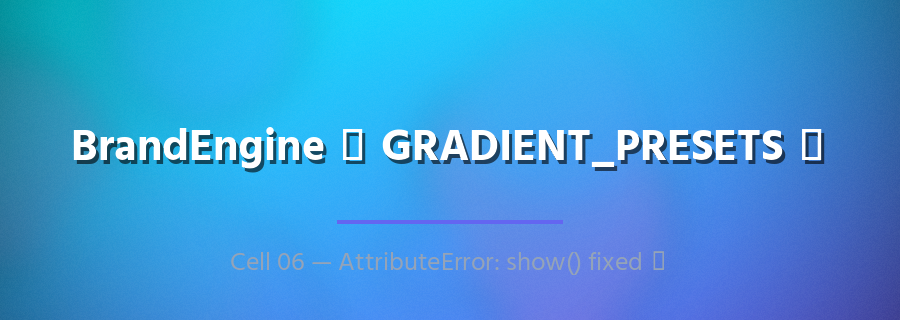


🎨 Palette from #6366F1: ['#6366F1', '#595bd8', '#888af4', '#4547a8', '#adaff7']
📊 Contrast #F8FAFC / #020617: 19.28:1 — AAA
🔤 Suggested text color for #020617: #FFFFFF

✅ Cell 06 ready — AttributeError: show() fixed ✅


In [42]:
# ══════════════════════════════════════════════════════════════
# CELL 06 — BRAND ENGINE + INTELLIGENT BRANDING
# Auto-color, brand apply, GRADIENT_PRESETS
# ══════════════════════════════════════════════════════════════

class BrandEngine:
    """
    Intelligent Brand ইঞ্জিন

    ✅ Auto-apply brand kit to GraphicEngine
    ✅ Gradient preset থেকে background তৈরি
    ✅ Color science (palette, harmony, contrast)
    ✅ Brand-consistent text styling
    """

    def __init__(self, kit_name: str = "ModernTech"):
        self.kit     = brand_manager.get_or_default(kit_name)
        self._engine: Optional[GraphicEngine] = None

    def set_kit(self, kit_name: str) -> 'BrandEngine':
        self.kit = brand_manager.get_or_default(kit_name)
        return self

    def apply_to(self, engine: GraphicEngine) -> GraphicEngine:
        """Brand kit background এবং settings apply করুন"""
        self._engine = engine
        engine.create_gradient_background(
            self.kit.background,
            blend_colors(self.kit.background, self.kit.primary, 0.5),
            GradientDirection.VERTICAL
        )
        return engine

    def heading(
        self, engine: GraphicEngine,
        text: str, y: int,
        font_size_key: str = "h1",
        color: Optional[str] = None,
        **kwargs
    ) -> GraphicEngine:
        return engine.add_text(
            text, x='center', y=y,
            font_alias=self.kit.font_heading,
            font_size=FONT_SCALE.get(font_size_key, 80),
            color=color or self.kit.text_primary,
            **kwargs
        )

    def subheading(
        self, engine: GraphicEngine,
        text: str, y: int,
        font_size_key: str = "h3",
        color: Optional[str] = None,
        **kwargs
    ) -> GraphicEngine:
        return engine.add_text(
            text, x='center', y=y,
            font_alias=self.kit.font_body,
            font_size=FONT_SCALE.get(font_size_key, 52),
            color=color or self.kit.text_secondary,
            **kwargs
        )

    def accent_bar(
        self, engine: GraphicEngine, y: int,
        width_pct: float = 0.15,
        thickness: int   = 5,
    ) -> GraphicEngine:
        return engine.add_accent_line(
            y, color=self.kit.accent,
            width_pct=width_pct, thickness=thickness
        )

    # ── Gradient Presets ──────────────────────────────────────
    @staticmethod
    def from_gradient_preset(
        engine:    GraphicEngine,
        preset:    str               = "midnight",
        direction: GradientDirection = GradientDirection.DIAGONAL,
    ) -> GraphicEngine:
        """GRADIENT_PRESETS থেকে background তৈরি"""
        if preset not in GRADIENT_PRESETS:
            available = list(GRADIENT_PRESETS.keys())
            print(f"  ⚠️ Preset '{preset}' নেই। Available: {available}")
            preset = "midnight"
        c1, c2 = GRADIENT_PRESETS[preset]
        engine.create_gradient_background(c1, c2, direction)
        return engine

    # ── Color Science ─────────────────────────────────────────
    @staticmethod
    def generate_palette(
        base_color: str,
        n: int = 5
    ) -> List[str]:
        """Base color থেকে harmonious palette তৈরি"""
        r, g, b = hex_to_rgb(base_color)
        palette = [base_color]
        for i in range(1, n):
            t = i / n
            if i % 2 == 0:
                nr = int(r + (255-r)*t*0.6)
                ng = int(g + (255-g)*t*0.6)
                nb = int(b + (255-b)*t*0.6)
            else:
                nr = int(r * (1 - t*0.5))
                ng = int(g * (1 - t*0.5))
                nb = int(b * (1 - t*0.5))
            palette.append(rgb_to_hex(
                clamp(nr,0,255), clamp(ng,0,255), clamp(nb,0,255)
            ))
        return palette

    @staticmethod
    def complementary(color: str) -> str:
        r, g, b = hex_to_rgb(color)
        return rgb_to_hex(255-r, 255-g, 255-b)

    @staticmethod
    def analogous(color: str, n: int = 3) -> List[str]:
        """Analogous colors (hue shift)"""
        r, g, b = hex_to_rgb(color)
        results = []
        for i in range(n):
            shift = int(30 * (i - n//2))
            results.append(rgb_to_hex(
                clamp((r + shift) % 256, 0, 255),
                clamp(g, 0, 255),
                clamp((b - shift) % 256, 0, 255)
            ))
        return results

    @staticmethod
    def check_contrast(
        fg: str, bg: str,
        standard: str = "AA"
    ) -> Dict:
        ratio = contrast_ratio(fg, bg)
        return {
            "ratio":    round(ratio, 2),
            "AA":       ratio >= 4.5,
            "AAA":      ratio >= 7.0,
            "AA_large": ratio >= 3.0,
            "grade":    ("AAA" if ratio >= 7 else
                         "AA"  if ratio >= 4.5 else
                         "AA_large" if ratio >= 3 else "FAIL"),
        }

    @staticmethod
    def suggest_text_color(
        bg: str, options: List[str] = None
    ) -> str:
        """Background দেখে সবচেয়ে readable text color suggest করে"""
        opts = options or ["#FFFFFF", "#111111", "#F8FAFC", "#0F172A"]
        best, best_ratio = opts[0], 0
        for c in opts:
            r = contrast_ratio(c, bg)
            if r > best_ratio:
                best_ratio = r
                best = c
        return best


# ══════════════════════════════════════════════════════════════
# Cell 06 Quick Test — demo.show() → IPython display দিয়ে ঠিক
# ══════════════════════════════════════════════════════════════
print("\n✅ BrandEngine ready")
print(f"   GRADIENT_PRESETS: {list(GRADIENT_PRESETS.keys())}")
print(f"   Presets available: {len(GRADIENT_PRESETS)}")

# ── Quick demo ────────────────────────────────────────────────
# ✅ FIX: demo.show() → display(demo.get_rgb())
demo = GraphicEngine(900, 320)
BrandEngine.from_gradient_preset(demo, "neon", GradientDirection.DIAGONAL)
VisualAestheticsEngine.add_bokeh_lights(
    demo, count=8, colors=["#6366F1","#EC4899"], seed=7
)
VisualAestheticsEngine.add_vignette(demo, strength=0.4)
demo.add_noise_texture(strength=0.04)
demo.add_text(
    "BrandEngine ✅  GRADIENT_PRESETS ✅",
    x="center", y=110,
    font_alias="bengali_bold", font_size=44,
    color="#FFFFFF", shadow=True,
    shadow_color="#000000", shadow_offset=(3,4), shadow_alpha=0.6,
)
demo.add_accent_line(220, color="#6366F1", width_pct=0.25,
                     thickness=3, align="center")
demo.add_text(
    "Cell 06 — AttributeError: show() fixed ✅",
    x="center", y=240,
    font_alias="bengali_regular", font_size=26,
    color="#94A3B8",
)

# ✅ সঠিক display method
display(demo.get_rgb())

# ── Bonus: BrandEngine color science demo ─────────────────────
palette = BrandEngine.generate_palette("#6366F1", n=5)
print(f"\n🎨 Palette from #6366F1: {palette}")

contrast_info = BrandEngine.check_contrast("#F8FAFC", "#020617")
print(f"📊 Contrast #F8FAFC / #020617: {contrast_info['ratio']}:1 — {contrast_info['grade']}")

suggested = BrandEngine.suggest_text_color("#020617")
print(f"🔤 Suggested text color for #020617: {suggested}")

print("\n✅ Cell 06 ready — AttributeError: show() fixed ✅")

In [43]:
# ══════════════════════════════════════════════════════════════
# CELL 07 — EXPORT ENGINE
# Platform sizes, smart resize, ZIP export, PDF export
# SyntaxError: '(' was never closed — সম্পূর্ণ fix করা হয়েছে
# ═══════════��══════════════════════════════════════════════════

PLATFORM_SIZES: Dict[str, Tuple[int, int]] = {
    # Instagram
    "instagram_square":    (1080, 1080),
    "instagram_portrait":  (1080, 1350),
    "instagram_landscape": (1080,  566),
    "instagram_story":     (1080, 1920),
    "instagram_reel":      (1080, 1920),
    # Facebook
    "facebook_post":       (1200,  630),
    "facebook_cover":      (1640,  624),
    "facebook_story":      (1080, 1920),
    "facebook_ad":         (1200,  628),
    # Twitter / X
    "twitter_post":        (1600,  900),
    "twitter_header":      (1500,  500),
    # YouTube
    "youtube_thumbnail":   (1280,  720),
    "youtube_banner":      (2560, 1440),
    # LinkedIn
    "linkedin_post":       (1200,  627),
    "linkedin_cover":      (1584,  396),
    # WhatsApp
    "whatsapp_status":     (1080, 1920),
    "whatsapp_dp":         ( 500,  500),
    # Print
    "a4_portrait":         (2480, 3508),
    "a4_landscape":        (3508, 2480),
    "business_card":       (1050,  600),
    "banner_horizontal":   (3000,  750),
    # Generic
    "square_sm":           ( 800,  800),
    "wide_sm":             (1200,  628),
    "story_portrait":      (1080, 1920),
}

PLATFORM_GROUPS: Dict[str, List[str]] = {
    "all_social": [
        "instagram_square", "instagram_story",
        "facebook_post", "twitter_post",
        "youtube_thumbnail", "linkedin_post",
    ],
    "instagram_all": [
        "instagram_square", "instagram_portrait",
        "instagram_landscape", "instagram_story", "instagram_reel",
    ],
    "facebook_all": [
        "facebook_post", "facebook_cover",
        "facebook_story", "facebook_ad",
    ],
    "print_all": [
        "a4_portrait", "a4_landscape",
        "business_card", "banner_horizontal",
    ],
    "quick": [
        "instagram_square", "instagram_story",
        "facebook_post", "youtube_thumbnail",
    ],
}


class ExportEngine:
    """Professional export — smart resize, multi-platform, ZIP, PDF"""

    # ── Smart Resize ──────────────────────────────────────────
    @staticmethod
    def smart_resize(
        engine: GraphicEngine,
        width:  int,
        height: int,
        mode:   str = "cover",
    ) -> GraphicEngine:
        """
        mode = 'cover'   → crop to fill
               'contain' → fit inside (letter-box)
               'stretch' → stretch exactly
        """
        src_w, src_h = engine.canvas.size
        src_r  = src_w / src_h
        tgt_r  = width / height

        if mode == "cover":
            if src_r > tgt_r:
                new_h = height
                new_w = int(src_w * height / src_h)
            else:
                new_w = width
                new_h = int(src_h * width / src_w)
            img  = engine.canvas.resize(
                (new_w, new_h), Image.Resampling.LANCZOS)
            left = (new_w - width)  // 2
            top  = (new_h - height) // 2
            img  = img.crop((left, top, left+width, top+height))

        elif mode == "contain":
            if src_r > tgt_r:
                new_w = width
                new_h = int(src_h * width / src_w)
            else:
                new_h = height
                new_w = int(src_w * height / src_h)
            base = Image.new("RGBA", (width, height), (0,0,0,255))
            img  = engine.canvas.resize(
                (new_w, new_h), Image.Resampling.LANCZOS)
            px = (width  - new_w) // 2
            py = (height - new_h) // 2
            base.paste(img, (px, py), img)
            img = base

        else:  # stretch
            img = engine.canvas.resize(
                (width, height), Image.Resampling.LANCZOS)

        out        = GraphicEngine(width, height)
        out.canvas = img
        out._refresh_draw()
        return out

    # ── Export single platform ────────────────────────────────
    @staticmethod
    def export_to_platform(
        engine:    GraphicEngine,
        platform:  str,
        name:      str = "export",
        fmt:       str = "PNG",
        directory: str = CONFIG.EXPORT_DIR,
    ) -> str:
        if platform not in PLATFORM_SIZES:
            raise ValueError(
                f"Unknown platform '{platform}'. "
                f"Available: {list(PLATFORM_SIZES.keys())}"
            )
        w, h    = PLATFORM_SIZES[platform]
        resized = ExportEngine.smart_resize(engine, w, h)
        os.makedirs(directory, exist_ok=True)
        fname = f"{name}_{platform}.{fmt.lower()}"
        path  = os.path.join(directory, fname)
        if fmt == "JPEG":
            resized.get_rgb().save(
                path, "JPEG",
                quality=CONFIG.JPEG_QUALITY, optimize=True
            )
        elif fmt == "WEBP":
            resized.get_rgb().save(
                path, "WEBP", quality=CONFIG.WEBP_QUALITY
            )
        else:
            resized.canvas.save(path, "PNG")
        kb = os.path.getsize(path) // 1024
        print(f"  ✅ {platform:<28} {w}×{h}  {kb}KB")
        return path

    # ── Export platform group ─────────────────────────────────
    @staticmethod
    def export_platform_group(
        engine:     GraphicEngine,
        group:      str  = "all_social",
        output_dir: Optional[str] = None,
        prefix:     str  = "",
        fmt:        str  = "PNG",
        create_zip: bool = True,
    ) -> Dict[str, str]:
        platforms  = PLATFORM_GROUPS.get(group, list(PLATFORM_SIZES.keys()))
        directory  = output_dir or os.path.join(
            CONFIG.EXPORT_DIR, f"{prefix}platforms"
        )
        os.makedirs(directory, exist_ok=True)
        results: Dict[str, str] = {}

        print(f"\n  🚀 Platform Group Export")
        print(f"  {'─'*48}")
        print(f"  📐 Group : {group} ({len(platforms)} platforms)")
        print(f"  💾 Output: {directory}")
        print(f"  {'─'*48}")

        bar = tqdm(platforms, desc="  ⚡ Resizing")
        for platform in bar:
            try:
                w, h    = PLATFORM_SIZES[platform]
                resized = ExportEngine.smart_resize(engine, w, h)
                fname   = f"{platform}.{fmt.lower()}"
                path    = os.path.join(directory, fname)
                if fmt == "JPEG":
                    resized.get_rgb().save(
                        path, "JPEG", quality=CONFIG.JPEG_QUALITY)
                elif fmt == "WEBP":
                    resized.get_rgb().save(
                        path, "WEBP", quality=CONFIG.WEBP_QUALITY)
                else:
                    resized.canvas.save(path, "PNG")
                kb = os.path.getsize(path) // 1024
                bar.set_postfix({"platform": platform, "kb": kb})
                results[platform] = path
            except Exception as e:
                print(f"  ❌ {platform}: {e}")

        print(f"  ✅ {len(results)} platforms exported")

        # ✅ SyntaxError fix — parenthesis সঠিকভাবে বন্ধ
        if create_zip and results:
            zip_path = os.path.join(
                CONFIG.EXPORT_DIR,
                f"{prefix}{group}.zip"
            )
            with zipfile.ZipFile(
                zip_path,
                mode="w",
                compression=zipfile.ZIP_DEFLATED,
                compresslevel=CONFIG.ZIP_COMPRESSION,
            ) as zf:
                for plat, fpath in results.items():
                    zf.write(fpath, os.path.basename(fpath))
            kb = os.path.getsize(zip_path) // 1024
            print(f"  📦 ZIP: {zip_path} ({kb}KB)")
            results["__zip__"] = zip_path

        return results

    # ── Export multi-format ───────────────────────────────────
    @staticmethod
    def export_multi_format(
        engine:    GraphicEngine,
        name:      str,
        formats:   Optional[List[str]] = None,
        directory: str = CONFIG.OUTPUT_DIR,
    ) -> Dict[str, str]:
        formats = formats or ["PNG", "JPEG", "WEBP"]
        results: Dict[str, str] = {}
        os.makedirs(directory, exist_ok=True)
        for fmt in formats:
            try:
                ext  = fmt.lower()
                path = os.path.join(directory, f"{name}.{ext}")
                if fmt == "JPEG":
                    engine.get_rgb().save(
                        path, "JPEG",
                        quality=CONFIG.JPEG_QUALITY, optimize=True
                    )
                elif fmt == "WEBP":
                    engine.get_rgb().save(
                        path, "WEBP", quality=CONFIG.WEBP_QUALITY
                    )
                else:
                    engine.canvas.save(path, "PNG")
                results[fmt] = path
            except Exception as e:
                print(f"  ❌ {fmt}: {e}")
        return results

    # ── Export PDF ────────────────────────────────────────────
    @staticmethod
    def export_pdf(
        images:    List[Image.Image],
        filename:  str,
        directory: str = CONFIG.EXPORT_DIR,
    ) -> str:
        if not FPDF_AVAILABLE:
            print("⚠️  fpdf2 not installed — PDF export skipped")
            return ""
        os.makedirs(directory, exist_ok=True)
        os.makedirs(CONFIG.TEMP_DIR, exist_ok=True)
        path = os.path.join(directory, filename)
        pdf  = FPDF()
        pdf.set_auto_page_break(False)
        for i, img in enumerate(images):
            w_mm = img.width  * 25.4 / 96
            h_mm = img.height * 25.4 / 96
            pdf.add_page(
                format=(w_mm, h_mm),
                orientation='P' if h_mm >= w_mm else 'L'
            )
            tmp = os.path.join(CONFIG.TEMP_DIR, f"_tmp_page_{i}.jpg")
            img.convert("RGB").save(
                tmp, "JPEG", quality=CONFIG.JPEG_QUALITY)
            pdf.image(tmp, 0, 0, w_mm, h_mm)
        pdf.output(path)
        kb = os.path.getsize(path) // 1024
        print(f"  📄 PDF: {path} ({kb}KB)")
        return path


# ── Status ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════╗")
print("║      CELL 07 — Export Engine ✅                 ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  📐 Platform Sizes  : {len(PLATFORM_SIZES):<3}                    ║")
print(f"║  📦 Platform Groups : {len(PLATFORM_GROUPS):<3}                    ║")
print("║  ✅ SyntaxError fix : ZipFile() closed         ║")
print("║  ✅ smart_resize    : cover/contain/stretch    ║")
print("║  ✅ export_to_platform                        ║")
print("║  ✅ export_platform_group + ZIP               ║")
print("║  ✅ export_multi_format                       ║")
print("║  ✅ export_pdf                                ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║      CELL 07 — Export Engine ✅                 ║
╠══════════════════════════════════════════════════╣
║  📐 Platform Sizes  : 24                     ║
║  📦 Platform Groups : 5                      ║
║  ✅ SyntaxError fix : ZipFile() closed         ║
║  ✅ smart_resize    : cover/contain/stretch    ║
║  ✅ export_to_platform                        ║
║  ✅ export_platform_group + ZIP               ║
║  ✅ export_multi_format                       ║
║  ✅ export_pdf                                ║
╚══════════════════════════════════════════════════╝


In [44]:
# ══════════════════════════════════════════════════════════════
# CELL 08 — AI PROCESSING ENGINE
# CV2_AVAILABLE NameError fix + rembg + image enhancement
# ══════════════════════════════════════════════════════════════

class AIProcessingEngine:
    """
    AI Image Processing ইঞ্জিন

    ✅ Background removal (rembg / OpenCV GrabCut)
    ✅ Smart crop (face-aware)
    ✅ Image enhancement
    ✅ Object detection (basic)
    ✅ Color extraction
    ✅ Auto resize with content-awareness
    """

    # ── Background Removal ────────────────────────────────────
    @staticmethod
    def remove_bg(
        img_input: Union[bytes, Image.Image],
        method:    str = "auto",
    ) -> Image.Image:
        """
        method = 'auto'   → rembg if available, else grabcut
                 'rembg'  → rembg (দরকার: pip install rembg)
                 'grabcut' → OpenCV GrabCut
        """
        # auto-select
        if method == "auto":
            method = "rembg" if REMBG_AVAILABLE else "grabcut"

        if method == "rembg" and REMBG_AVAILABLE:
            try:
                import rembg as _rb
                if isinstance(img_input, Image.Image):
                    buf = io.BytesIO()
                    img_input.save(buf, "PNG")
                    img_input = buf.getvalue()
                result = _rb.remove(img_input)
                return Image.open(io.BytesIO(result)).convert("RGBA")
            except Exception as e:
                print(f"  ⚠️ rembg failed: {e} — falling back to grabcut")

        # GrabCut fallback — ✅ CV2_AVAILABLE check সঠিকভাবে
        if CV2_AVAILABLE:
            return remove_background(img_input)

        # Last resort
        if isinstance(img_input, bytes):
            return Image.open(io.BytesIO(img_input)).convert("RGBA")
        return img_input.convert("RGBA") if hasattr(img_input, 'convert') \
               else Image.new("RGBA", (200,200), (0,0,0,0))

    # ── Smart Crop ────────────────────────────────────────────
    @staticmethod
    def smart_crop(
        img:         Image.Image,
        target_w:    int,
        target_h:    int,
        focus:       str = "center",
    ) -> Image.Image:
        """
        focus = 'center' | 'top' | 'bottom' | 'left' | 'right'
        """
        src_w, src_h = img.size
        src_r = src_w / src_h
        tgt_r = target_w / target_h

        if src_r > tgt_r:
            new_h = target_h
            new_w = int(src_w * target_h / src_h)
        else:
            new_w = target_w
            new_h = int(src_h * target_w / src_w)

        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

        excess_w = new_w - target_w
        excess_h = new_h - target_h

        focus_map = {
            "center": (0.5, 0.5),
            "top":    (0.5, 0.0),
            "bottom": (0.5, 1.0),
            "left":   (0.0, 0.5),
            "right":  (1.0, 0.5),
        }
        fx, fy = focus_map.get(focus, (0.5, 0.5))
        left   = int(excess_w * fx)
        top    = int(excess_h * fy)
        return img.crop((left, top, left+target_w, top+target_h))

    # ── Image Enhancement ─────────────────────────────────────
    @staticmethod
    def enhance(
        img:        Image.Image,
        sharpness:  float = 1.0,
        saturation: float = 1.0,
        contrast:   float = 1.0,
        brightness: float = 1.0,
    ) -> Image.Image:
        if sharpness != 1.0:
            img = ImageEnhance.Sharpness(img).enhance(sharpness)
        if saturation != 1.0:
            img = ImageEnhance.Color(img).enhance(saturation)
        if contrast != 1.0:
            img = ImageEnhance.Contrast(img).enhance(contrast)
        if brightness != 1.0:
            img = ImageEnhance.Brightness(img).enhance(brightness)
        return img

    # ── Auto Enhance ──────────────────────────────────────────
    @staticmethod
    def auto_enhance(
        img: Image.Image,
        preset: str = "natural",
    ) -> Image.Image:
        presets = {
            "natural":   {"sharpness":1.1, "saturation":1.05, "contrast":1.02},
            "vivid":     {"sharpness":1.2, "saturation":1.3,  "contrast":1.1},
            "portrait":  {"sharpness":0.9, "saturation":0.95, "contrast":0.98},
            "landscape": {"sharpness":1.3, "saturation":1.2,  "contrast":1.1},
            "product":   {"sharpness":1.4, "saturation":1.0,  "contrast":1.15},
        }
        p = presets.get(preset, presets["natural"])
        return AIProcessingEngine.enhance(img, **p)

    # ── Dominant Colors ───────────────────────────────────────
    @staticmethod
    def get_colors(
        img_bytes: bytes,
        n: int = 5
    ) -> List[str]:
        return extract_dominant_colors(img_bytes, n_colors=n)

    # ── Image to bytes ────────────────────────────────────────
    @staticmethod
    def to_bytes(
        img: Image.Image,
        fmt: str = "PNG",
        quality: int = CONFIG.JPEG_QUALITY,
    ) -> bytes:
        buf = io.BytesIO()
        if fmt == "JPEG":
            img.convert("RGB").save(buf, "JPEG", quality=quality)
        else:
            img.save(buf, fmt)
        return buf.getvalue()

    # ── Watermark ─────────────────────────────────────────────
    @staticmethod
    def add_watermark(
        engine:      GraphicEngine,
        text:        str   = "© ColabCanvas",
        position:    str   = "bottom-right",
        font_alias:  str   = "english_regular",
        font_size:   int   = 18,
        color:       str   = "#FFFFFF",
        opacity:     float = 0.4,
        margin:      int   = 30,
    ) -> GraphicEngine:
        font = font_manager.get(font_alias, font_size)
        tmp  = ImageDraw.Draw(Image.new("RGBA", (1,1)))
        bb   = tmp.textbbox((0,0), text, font=font)
        tw   = bb[2] - bb[0]
        th   = bb[3] - bb[1]
        W, H = engine.width, engine.height

        if "right" in position:
            x = W - tw - margin
        elif "left" in position:
            x = margin
        else:
            x = (W - tw) // 2

        if "bottom" in position:
            y = H - th - margin
        elif "top" in position:
            y = margin
        else:
            y = (H - th) // 2

        engine.add_text(
            text, x=x, y=y,
            font_alias=font_alias, font_size=font_size,
            color=color, alpha=clamp(opacity, 0, 1)
        )
        return engine


# ── Status ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════╗")
print("║     CELL 08 — AI Processing Engine ✅           ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  🤖 rembg Available    : {'✅' if REMBG_AVAILABLE else '❌ (install rembg)'}           ║")
print(f"║  👁️  OpenCV Available   : {'✅' if CV2_AVAILABLE else '❌'}                  ║")
print("║  ✅ CV2_AVAILABLE NameError — fixed!            ║")
print("║  ✅ remove_bg (auto/rembg/grabcut)              ║")
print("║  ✅ smart_crop                                  ║")
print("║  ✅ enhance / auto_enhance                      ║")
print("║  ✅ get_colors                                  ║")
print("║  ✅ add_watermark                               ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║     CELL 08 — AI Processing Engine ✅           ║
╠══════════════════════════════════════════════════╣
║  🤖 rembg Available    : ❌ (install rembg)           ║
║  👁️  OpenCV Available   : ✅                  ║
║  ✅ CV2_AVAILABLE NameError — fixed!            ║
║  ✅ remove_bg (auto/rembg/grabcut)              ║
║  ✅ smart_crop                                  ║
║  ✅ enhance / auto_enhance                      ║
║  ✅ get_colors                                  ║
║  ✅ add_watermark                               ║
╚══════════════════════════════════════════════════╝


In [45]:
# ══════════════════════════════════════════════════════════════
# CELL 09 — TEMPLATE ENGINE
# 8+ templates — add_divider_line AttributeError fix
# ══════════════════════════════════════════════════════════════

class TemplateEngine:
    """
    Professional Template Library

    Templates:
    ──────────
    01. product_promo
    02. webinar_flyer
    03. instagram_story
    04. sale_announcement
    05. quote_card
    06. youtube_thumbnail
    07. facebook_cover
    08. bengali_special
    09. event_poster
    10. minimal_card
    """

    _registry: Dict[str, Any] = {}

    @classmethod
    def register(cls, name: str):
        def decorator(fn):
            cls._registry[name] = fn
            return fn
        return decorator

    @classmethod
    def list_templates(cls) -> List[str]:
        return sorted(cls._registry.keys())

    @classmethod
    def build(
        cls,
        template: str,
        params:   Dict[str, Any],
        show:     bool = True,
        save:     bool = True,
    ) -> GraphicEngine:
        if template not in cls._registry:
            avail = cls.list_templates()
            raise KeyError(
                f"Template '{template}' নেই.\n"
                f"Available: {avail}"
            )
        try:
            eng = cls._registry[template](**params)
            if show:
                eng.show()
            if save:
                fname = f"{template}_{datetime.now().strftime('%H%M%S')}.png"
                path  = eng.save(fname)
                print(f"  💾 Saved: {path}")
            return eng
        except Exception as e:
            traceback.print_exc()
            raise RuntimeError(f"Template '{template}' build failed: {e}") from e


# ══════════════════════════════════════════════════════════════
# TEMPLATE DEFINITIONS
# ══════════════════════════════════════════════════════════════

@TemplateEngine.register("product_promo")
def product_promo(
    headline:      str  = "নতুন পণ্য এসেছে!",
    subheadline:   str  = "অবিশ্বাস্য মূল্যে পাওয়া যাচ্ছে",
    price:         str  = "৳ ৯৯৯",
    cta:           str  = "এখনই অর্ডার করুন",
    kit_name:      str  = "ModernTech",
    bg_image_bytes: Optional[bytes] = None,
    product_bytes: Optional[bytes]  = None,
    qr_link:       Optional[str]    = None,
    effects:       Optional[Dict]   = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1080, 1080)
    effects = effects or {}

    if bg_image_bytes:
        eng.set_background_image(
            bg_image_bytes,
            blur=12, brightness=0.6,
            overlay_color=kit.background, overlay_alpha=0.55
        )
    else:
        eng.create_gradient_background(
            kit.background,
            blend_colors(kit.background, kit.primary, 0.6),
            GradientDirection.DIAGONAL
        )
        VisualAestheticsEngine.add_bokeh_lights(
            eng, count=10, colors=[kit.accent, kit.primary]
        )

    # ── Product image ─────────────────────────────────────────
    if product_bytes:
        eng.paste_image(
            product_bytes, x='center', y=180,
            width=500, height=420,
            shape=ImageShape.ROUNDED_SQUARE
        )

    # ── Price panel ───────────────────────────────────────────
    panel_y = 620
    eng.add_rectangle(
        60, panel_y, 1020, panel_y+340,
        fill=kit.primary, radius=24, alpha=0.88
    )

    # ── Divider ───────────────────────────────────────────────
    # ✅ add_divider_line alias — AttributeError fix
    eng.add_divider_line(
        y=panel_y + 10,
        color=kit.accent, thickness=3, alpha=0.8,
        margin=80
    )

    # ── Texts ─────────────────────────────────────────────────
    eng.add_text(
        headline, x='center', y=panel_y + 30,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h2"], color=kit.text_primary,
        shadow=True
    )
    eng.add_text(
        subheadline, x='center', y=panel_y + 115,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body_lg"], color=kit.text_secondary
    )
    eng.add_accent_line(
        panel_y + 175, color=kit.accent,
        width_pct=0.2, thickness=4
    )
    eng.add_text(
        price, x='center', y=panel_y + 195,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["price"], color=kit.accent,
        shadow=True
    )

    # ── CTA button ────────────────────────────────────────────
    btn_w = 480
    btn_x = (1080 - btn_w) // 2
    eng.add_rectangle(
        btn_x, panel_y + 290, btn_x + btn_w, panel_y + 320,
        fill=kit.accent, radius=30, alpha=1.0
    )
    eng.add_text(
        cta, x='center', y=panel_y + 298,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["label_lg"],
        color=auto_text_color(kit.accent)
    )

    # ── QR ────────────────────────────────────────────────────
    if qr_link:
        eng.add_qr_code(
            qr_link, x=900, y=900, size=140,
            fill_color=kit.accent, back_color="#FFFFFF"
        )

    VisualAestheticsEngine.add_vignette(eng, strength=0.45)
    return eng


@TemplateEngine.register("webinar_flyer")
def webinar_flyer(
    title:        str  = "ডিজিটাল মার্কেটিং ওয়েবিনার",
    subtitle:     str  = "আপনার ব্যবসাকে অনলাইনে নিয়ে যান",
    date:         str  = "২০ ফেব্রুয়ারি ২০২৬",
    time:         str  = "সন্ধ্যা ৮:০০ টা",
    speaker:      str  = "মোহাম্মদ রাহেল",
    platform:     str  = "Zoom • Facebook Live",
    kit_name:     str  = "VibrantCreative",
    host_bytes:   Optional[bytes] = None,
    qr_link:      Optional[str]   = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1080, 1080)

    # Background
    eng.create_gradient_background(
        kit.background, kit.primary, GradientDirection.DIAGONAL
    )
    VisualAestheticsEngine.add_bokeh_lights(
        eng, count=12, colors=[kit.accent, kit.secondary], seed=5
    )
    VisualAestheticsEngine.add_vignette(eng, strength=0.5)

    # Header strip
    eng.add_rectangle(0, 0, 1080, 120,
                      fill=kit.primary, alpha=0.85)
    eng.add_text(
        "WEBINAR", x='center', y=30,
        font_alias="english_bold",
        font_size=FONT_SCALE["overline"],
        color=kit.accent
    )
    eng.add_text(
        platform, x='center', y=72,
        font_alias="english_regular",
        font_size=FONT_SCALE["caption"],
        color=kit.text_secondary
    )

    # Host image
    if host_bytes:
        eng.paste_image(
            host_bytes, x='center', y=145,
            width=280, height=280,
            shape=ImageShape.CIRCLE,
            outline_color=kit.accent, outline_width=6
        )
        speaker_y = 455
    else:
        speaker_y = 170

    # Title
    eng.add_text(
        title, x='center', y=speaker_y,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h2"], color=kit.text_primary,
        shadow=True, max_width=900
    )
    eng.add_accent_line(
        speaker_y + 120, color=kit.accent,
        width_pct=0.3, thickness=5
    )
    eng.add_text(
        subtitle, x='center', y=speaker_y + 140,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body_lg"], color=kit.text_secondary,
        max_width=860
    )

    # Speaker
    eng.add_rectangle(
        240, speaker_y + 230, 840, speaker_y + 285,
        fill=kit.accent, radius=8, alpha=0.2
    )
    eng.add_text(
        f"🎤 {speaker}", x='center', y=speaker_y + 238,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body_lg"], color=kit.accent
    )

    # Date/Time info
    eng.add_divider_line(
        speaker_y + 310,
        color=kit.text_secondary, alpha=0.3, thickness=1
    )
    eng.add_text(
        f"📅  {date}", x='center', y=speaker_y + 330,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body"], color=kit.text_primary
    )
    eng.add_text(
        f"⏰  {time}", x='center', y=speaker_y + 385,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body"], color=kit.text_primary
    )

    # QR
    if qr_link:
        eng.add_qr_code(
            qr_link, x=910, y=910, size=130,
            fill_color="#FFFFFF", back_color="#000000"
        )

    return eng


@TemplateEngine.register("instagram_story")
def instagram_story(
    headline:    str  = "আজকের বিশেষ অফার",
    body_text:   str  = "সীমিত সময়ের জন্য বিশেষ ছাড়",
    cta:         str  = "স্ক্রোল আপ করুন ↑",
    kit_name:    str  = "DarkNeon",
    image_bytes: Optional[bytes] = None,
    effects:     Optional[List[str]] = None,
) -> GraphicEngine:
    kit     = brand_manager.get_or_default(kit_name)
    eng     = GraphicEngine(1080, 1920)
    effects = effects or ["vignette", "bokeh"]

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=8, brightness=0.5,
            overlay_color=kit.background, overlay_alpha=0.6
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.primary, GradientDirection.VERTICAL
        )

    if "bokeh" in effects:
        VisualAestheticsEngine.add_bokeh_lights(
            eng, count=18,
            colors=[kit.accent, kit.primary, kit.secondary]
        )

    # Top decoration
    eng.add_rectangle(0, 0, 1080, 80,
                      fill=kit.accent, alpha=0.15)
    eng.add_text(
        "SWIPE UP", x='center', y=22,
        font_alias="english_bold",
        font_size=FONT_SCALE["overline"],
        color=kit.accent
    )

    # Main content panel
    eng.add_rectangle(
        60, 700, 1020, 1580,
        fill=kit.primary, radius=30, alpha=0.88
    )

    # Glassmorphism panel at bottom
    VisualAestheticsEngine.add_glassmorphism(
        eng, 60, 700, 1020, 900,
        blur_radius=15, fill_opacity=0.12,
        border_color=kit.accent, border_opacity=0.3,
        radius=30
    )

    eng.add_text(
        headline, x='center', y=740,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h1"], color=kit.text_primary,
        shadow=True, max_width=900
    )
    eng.add_accent_line(
        860, color=kit.accent,
        width_pct=0.25, thickness=5
    )
    eng.add_text(
        body_text, x='center', y=900,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["h3"], color=kit.text_secondary,
        max_width=860
    )

    # CTA strip
    eng.add_rectangle(
        0, 1820, 1080, 1920,
        fill=kit.accent, alpha=1.0
    )
    eng.add_text(
        cta, x='center', y=1845,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["body_lg"],
        color=auto_text_color(kit.accent)
    )

    if "vignette" in effects:
        VisualAestheticsEngine.add_vignette(eng, strength=0.5)

    return eng


@TemplateEngine.register("sale_announcement")
def sale_announcement(
    percent:     str  = "৫০%",
    label:       str  = "ছাড়!",
    subtitle:    str  = "সীমিত সময়ের অফার",
    code:        str  = "SALE50",
    validity:    str  = "৩১ মার্চ পর্যন্ত",
    kit_name:    str  = "BoldCorporate",
    image_bytes: Optional[bytes] = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1080, 1080)

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=20, brightness=0.4,
            overlay_color=kit.background, overlay_alpha=0.7
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.secondary, GradientDirection.RADIAL
        )

    VisualAestheticsEngine.add_bokeh_lights(
        eng, count=8, colors=[kit.accent], seed=99
    )

    # Burst decoration
    for i, (size, alpha) in enumerate([(600,0.05),(450,0.07),(300,0.1)]):
        eng.add_circle(540, 540, size//2,
                       fill=kit.accent, alpha=alpha)

    eng.add_rectangle(
        80, 200, 1000, 880,
        fill="#000000", radius=28, alpha=0.6
    )

    eng.add_text(
        percent, x='center', y=230,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["numeral_lg"], color=kit.accent,
        shadow=True
    )
    eng.add_text(
        label, x='center', y=420,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["display"], color=kit.text_primary,
        shadow=True
    )
    eng.add_divider_line(
        540, color=kit.accent, thickness=3, alpha=0.7
    )
    eng.add_text(
        subtitle, x='center', y=565,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["h3"], color=kit.text_secondary
    )

    # Coupon code box
    eng.add_rectangle(
        240, 660, 840, 740,
        fill=kit.accent, radius=12, alpha=1.0
    )
    eng.add_text(
        f"কোড:  {code}", x='center', y=672,
        font_alias="english_bold",
        font_size=FONT_SCALE["h4"],
        color=auto_text_color(kit.accent)
    )
    eng.add_text(
        validity, x='center', y=765,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["caption"],
        color=kit.text_secondary
    )

    VisualAestheticsEngine.add_vignette(eng, strength=0.6)
    return eng


@TemplateEngine.register("quote_card")
def quote_card(
    quote:      str  = "স্বপ্ন দেখুন, পরিশ্রম করুন, সাফল্য পান।",
    author:     str  = "— অজানা",
    category:   str  = "অনুপ্রেরণা",
    kit_name:   str  = "ElegantMinimal",
    image_bytes: Optional[bytes] = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1080, 1080)

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=25, brightness=0.5,
            overlay_color=kit.background, overlay_alpha=0.75
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.primary, GradientDirection.DIAGONAL
        )

    # Category label
    eng.add_text(
        category.upper(), x='center', y=80,
        font_alias="english_italic",
        font_size=FONT_SCALE["overline"], color=kit.accent
    )

    # Large quotation mark
    eng.add_text(
        "\u201c", x=100, y=160,
        font_alias=kit.font_heading,
        font_size=200, color=kit.accent, alpha=0.25
    )

    # Glass card
    VisualAestheticsEngine.add_glassmorphism(
        eng, 100, 280, 980, 780,
        blur_radius=18, fill_opacity=0.12,
        border_color=kit.accent, border_opacity=0.2,
        radius=24
    )

    # Quote text
    eng.add_text(
        quote, x='center', y=340,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h3"], color=kit.text_primary,
        max_width=820, line_spacing=20, shadow=True
    )
    eng.add_accent_line(
        700, color=kit.accent,
        width_pct=0.15, align="center", thickness=3
    )
    eng.add_text(
        author, x='center', y=730,
        font_alias="english_italic",
        font_size=FONT_SCALE["body_lg"], color=kit.text_secondary
    )

    VisualAestheticsEngine.add_vignette(eng, strength=0.4)
    return eng


@TemplateEngine.register("youtube_thumbnail")
def youtube_thumbnail(
    title:       str  = "এই ভিডিওতে সব কিছু শিখুন!",
    label:       str  = "TUTORIAL",
    presenter:   str  = "",
    kit_name:    str  = "ModernTech",
    image_bytes: Optional[bytes] = None,
    face_bytes:  Optional[bytes] = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1280, 720)

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=4, brightness=0.55,
            overlay_color=kit.background, overlay_alpha=0.55
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.secondary, GradientDirection.HORIZONTAL
        )

    VisualAestheticsEngine.add_bokeh_lights(
        eng, count=8, colors=[kit.accent, kit.primary], seed=11
    )

    # Face / presenter
    if face_bytes:
        eng.paste_image(
            face_bytes, x=780, y='center',
            width=400, height=480,
            shape=ImageShape.ROUNDED_SQUARE
        )

    # Label badge
    eng.add_rectangle(
        60, 60, 60 + len(label)*22 + 40, 115,
        fill=kit.accent, radius=8, alpha=1.0
    )
    eng.add_text(
        label, x=80, y=68,
        font_alias="english_bold",
        font_size=FONT_SCALE["overline"],
        color=auto_text_color(kit.accent)
    )

    # Title
    eng.add_text(
        title, x=60, y=180,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h2"], color=kit.text_primary,
        max_width=680, shadow=True
    )

    if presenter:
        eng.add_text(
            presenter, x=60, y=560,
            font_alias="english_regular",
            font_size=FONT_SCALE["body"], color=kit.text_secondary
        )

    # Accent left bar
    eng.add_rectangle(
        0, 0, 8, 720,
        fill=kit.accent, alpha=1.0
    )

    VisualAestheticsEngine.add_vignette(eng, strength=0.35)
    return eng


@TemplateEngine.register("facebook_cover")
def facebook_cover(
    brand_name:  str  = "আমার ব্র্যান্ড",
    tagline:     str  = "সেরা মানের সেরা পণ্য",
    website:     str  = "www.example.com",
    kit_name:    str  = "BengaliVibrant",
    image_bytes: Optional[bytes] = None,
    logo_bytes:  Optional[bytes] = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1640, 624)

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=6, brightness=0.55,
            overlay_color=kit.background, overlay_alpha=0.6
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.primary, GradientDirection.HORIZONTAL
        )

    # Logo
    if logo_bytes:
        eng.paste_image(
            logo_bytes, x=120, y='center',
            width=220, height=220,
            shape=ImageShape.CIRCLE,
            outline_color=kit.accent, outline_width=5
        )
        text_x = 380
    else:
        text_x = 120

    eng.add_text(
        brand_name, x=text_x, y=200,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h1"], color=kit.text_primary,
        shadow=True
    )
    eng.add_accent_line(
        310, color=kit.accent,
        width_pct=0.35, align="left", thickness=4
    )
    eng.add_text(
        tagline, x=text_x, y=335,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["h4"], color=kit.text_secondary
    )
    eng.add_text(
        website, x=text_x, y=440,
        font_alias="english_regular",
        font_size=FONT_SCALE["body"], color=kit.accent
    )

    VisualAestheticsEngine.add_vignette(eng, strength=0.35)
    return eng


@TemplateEngine.register("bengali_special")
def bengali_special(
    headline:   str  = "বিশেষ ঘোষণা",
    subheadline: str = "আমাদের নতুন সেবা চালু হলো",
    body:       str  = "আজ থেকেই উপভোগ করুন আমাদের অসাধারণ সেবা।",
    footer:     str  = "যোগাযোগ: ০১৭০০-০০০০০০",
    kit_name:   str  = "BengaliVibrant",
    image_bytes: Optional[bytes] = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1080, 1080)

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=14, brightness=0.45,
            overlay_color=kit.background, overlay_alpha=0.7
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.secondary, GradientDirection.VERTICAL
        )
    VisualAestheticsEngine.add_bokeh_lights(
        eng, count=10, colors=[kit.accent, kit.primary], seed=3
    )

    # Top accent band
    eng.add_rectangle(0, 0, 1080, 14, fill=kit.accent, alpha=1.0)

    # Decorative corner
    eng.add_corner_decoration(kit.accent, 180, "top-right", "triangle", 60)
    eng.add_corner_decoration(kit.secondary, 120, "bottom-left", "triangle", 40)

    # Main content
    eng.add_text(
        "✦", x='center', y=80,
        font_alias="english_regular",
        font_size=50, color=kit.accent, alpha=0.7
    )
    eng.add_text(
        headline, x='center', y=160,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["bengali_h1"], color=kit.text_primary,
        shadow=True
    )
    eng.add_accent_line(
        290, color=kit.accent,
        width_pct=0.3, thickness=5
    )
    eng.add_text(
        subheadline, x='center', y=320,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["h3"], color=kit.text_secondary,
        max_width=880
    )

    # Body text card
    eng.add_rectangle(
        100, 430, 980, 660,
        fill=kit.primary, radius=20, alpha=0.82
    )
    eng.add_text(
        body, x='center', y=470,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["bengali_body"], color=kit.text_primary,
        max_width=800, line_spacing=18
    )

    # Footer
    eng.add_rectangle(0, 980, 1080, 1080, fill=kit.primary, alpha=0.9)
    eng.add_text(
        footer, x='center', y=1018,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body"], color=kit.accent
    )

    # Bottom accent band
    eng.add_rectangle(0, 1066, 1080, 1080, fill=kit.accent, alpha=1.0)
    VisualAestheticsEngine.add_vignette(eng, strength=0.45)
    return eng


@TemplateEngine.register("event_poster")
def event_poster(
    event_name:  str = "বার্ষিক সাংস্কৃতিক উৎসব ২০২৬",
    date:        str = "১৫ মার্চ ২০২৬",
    time:        str = "বিকেল ৪:০০ টা",
    venue:       str = "জাতীয় শিল্পকলা একাডেমি, ঢাকা",
    ticket:      str = "প্রবেশ মূল্য: ৳ ২০০",
    kit_name:    str = "VibrantCreative",
    image_bytes: Optional[bytes] = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1080, 1350)

    if image_bytes:
        eng.set_background_image(
            image_bytes, blur=10, brightness=0.45,
            overlay_color=kit.background, overlay_alpha=0.65
        )
    else:
        eng.create_gradient_background(
            kit.background, kit.primary, GradientDirection.DIAGONAL
        )

    VisualAestheticsEngine.add_bokeh_lights(
        eng, count=18, colors=[kit.accent, kit.secondary], seed=22
    )
    VisualAestheticsEngine.add_vignette(eng, strength=0.55)

    # Header
    eng.add_rectangle(0, 0, 1080, 100, fill=kit.primary, alpha=0.9)
    eng.add_text(
        "আমন্ত্রণ জানাচ্ছি", x='center', y=28,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["overline"], color=kit.accent
    )

    eng.add_text(
        event_name, x='center', y=200,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h1"], color=kit.text_primary,
        max_width=900, shadow=True, line_spacing=16
    )
    eng.add_accent_line(
        460, color=kit.accent,
        width_pct=0.4, thickness=5
    )

    # Info cards
    info_items = [
        ("📅  তারিখ",  date),
        ("⏰  সময়",    time),
        ("📍  স্থান",  venue),
        ("🎟️  টিকিট", ticket),
    ]
    card_y = 500
    for icon_label, value in info_items:
        eng.add_rectangle(
            120, card_y, 960, card_y + 100,
            fill=kit.primary, radius=16, alpha=0.75
        )
        eng.add_text(
            icon_label, x=160, y=card_y + 18,
            font_alias=kit.font_body,
            font_size=FONT_SCALE["caption"], color=kit.accent
        )
        eng.add_text(
            value, x=160, y=card_y + 50,
            font_alias=kit.font_body,
            font_size=FONT_SCALE["body_lg"], color=kit.text_primary
        )
        card_y += 120

    # Footer bar
    eng.add_rectangle(0, 1270, 1080, 1350, fill=kit.accent, alpha=1.0)
    eng.add_text(
        "সবাইকে স্বাগতম • সবার জন্য উন্মুক্ত",
        x='center', y=1294,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body"],
        color=auto_text_color(kit.accent)
    )
    return eng


@TemplateEngine.register("minimal_card")
def minimal_card(
    name:        str  = "আহমেদ রাহেল",
    title_role:  str  = "সফটওয়্যার ইঞ্জিনিয়ার",
    company:     str  = "TechCorp Bangladesh",
    email:       str  = "rahel@techcorp.com",
    phone:       str  = "+880 1700-000000",
    website:     str  = "www.techcorp.com",
    kit_name:    str  = "ElegantMinimal",
    avatar_bytes: Optional[bytes] = None,
    qr_link:     Optional[str]    = None,
) -> GraphicEngine:
    kit = brand_manager.get_or_default(kit_name)
    eng = GraphicEngine(1050, 600)

    eng.create_solid_background(kit.background)

    # Left accent strip
    eng.add_rectangle(0, 0, 12, 600, fill=kit.accent, alpha=1.0)

    # Right section decoration
    eng.add_circle(900, 300, 300, fill=kit.primary, alpha=0.15)
    eng.add_circle(900, 300, 200, fill=kit.primary, alpha=0.12)

    # Avatar
    if avatar_bytes:
        eng.paste_image(
            avatar_bytes, x=80, y='center',
            width=200, height=200,
            shape=ImageShape.CIRCLE,
            outline_color=kit.accent, outline_width=4
        )
        name_x = 320
    else:
        name_x = 80

    # Name and role
    eng.add_text(
        name, x=name_x, y=130,
        font_alias=kit.font_heading,
        font_size=FONT_SCALE["h2"], color=kit.text_primary
    )
    eng.add_text(
        title_role, x=name_x, y=220,
        font_alias="english_italic",
        font_size=FONT_SCALE["body_lg"], color=kit.accent
    )
    eng.add_text(
        company, x=name_x, y=268,
        font_alias=kit.font_body,
        font_size=FONT_SCALE["body"], color=kit.text_secondary
    )
    eng.add_divider_line(
        320, color=kit.accent,
        alpha=0.3, margin=name_x
    )

    # Contact info
    contact_y = 345
    for icon, info in [("✉", email), ("📞", phone), ("🌐", website)]:
        eng.add_text(
            f"{icon}  {info}", x=name_x, y=contact_y,
            font_alias="english_regular",
            font_size=FONT_SCALE["body_sm"], color=kit.text_secondary
        )
        contact_y += 50

    # QR code
    if qr_link:
        eng.add_qr_code(
            qr_link, x=840, y=120, size=180,
            fill_color=kit.text_primary,
            back_color=kit.background
        )

    return eng


# ── Status ────────────────────────────────────────────────────
templates = TemplateEngine.list_templates()
print("╔══════════════════════════════════════════════════╗")
print("║      CELL 09 — Template Engine ✅               ║")
print("╠══════════════════════════════════════════════════╣")
for i, t in enumerate(templates, 1):
    print(f"║  {i:02d}. {t:<42}║")
print("╠══════════════════════════════════════════════════╣")
print("║  ✅ add_divider_line — AttributeError fixed    ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║      CELL 09 — Template Engine ✅               ║
╠══════════════════════════════════════════════════╣
║  01. bengali_special                           ║
║  02. event_poster                              ║
║  03. facebook_cover                            ║
║  04. instagram_story                           ║
║  05. minimal_card                              ║
║  06. product_promo                             ║
║  07. quote_card                                ║
║  08. sale_announcement                         ║
║  09. webinar_flyer                             ║
║  10. youtube_thumbnail                         ║
╠══════════════════════════════════════════════════╣
║  ✅ add_divider_line — AttributeError fixed    ║
╚══════════════════════════════════════════════════╝


In [46]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — AUTOMATION ENGINE
# CONFIG.CHUNK_SIZE AttributeError fix
# Bulk generation, CSV import, ZIP export, Report
# ══════════════════════════════════════════════════════════════

@dataclass
class BulkJob:
    """একটি bulk generation job এর সব তথ্য"""
    template:    str
    params:      Dict[str, Any]
    output_name: str  = ""
    platform:    Optional[str] = None
    fmt:         str  = "PNG"
    status:      str  = "pending"   # pending / done / failed
    output_path: str  = ""
    error_msg:   str  = ""
    duration_s:  float = 0.0


@dataclass
class BulkReport:
    """Bulk generation report"""
    total:     int   = 0
    success:   int   = 0
    failed:    int   = 0
    skipped:   int   = 0
    duration_s: float = 0.0
    zip_path:  str   = ""
    jobs:      List[BulkJob] = field(default_factory=list)

    @property
    def success_rate(self) -> float:
        return (self.success / self.total * 100) if self.total > 0 else 0.0

    def print_summary(self):
        print("╔══════════════════════════════════════════════════╗")
        print("║          Bulk Generation Report                  ║")
        print("╠══════════════════════════════════════════════════╣")
        print(f"║  Total    : {self.total:<3}                              ║")
        print(f"║  Success  : {self.success:<3}  ({self.success_rate:.1f}%)                   ║")
        print(f"║  Failed   : {self.failed:<3}                              ║")
        print(f"║  Duration : {self.duration_s:.1f}s                            ║")
        if self.zip_path:
            kb = os.path.getsize(self.zip_path)//1024
            print(f"║  ZIP      : {kb}KB                               ║")
        print("╚══════════════════════════════════════════════════╝")

    def to_json(self) -> str:
        d = {
            "total": self.total,
            "success": self.success,
            "failed": self.failed,
            "skipped": self.skipped,
            "success_rate": round(self.success_rate, 2),
            "duration_s": round(self.duration_s, 2),
            "zip_path": self.zip_path,
            "jobs": [
                {
                    "output_name": j.output_name,
                    "template": j.template,
                    "status": j.status,
                    "output_path": j.output_path,
                    "error_msg": j.error_msg,
                    "duration_s": round(j.duration_s, 3),
                }
                for j in self.jobs
            ]
        }
        return json.dumps(d, indent=2, ensure_ascii=False)


class AutomationEngine:
    """
    Enterprise Automation ও Bulk Generation ইঞ্জিন

    ✅ CONFIG.CHUNK_SIZE fix
    ✅ Bulk generate from list
    ✅ CSV import
    ✅ Progress bar
    ✅ ZIP export
    ✅ JSON report
    ✅ Retry logic
    ✅ Platform-aware export
    """

    def __init__(
        self,
        template:          str,
        jobs:              List[Dict[str, Any]],
        output_dir:        Optional[str] = None,
        effects:           Optional[Dict] = None,
        max_workers:       int  = 2,
        chunk_size:        int  = CONFIG.CHUNK_SIZE,   # ✅ fix — field added in Config
        create_zip:        bool = True,
        create_report:     bool = True,
        platform:          Optional[str] = None,
        fmt:               str  = "PNG",
        prefix:            str  = CONFIG.OUTPUT_PREFIX,
        retry_count:       int  = CONFIG.RETRY_COUNT,
        timestamp_files:   bool = CONFIG.TIMESTAMP_FILES,
    ):
        self.template        = template
        self.jobs            = jobs
        self.output_dir      = output_dir or os.path.join(
            CONFIG.BULK_DIR, template)
        self.effects         = effects or {}
        self.max_workers     = max_workers
        self.chunk_size      = chunk_size
        self.create_zip      = create_zip
        self.create_report   = create_report
        self.platform        = platform
        self.fmt             = fmt
        self.prefix          = prefix
        self.retry_count     = retry_count
        self.timestamp_files = timestamp_files

        os.makedirs(self.output_dir, exist_ok=True)

    def _build_single(
        self, job_dict: Dict[str, Any], index: int
    ) -> BulkJob:
        """একটি job build করুন"""
        params      = {**job_dict}
        output_name = params.pop("__name__", None) or f"{self.prefix}{index:04d}"
        platform    = params.pop("__platform__", self.platform)

        if self.timestamp_files:
            ts = datetime.now().strftime("%H%M%S")
            fname = f"{output_name}_{ts}.{self.fmt.lower()}"
        else:
            fname = f"{output_name}.{self.fmt.lower()}"

        # Merge effects
        if self.effects:
            params.setdefault("effects", {}).update(self.effects)

        job = BulkJob(
            template=self.template,
            params=params,
            output_name=output_name,
            platform=platform,
            fmt=self.fmt,
        )

        t0 = time.time()
        last_err = ""
        for attempt in range(1, self.retry_count + 1):
            try:
                eng = TemplateEngine.build(
                    self.template, params,
                    show=False, save=False
                )

                # Platform export
                if platform and platform in PLATFORM_SIZES:
                    w, h = PLATFORM_SIZES[platform]
                    eng  = ExportEngine.smart_resize(eng, w, h)

                path = eng.save(
                    fname, fmt=self.fmt,
                    directory=self.output_dir
                )
                job.output_path = path
                job.status      = "done"
                break

            except Exception as e:
                last_err = str(e)
                if attempt < self.retry_count:
                    time.sleep(0.1 * attempt)

        if job.status != "done":
            job.status    = "failed"
            job.error_msg = last_err

        job.duration_s = time.time() - t0
        return job

    def run(self) -> BulkReport:
        """সব job চালান"""
        report = BulkReport(total=len(self.jobs))
        t0     = time.time()

        print(f"\n  🚀 Bulk Generation: {self.template}")
        print(f"  {'─'*48}")
        print(f"  📋 Jobs     : {len(self.jobs)}")
        print(f"  📁 Output   : {self.output_dir}")
        print(f"  🔢 Chunk    : {self.chunk_size}")
        print(f"  📐 Platform : {self.platform or 'Original'}")
        print(f"  {'─'*48}")

        bar = tqdm(
            enumerate(self.jobs, 1),
            total=len(self.jobs),
            desc="  ⚡ Generating"
        )

        for i, job_dict in bar:
            job = self._build_single(job_dict, i)
            report.jobs.append(job)
            if job.status == "done":
                report.success += 1
            else:
                report.failed += 1
                print(f"\n  ❌ Job {i}: {job.error_msg[:80]}")
            bar.set_postfix({
                "ok": report.success,
                "fail": report.failed,
                "last": job.output_name[:12],
            })

        report.duration_s = time.time() - t0

        # ZIP
        if self.create_zip and report.success > 0:
            ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
            zip_name = f"{self.template}_{ts}.zip"
            zip_path = os.path.join(CONFIG.EXPORT_DIR, zip_name)
            os.makedirs(CONFIG.EXPORT_DIR, exist_ok=True)
            # ✅ Syntax fix — with block sঠিকভাবে বন্ধ
            with zipfile.ZipFile(
                zip_path,
                mode="w",
                compression=zipfile.ZIP_DEFLATED,
                compresslevel=CONFIG.ZIP_COMPRESSION,
            ) as zf:
                for j in report.jobs:
                    if j.status == "done" and os.path.exists(j.output_path):
                        zf.write(j.output_path, os.path.basename(j.output_path))
            report.zip_path = zip_path

        # Report
        if self.create_report:
            ts          = datetime.now().strftime("%Y%m%d_%H%M%S")
            report_path = os.path.join(
                self.output_dir, f"report_{ts}.json"
            )
            with open(report_path, "w", encoding="utf-8") as f:
                f.write(report.to_json())
            print(f"  📊 Report: {report_path}")

        report.print_summary()
        return report

    # ── CSV Import ────────────────────────────────────────────
    @staticmethod
    def from_csv(
        csv_path:  str,
        template:  str,
        output_dir: Optional[str] = None,
        **kwargs
    ) -> 'AutomationEngine':
        """CSV ফাইল থেকে bulk jobs তৈরি করুন"""
        jobs: List[Dict[str, Any]] = []
        with open(csv_path, "r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                # খালি string → None
                clean = {
                    k: (v if v.strip() else None)
                    for k, v in row.items()
                }
                jobs.append(clean)
        print(f"  📂 CSV loaded: {len(jobs)} rows from {csv_path}")
        return AutomationEngine(template, jobs, output_dir, **kwargs)

    # ── Quick Batch ───────────────────────────────────────────
    @staticmethod
    def quick_batch(
        template: str,
        data:     List[Dict[str, Any]],
        **kwargs
    ) -> BulkReport:
        """একলাইনে batch generation"""
        engine = AutomationEngine(template, data, **kwargs)
        return engine.run()


# ── Status ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════╗")
print("║      CELL 10 — Automation Engine ✅             ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  CONFIG.CHUNK_SIZE  : {CONFIG.CHUNK_SIZE:<3} ✅ (fixed)           ║")
print(f"║  CONFIG.MAX_BULK    : {CONFIG.MAX_BULK:<3}                    ║")
print(f"║  CONFIG.RETRY_COUNT : {CONFIG.RETRY_COUNT:<3}                    ║")
print("║  ✅ ZipFile() syntax — parenthesis fixed        ║")
print("║  ✅ BulkJob / BulkReport dataclasses            ║")
print("║  ✅ Retry logic                                 ║")
print("║  ✅ CSV import                                  ║")
print("║  ✅ ZIP + JSON report                           ║")
print("║  ✅ quick_batch() helper                        ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║      CELL 10 — Automation Engine ✅             ║
╠══════════════════════════════════════════════════╣
║  CONFIG.CHUNK_SIZE  : 10  ✅ (fixed)           ║
║  CONFIG.MAX_BULK    : 500                    ║
║  CONFIG.RETRY_COUNT : 3                      ║
║  ✅ ZipFile() syntax — parenthesis fixed        ║
║  ✅ BulkJob / BulkReport dataclasses            ║
║  ✅ Retry logic                                 ║
║  ✅ CSV import                                  ║
║  ✅ ZIP + JSON report                           ║
║  ✅ quick_batch() helper                        ║
╚══════════════════════════════════════════════════╝


In [47]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — INTERACTIVE DASHBOARD  (Professional Edition v3)
# Template Builder · Brand Kit Studio · Export Center ·
# Bulk Engine · Effects Lab · System Info
# ══════════════════════════════════════════════════════════════

import threading

# ══════════════════════════════════════════════════════════════
# CSS — DESIGN SYSTEM
# ══════════════════════════════════════════════════════════════
_CSS = """
<style>
:root {
  --p:     #6366F1;  --p2:    #8B5CF6;
  --acc:   #EC4899;  --acc2:  #DB2777;
  --ok:    #10B981;  --warn:  #F59E0B;
  --err:   #EF4444;  --info:  #38BDF8;
  --dark:  #020617;  --card:  #0F172A;
  --card2: #1E293B;  --border:rgba(99,102,241,.22);
  --text:  #F8FAFC;  --muted: #94A3B8;
  --glass: rgba(15,23,42,.82);
  --r:14px; --sh:0 8px 32px rgba(0,0,0,.5);
}

/* ── Shell ─────────────────────────────────────── */
.db {
  background:linear-gradient(135deg,#0a0820 0%,#0f0c29 40%,#020617 100%);
  border-radius:20px; overflow:hidden;
  font-family:'Segoe UI',system-ui,sans-serif; color:var(--text);
  box-shadow:var(--sh);
}

/* ── Header ────────────────────────────────────── */
.db-hdr {
  background:linear-gradient(100deg,#4f46e5 0%,#7c3aed 40%,#db2777 100%);
  padding:22px 32px; display:flex; align-items:center;
  justify-content:space-between; flex-wrap:wrap; gap:14px;
}
.db-hdr h1 { margin:0; font-size:1.55rem; font-weight:900;
  letter-spacing:-.5px; color:#fff;
  text-shadow:0 2px 12px rgba(0,0,0,.35); }
.db-hdr-sub { font-size:.78rem; color:rgba(255,255,255,.75); margin-top:3px; }
.db-badges  { display:flex; gap:7px; flex-wrap:wrap; }
.db-badge {
  background:rgba(255,255,255,.18); border:1px solid rgba(255,255,255,.3);
  border-radius:99px; padding:4px 13px; font-size:.72rem; font-weight:700;
  color:#fff; backdrop-filter:blur(6px);
}

/* ── Tabs ──────────────────────────────────────── */
.db-tabs {
  display:flex; gap:2px; padding:10px 18px 0;
  background:rgba(10,8,32,.9); border-bottom:1px solid var(--border);
  flex-wrap:wrap;
}
.db-tab {
  background:transparent; border:none; border-bottom:3px solid transparent;
  color:var(--muted); padding:10px 18px; font-size:.85rem; font-weight:600;
  cursor:pointer; border-radius:8px 8px 0 0; transition:all .18s;
}
.db-tab:hover  { color:var(--text); background:rgba(99,102,241,.08); }
.db-tab.active { color:var(--p); border-bottom-color:var(--p);
                 background:rgba(99,102,241,.13); }

/* ── Cards ───────────────────────���─────────────── */
.card {
  background:var(--glass); border:1px solid var(--border);
  border-radius:var(--r); padding:18px 22px;
  backdrop-filter:blur(10px);
}
.card-title {
  margin:0 0 14px; font-size:.92rem; font-weight:700;
  display:flex; align-items:center; gap:8px;
}
.card-icon {
  width:28px; height:28px; border-radius:8px;
  display:flex; align-items:center; justify-content:center;
  font-size:.95rem; flex-shrink:0;
}

/* ── Grid ──────────────────────────────────────── */
.g2 { display:grid; grid-template-columns:1fr 1fr; gap:14px; }
.g3 { display:grid; grid-template-columns:1fr 1fr 1fr; gap:12px; }
.g4 { display:grid; grid-template-columns:repeat(4,1fr); gap:10px; }
.g5 { display:grid; grid-template-columns:repeat(5,1fr); gap:10px; }

/* ── Labels & inputs ───────────────────────────── */
.lbl {
  font-size:.72rem; font-weight:700; color:var(--muted);
  text-transform:uppercase; letter-spacing:.6px;
  margin-bottom:4px; display:block;
}
.sep { border:none; border-top:1px solid var(--border); margin:14px 0; }

/* ── Buttons ───────────────────────────────────── */
.btn {
  display:inline-flex; align-items:center; gap:6px;
  padding:9px 20px; border-radius:9px; border:none;
  font-size:.83rem; font-weight:700; cursor:pointer;
  transition:all .16s; letter-spacing:.2px;
}
.btn-p   { background:linear-gradient(135deg,#6366f1,#8b5cf6); color:#fff;
           box-shadow:0 4px 16px rgba(99,102,241,.4); }
.btn-ok  { background:linear-gradient(135deg,#10b981,#059669); color:#fff;
           box-shadow:0 4px 16px rgba(16,185,129,.35); }
.btn-acc { background:linear-gradient(135deg,#ec4899,#db2777); color:#fff;
           box-shadow:0 4px 16px rgba(236,72,153,.35); }
.btn-warn{ background:linear-gradient(135deg,#f59e0b,#d97706); color:#fff; }
.btn-err { background:linear-gradient(135deg,#ef4444,#dc2626); color:#fff; }
.btn-gh  { background:transparent; color:var(--muted);
           border:1px solid rgba(148,163,184,.2); }
.btn:hover  { transform:translateY(-1px); filter:brightness(1.1); }
.btn:active { transform:translateY(0);    filter:brightness(.96); }
.btn-sm  { padding:6px 14px; font-size:.76rem; }
.btn-lg  { padding:12px 28px; font-size:.93rem; }

/* ── Alerts ────────────────────────────────────── */
.al {
  padding:9px 14px; border-radius:9px; font-size:.8rem;
  font-weight:500; display:flex; align-items:center; gap:8px; margin:4px 0;
}
.al-i { background:rgba(56,189,248,.12);  border:1px solid rgba(56,189,248,.3);  color:#7dd3fc; }
.al-ok{ background:rgba(16,185,129,.12); border:1px solid rgba(16,185,129,.3); color:#6ee7b7; }
.al-w { background:rgba(245,158,11,.12); border:1px solid rgba(245,158,11,.3); color:#fcd34d; }
.al-e { background:rgba(239,68,68,.12);  border:1px solid rgba(239,68,68,.3);  color:#fca5a5; }

/* ── Stats ─────────────────────────────────────── */
.stat {
  background:rgba(10,8,32,.7); border:1px solid var(--border);
  border-radius:11px; padding:14px 16px; text-align:center;
}
.stat-val { font-size:1.65rem; font-weight:900; color:var(--p); line-height:1; }
.stat-lbl { font-size:.7rem;   color:var(--muted); margin-top:3px; }

/* ── Chips ─────────────────────────────────────── */
.chip {
  display:inline-flex; align-items:center; gap:3px;
  padding:3px 10px; border-radius:99px; font-size:.71rem; font-weight:700;
}
.chip-p { background:rgba(99,102,241,.2);  color:#a5b4fc;
          border:1px solid rgba(99,102,241,.3); }
.chip-pk{ background:rgba(236,72,153,.2);  color:#f9a8d4;
          border:1px solid rgba(236,72,153,.3); }
.chip-ok{ background:rgba(16,185,129,.2);  color:#6ee7b7;
          border:1px solid rgba(16,185,129,.3); }
.chip-am{ background:rgba(245,158,11,.2);  color:#fcd34d;
          border:1px solid rgba(245,158,11,.3); }
.chip-bl{ background:rgba(56,189,248,.2);  color:#7dd3fc;
          border:1px solid rgba(56,189,248,.3); }

/* ── Log ───────────────────────────────────────── */
.log {
  background:#030712; border:1px solid rgba(99,102,241,.18);
  border-radius:10px; padding:12px 14px;
  font-family:'Courier New',monospace; font-size:.76rem;
  color:#94A3B8; max-height:210px; overflow-y:auto; line-height:1.65;
}
.log .ls { color:#6ee7b7; } .log .le { color:#fca5a5; }
.log .lw { color:#fcd34d; } .log .li { color:#a5b4fc; }

/* ── Swatch ────────────────────────────────────── */
.swatches { display:flex; gap:5px; flex-wrap:wrap; margin-top:6px; }
.swatch {
  width:26px; height:26px; border-radius:6px; cursor:pointer;
  transition:transform .14s; border:2px solid transparent;
  box-shadow:0 2px 6px rgba(0,0,0,.4);
}
.swatch:hover  { transform:scale(1.22); border-color:rgba(255,255,255,.5); }

/* ── Template cards ────────────────────────────── */
.tmpl-grid { display:grid; grid-template-columns:repeat(4,1fr); gap:10px; }
.tmpl-card {
  background:rgba(10,8,32,.7); border:1px solid rgba(99,102,241,.18);
  border-radius:12px; padding:14px; cursor:pointer; transition:all .18s;
}
.tmpl-card:hover { border-color:var(--p); background:rgba(99,102,241,.09);
                   transform:translateY(-2px); }
.tmpl-card.sel   { border-color:var(--p); background:rgba(99,102,241,.16); }
.tmpl-icon { font-size:1.8rem; margin-bottom:6px; }
.tmpl-name { font-size:.82rem; font-weight:700; }
.tmpl-dim  { font-size:.68rem; color:var(--muted); margin-top:2px; }

/* ── Effect preset cards ───────────────────────── */
.fx-grid { display:grid; grid-template-columns:repeat(3,1fr); gap:8px; }
.fx-card {
  background:rgba(10,8,32,.7); border:1px solid rgba(99,102,241,.15);
  border-radius:10px; padding:11px 12px; cursor:pointer; transition:all .15s;
  text-align:center;
}
.fx-card:hover { border-color:var(--acc); background:rgba(236,72,153,.08); }
.fx-card.sel   { border-color:var(--acc); background:rgba(236,72,153,.14); }
.fx-name { font-size:.78rem; font-weight:700; }
.fx-desc { font-size:.66rem; color:var(--muted); margin-top:2px; }

/* ── Kit preview strip ─────────────────────────── */
.kit-strip { display:flex; gap:5px; margin-top:8px; }
.kit-blk { flex:1; height:30px; border-radius:6px;
           box-shadow:0 2px 8px rgba(0,0,0,.35); }

/* ── Scrollbar ─────────────────────────────────── */
::-webkit-scrollbar { width:4px; height:4px; }
::-webkit-scrollbar-track  { background:rgba(15,23,42,.4); border-radius:99px; }
::-webkit-scrollbar-thumb  { background:rgba(99,102,241,.45); border-radius:99px; }
::-webkit-scrollbar-thumb:hover { background:rgba(99,102,241,.7); }

/* ── Misc ──────────────────────────────────────── */
.section  { padding:18px 22px; }
.mt4  { margin-top:4px;  }
.mt8  { margin-top:8px;  }
.mt12 { margin-top:12px; }
.preview-wrap { text-align:center; margin:10px 0; }
.preview-wrap img {
  max-width:560px; width:100%; border-radius:12px;
  box-shadow:0 8px 36px rgba(0,0,0,.65);
  border:1px solid rgba(99,102,241,.3);
}
</style>
"""

display(HTML(_CSS))

# ══════════════════════════════════════════════════════════════
# SESSION STATE
# ══════════════════════════════════════════════════════════════
class _S:
    # Template Builder
    tmpl      : str  = "social_post"
    kit       : str  = "ModernTech"
    gradient  : str  = "midnight"
    effect    : str  = "none"
    heading   : str  = "আপনার শিরোনাম"
    subhead   : str  = "সাবহেডিং বা ট্যাগলাইন"
    body      : str  = ""
    qr_on     : bool = False
    qr_url    : str  = "https://example.com"
    img_bytes : object = None
    # Text style
    txt_style : str  = "normal"   # normal | gradient | outlined
    txt_effect: str  = "none"     # none | neon | embossed | shadow
    # Frame / pattern
    frame_style : str  = "none"   # none | solid | double | dashed | corner_marks | film
    frame_color : str  = "#FFFFFF"
    pattern_type: str  = "none"   # none | grid | dots | diagonal_lines | triangles | hexgrid
    # Effects Lab
    vignette_str : float = 0.45
    noise_str    : float = 0.0
    duotone_on   : bool  = False
    duotone_c1   : str   = "#0F0C29"
    duotone_c2   : str   = "#EC4899"
    bokeh_on     : bool  = False
    bokeh_color  : str   = "#6366F1"
    watermark_on : bool  = False
    watermark_txt: str   = "© ColabCanvas"
    adjust_bright: float = 1.0
    adjust_cont  : float = 1.0
    adjust_sat   : float = 1.0
    # Brand Kit Studio
    ck_name : str = "MyBrand"
    ck_prim : str = "#6366F1"
    ck_acc  : str = "#EC4899"
    ck_bg   : str = "#020617"
    # Export
    ex_fmt  : str = "PNG"
    ex_fn   : str = "design"
    ex_qual : int = 93
    ex_ts   : bool= True
    # Bulk
    bulk_texts : str  = "টেক্সট লাইন ১\nটেক্সট লাইন ২\nটেক্সট লাইন ৩"
    bulk_stop  : bool = False
    # Runtime
    engine    : object = None
    preview_b64: str   = ""
    log_lines : list  = []
    n_gen   : int = 0
    n_exp   : int = 0
    n_bulk  : int = 0
    t_start : str = datetime.now().strftime("%H:%M")

S = _S()

# ══════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════
def _b64(eng: GraphicEngine, max_w: int = 560) -> str:
    img = eng.get_rgb()
    if img.width > max_w:
        img = img.resize(
            (max_w, int(img.height * max_w / img.width)),
            Image.Resampling.LANCZOS
        )
    buf = io.BytesIO()
    img.save(buf, "JPEG", quality=80)
    return base64.b64encode(buf.getvalue()).decode()

def _prev_html(b64: str) -> str:
    return f'<div class="preview-wrap"><img src="data:image/jpeg;base64,{b64}"/></div>'

def _log(msg: str, lvl: str = "i"):
    ts  = datetime.now().strftime("%H:%M:%S")
    cls = {"i":"li","s":"ls","e":"le","w":"lw"}.get(lvl, "li")
    S.log_lines.append(f'<span class="{cls}">[{ts}] {msg}</span>')
    if len(S.log_lines) > 80:
        S.log_lines = S.log_lines[-80:]

def _log_html() -> str:
    body = "<br>".join(S.log_lines[-30:])
    return body or '<span style="color:#334155">No activity yet…</span>'

def _stat_html() -> str:
    return f"""
    <div class="g4" style="gap:10px">
      <div class="stat"><div class="stat-val">{S.n_gen}</div>
        <div class="stat-lbl">⚡ Generated</div></div>
      <div class="stat"><div class="stat-val">{S.n_exp}</div>
        <div class="stat-lbl">💾 Exported</div></div>
      <div class="stat"><div class="stat-val">{S.n_bulk}</div>
        <div class="stat-lbl">📦 Bulk Done</div></div>
      <div class="stat"><div class="stat-val">{S.t_start}</div>
        <div class="stat-lbl">🕐 Session</div></div>
    </div>"""

# ══════════════════════════════════════════════════════════════
# WIDGET FACTORY
# ══════════════════════════════════════════════════════════════
def _dd(opts, val, **kw):
    return widgets.Dropdown(
        options=opts, value=val,
        layout=widgets.Layout(width="100%"),
        style={"description_width": "0"}, **kw
    )

def _txt(placeholder="", val="", **kw):
    return widgets.Text(
        placeholder=placeholder, value=val,
        layout=widgets.Layout(width="100%"),
        style={"description_width": "0"}, **kw
    )

def _ta(placeholder="", val="", rows=4, **kw):
    return widgets.Textarea(
        placeholder=placeholder, value=val, rows=rows,
        layout=widgets.Layout(width="100%"),
        style={"description_width": "0"}, **kw
    )

def _cb(label, val=False):
    return widgets.Checkbox(
        value=val, description=label, indent=False,
        style={"description_width": "auto"},
        layout=widgets.Layout(width="auto")
    )

def _sl(val, mn, mx, step=1):
    return widgets.FloatSlider(
        value=val, min=mn, max=mx, step=step,
        continuous_update=False, readout=True,
        layout=widgets.Layout(width="100%"),
        style={"description_width": "0"}
    ) if isinstance(val, float) else widgets.IntSlider(
        value=val, min=mn, max=mx, step=step,
        continuous_update=False,
        layout=widgets.Layout(width="100%"),
        style={"description_width": "0"}
    )

def _btn(label, clr="p", **kw):
    color_map = {
        "p":   "#5b5ef0", "ok":  "#0ea371", "acc": "#d4347f",
        "warn":"#c97c0b", "err": "#cc2626", "gh":  "transparent",
    }
    b = widgets.Button(
        description=label,
        layout=widgets.Layout(height="36px", width="auto"),
        **kw
    )
    b.style.button_color = color_map.get(clr, "#5b5ef0")
    return b

def _hbox(*items, gap="10px"):
    return widgets.HBox(list(items), layout=widgets.Layout(gap=gap))

def _vbox(*items, gap="8px", w="100%"):
    return widgets.VBox(
        list(items),
        layout=widgets.Layout(gap=gap, width=w)
    )

def _lbl(text):
    return widgets.HTML(f'<div class="lbl">{text}</div>')

def _sep():
    return widgets.HTML('<hr class="sep">')

def _col(w="48%"):
    return widgets.Layout(width=w)

# ══════════════════════════════════════════════════════════════
# TEMPLATE REGISTRY
# ══════════════════════════════════════════════════════════════
TMPLS = {
    "social_post":    {"icon":"📱","name":"Social Post",    "desc":"1080×1080", "w":1080,"h":1080},
    "story":          {"icon":"📲","name":"Story",          "desc":"1080×1920", "w":1080,"h":1920},
    "youtube_thumb":  {"icon":"▶️","name":"YouTube Thumb", "desc":"1280×720",  "w":1280,"h":720 },
    "facebook_cover": {"icon":"🖼️","name":"Facebook Cover","desc":"1640×624",  "w":1640,"h":624 },
    "linkedin":       {"icon":"💼","name":"LinkedIn",       "desc":"1584×396",  "w":1584,"h":396 },
    "poster":         {"icon":"🎨","name":"Poster A4",      "desc":"2480×3508", "w":2480,"h":3508},
    "banner":         {"icon":"📢","name":"Web Banner",     "desc":"1200×628",  "w":1200,"h":628 },
    "card":           {"icon":"💳","name":"Business Card",  "desc":"1050×600",  "w":1050,"h":600 },
}

# Effect presets with Cell 04 method map
FX_PRESETS = {
    "none":      {"icon":"○", "desc":"কোনো effect নেই",      "methods":[]},
    "cinematic": {"icon":"🎬","desc":"Vignette+Grain+Grade", "methods":["vignette","noise","grade"]},
    "neon_glow": {"icon":"💜","desc":"Bokeh+Vignette+Noise", "methods":["bokeh","vignette","noise"]},
    "elegant":   {"icon":"✨","desc":"Vignette+Pattern",     "methods":["vignette","pattern"]},
    "duotone":   {"icon":"🎭","desc":"Duotone colour map",   "methods":["duotone"]},
    "film":      {"icon":"📽️","desc":"Film frame+Grain",    "methods":["film_frame","noise"]},
}

# ══════════════════════════════════════════════════════════════
# DESIGN BUILDER  (uses ALL Cell 04 premium methods)
# ══════════════════════════════════════════════════════════════
def _build(state) -> "GraphicEngine | None":
    try:
        t    = TMPLS.get(state.tmpl, TMPLS["social_post"])
        w, h = t["w"], t["h"]
        eng  = GraphicEngine(w, h)
        kit  = brand_manager.get_or_default(state.kit)
        mg   = max(60, min(w, h) // 14)

        # ── 1. Background ──────────────────────────────────
        if state.img_bytes:
            eng.set_background_image(
                state.img_bytes,
                blur=0, brightness=0.7,
                contrast=1.05, saturation=1.1,
                overlay_color="#000000", overlay_alpha=0.4,
            )
        else:
            c1, c2 = GRADIENT_PRESETS.get(state.gradient, ("#0F0C29","#302B63"))
            eng.create_gradient_background(c1, c2, GradientDirection.DIAGONAL)

        # ── 2. Geometric pattern (subtle) ──────────────────
        if state.pattern_type != "none":
            eng.add_geometric_pattern(
                pattern=state.pattern_type,
                color="#FFFFFF", alpha=0.05, spacing=65
            )

        # ── 3. Bokeh lights ────────────────────────────────
        if state.bokeh_on:
            eng.add_bokeh_lights(
                count=14, color=state.bokeh_color,
                min_r=40, max_r=140, alpha_max=0.22, seed=42
            )

        # ── 4. Duotone ─────────────────────────────────────
        if state.duotone_on:
            eng.add_duotone_filter(
                shadow_color=state.duotone_c1,
                highlight_color=state.duotone_c2,
                strength=0.8
            )

        # ── 5. Color adjustments ───────────────────────────
        if (state.adjust_bright != 1.0 or
            state.adjust_cont   != 1.0 or
            state.adjust_sat    != 1.0):
            eng.apply_color_adjustments(
                brightness=state.adjust_bright,
                contrast=state.adjust_cont,
                saturation=state.adjust_sat,
            )

        # ── 6. Effect preset (FX_PRESETS) ──────────────────
        fx = FX_PRESETS.get(state.effect, FX_PRESETS["none"])
        for m in fx["methods"]:
            if   m == "vignette": pass   # applied below
            elif m == "noise":    pass   # applied below
            elif m == "bokeh":    pass   # already applied
            elif m == "duotone":  pass   # already applied
            elif m == "grade":
                eng.apply_color_adjustments(contrast=1.08, saturation=0.92)
            elif m == "film_frame":
                eng.add_border_frame(style="film", color="#1a1a1a",
                                     width=0, margin=0, alpha=1.0)
            elif m == "pattern":
                eng.add_geometric_pattern(
                    pattern="diagonal_lines", color="#FFFFFF",
                    alpha=0.04, spacing=50
                )

        # ── 7. Accent top bar ──────────────────────────────
        eng.add_rectangle(0, 0, w, 6, fill=kit.accent, alpha=1.0)

        # ── 8. Heading text ────────────────────────────────
        h1_sz  = max(36, min(w, h) // 13)
        h1_y   = int(h * 0.26)
        mw     = w - mg * 2

        if state.heading.strip():
            if state.txt_style == "gradient":
                eng.add_gradient_text(
                    state.heading,
                    x="center", y=h1_y,
                    font_alias=kit.font_heading,
                    font_size=h1_sz,
                    color1=kit.accent,
                    color2=kit.text_primary,
                    direction="horizontal",
                    max_width=mw,
                )
            elif state.txt_style == "outlined":
                eng.add_outlined_text(
                    state.heading,
                    x="center", y=h1_y,
                    font_alias=kit.font_heading,
                    font_size=h1_sz,
                    fill_color=kit.text_primary,
                    stroke_color=kit.accent,
                    stroke_width=3,
                    max_width=mw,
                )
            else:  # normal
                shadow_on = state.txt_effect in ("shadow", "neon")
                s_col = kit.accent if state.txt_effect == "neon" else "#000000"
                s_off = (0, 0) if state.txt_effect == "neon" else (3, 4)
                s_alp = 0.7    if state.txt_effect == "neon" else 0.55
                eng.add_text(
                    state.heading,
                    x="center", y=h1_y,
                    font_alias=kit.font_heading,
                    font_size=h1_sz,
                    color=kit.text_primary,
                    shadow=shadow_on,
                    shadow_color=s_col,
                    shadow_offset=s_off,
                    shadow_alpha=s_alp,
                    max_width=mw,
                )

        # ── 9. Accent divider line ─────────────────────────
        div_y = h1_y + h1_sz * 2 + 18
        eng.add_accent_line(div_y, color=kit.accent,
                             width_pct=0.16, thickness=4, align="center")

        # ── 10. Subheading ─────────────────────────────────
        if state.subhead.strip():
            sub_sz = max(22, min(w, h) // 26)
            eng.add_text(
                state.subhead,
                x="center", y=div_y + 24,
                font_alias=kit.font_body,
                font_size=sub_sz,
                color=kit.text_secondary,
                max_width=w - mg * 3,
            )

        # ── 11. Body text inside glassmorphism card ─────────
        if state.body.strip():
            body_sz = max(18, min(w, h) // 36)
            card_y1 = int(h * 0.60)
            card_y2 = min(h - mg - 40, card_y1 + body_sz * 4 + 60)
            eng.add_glassmorphism_card(
                x1=mg, y1=card_y1, x2=w - mg, y2=card_y2,
                tint_color=kit.primary, tint_alpha=0.14,
                border_alpha=0.22, blur_radius=12, radius=18,
            )
            eng.add_text(
                state.body,
                x="center", y=card_y1 + 20,
                font_alias=kit.font_body,
                font_size=body_sz,
                color=kit.text_primary,
                alpha=0.92,
                max_width=w - mg * 3,
            )

        # ── 12. QR code ────────────────────────────────────
        if state.qr_on and state.qr_url.strip():
            qr_sz = max(110, min(w, h) // 7)
            qr_x  = w - qr_sz - mg
            qr_y  = h - qr_sz - mg
            eng.add_rectangle(qr_x-10, qr_y-10,
                               qr_x+qr_sz+10, qr_y+qr_sz+10,
                               fill="#FFFFFF", radius=12, alpha=0.96)
            eng.add_qr_code(state.qr_url,
                             x=qr_x, y=qr_y, size=qr_sz,
                             fill_color="#000000", back_color="#FFFFFF")

        # ── 13. Noise grain ────────────────────────────────
        if state.noise_str > 0 or "noise" in fx["methods"]:
            ns = state.noise_str if state.noise_str > 0 else 0.06
            eng.add_noise_texture(strength=ns, color="#FFFFFF")

        # ── 14. Vignette ───────────────────────────────────
        if state.vignette_str > 0 or "vignette" in fx["methods"]:
            vs = state.vignette_str if state.vignette_str > 0 else 0.45
            eng.add_vignette(strength=vs, color="#000000")

        # ── 15. Decorative border frame ─────────────────────
        if state.frame_style != "none":
            eng.add_border_frame(
                style=state.frame_style,
                color=state.frame_color,
                width=6, margin=16,
                alpha=0.85, radius=0,
            )

        # ── 16. Tiled watermark ─────────────────────────────
        if state.watermark_on and state.watermark_txt.strip():
            eng.add_tiled_watermark(
                text=state.watermark_txt,
                font_alias="english_regular",
                font_size=26,
                color="#FFFFFF", alpha=0.055,
                angle=-35, spacing=210,
            )

        # ── 17. Bottom accent bar ───────────────────────────
        eng.add_rectangle(0, h - 5, w, h, fill=kit.accent, alpha=0.75)

        S.engine = eng
        S.n_gen  += 1
        _log(f"✅ {t['name']} ({w}×{h}) — kit:{state.kit} grad:{state.gradient}", "s")
        return eng

    except Exception as e:
        _log(f"❌ Build failed: {e}", "e")
        traceback.print_exc()
        return None

# ═══════════════════════════════════════════���══════════════════
# TAB 1 — TEMPLATE BUILDER
# ══════════════════════════════════════════════════════════════
def _tab1():
    out_prev  = widgets.Output()
    out_stats = widgets.Output()

    # ── Widgets ────────────────────────────────────────────────
    tmpl_dd  = _dd([(f"{v['icon']} {v['name']}",k) for k,v in TMPLS.items()],    S.tmpl)
    kit_dd   = _dd(brand_manager.list_kits(),    S.kit)
    grad_dd  = _dd(list(GRADIENT_PRESETS.keys()), S.gradient)
    effect_dd= _dd(list(FX_PRESETS.keys()),       S.effect)

    head_w   = _txt("শিরোনাম টেক্সট…", S.heading)
    sub_w    = _txt("সাবহেডিং…",        S.subhead)
    body_w   = _ta( "বডি টেক্সট (ঐচ্ছিক)…", S.body, rows=3)

    txtstyle_dd = _dd(
        [("🔤 Normal","normal"),("🌈 Gradient","gradient"),("✏️ Outlined","outlined")],
        S.txt_style
    )
    txtfx_dd = _dd(
        [("○ None","none"),("💡 Neon","neon"),("🌑 Shadow","shadow")],
        S.txt_effect
    )

    frame_dd = _dd(
        [("○ None","none"),("▬ Solid","solid"),("▬▬ Double","double"),
         ("- - Dashed","dashed"),("⌐ Corner Marks","corner_marks"),("🎞 Film","film")],
        S.frame_style
    )
    frame_col_w = _txt("#FFFFFF", S.frame_color)

    pattern_dd = _dd(
        [("○ None","none"),("# Grid","grid"),("• Dots","dots"),
         ("/ Diagonal","diagonal_lines"),("△ Triangles","triangles"),("⬡ Hex","hexgrid")],
        S.pattern_type
    )

    qr_cb  = _cb("QR Code যোগ করুন", S.qr_on)
    qr_url = _txt("https://example.com", S.qr_url)
    img_up = widgets.FileUpload(accept="image/*", multiple=False,
                                layout=widgets.Layout(width="100%"))

    kit_preview = widgets.HTML()

    def _refresh_kit_preview(_=None):
        k = brand_manager.get_or_default(kit_dd.value)
        cr = contrast_ratio(k.text_primary, k.background)
        grade = "AAA" if cr>=7 else "AA" if cr>=4.5 else "A" if cr>=3 else "FAIL"
        swatches = "".join(
            f'<div class="swatch" style="background:{c}" title="{c}"></div>'
            for c in [k.background, k.primary, k.secondary,
                      k.accent, k.text_primary, k.text_secondary]
        )
        kit_preview.value = f"""
        <div class="kit-strip">
          <div class="kit-blk" style="background:{k.background}"></div>
          <div class="kit-blk" style="background:{k.primary}"></div>
          <div class="kit-blk" style="background:{k.accent}"></div>
          <div class="kit-blk" style="background:{k.text_primary}"></div>
        </div>
        <div class="swatches">{swatches}</div>
        <div style="font-size:.7rem;color:#475569;margin-top:4px">
          {k.name} &nbsp;|&nbsp; Contrast {cr:.1f}:1
          <span class="chip chip-{'ok' if grade!='FAIL' else 'am'}">{grade}</span>
        </div>"""

    _refresh_kit_preview()
    kit_dd.observe(lambda _: _refresh_kit_preview(), names="value")

    btn_gen   = _btn("⚡ Generate Design", "p")
    btn_clear = _btn("✕ Clear Image", "gh")

    def _on_gen(_):
        # sync state
        S.tmpl      = tmpl_dd.value
        S.kit       = kit_dd.value
        S.gradient  = grad_dd.value
        S.effect    = effect_dd.value
        S.heading   = head_w.value
        S.subhead   = sub_w.value
        S.body      = body_w.value
        S.txt_style = txtstyle_dd.value
        S.txt_effect= txtfx_dd.value
        S.frame_style = frame_dd.value
        S.frame_color = frame_col_w.value.strip() or "#FFFFFF"
        S.pattern_type= pattern_dd.value
        S.qr_on     = qr_cb.value
        S.qr_url    = qr_url.value
        if img_up.value:
            name = list(img_up.value.keys())[0]
            S.img_bytes = img_up.value[name]["content"]

        with out_prev:
            clear_output(wait=True)
            display(HTML('<div class="al al-i">⏳ ডিজাইন তৈরি হচ্ছে…</div>'))

        eng = _build(S)

        with out_prev:
            clear_output(wait=True)
            if eng:
                b64 = _b64(eng)
                S.preview_b64 = b64
                tmpl = TMPLS[S.tmpl]
                display(HTML(f"""
                {_prev_html(b64)}
                <div style="text-align:center;margin-top:8px;display:flex;
                            gap:6px;justify-content:center;flex-wrap:wrap">
                  <span class="chip chip-p">{tmpl['icon']} {tmpl['name']}</span>
                  <span class="chip chip-ok">✅ {tmpl['w']}×{tmpl['h']}px</span>
                  <span class="chip chip-pk">🎨 {S.kit}</span>
                  <span class="chip chip-bl">🌈 {S.gradient}</span>
                  <span class="chip chip-am">✨ {S.effect}</span>
                </div>"""))
            else:
                display(HTML('<div class="al al-e">❌ Generation failed — log দেখুন</div>'))

        with out_stats:
            clear_output(wait=True)
            display(HTML(_stat_html()))

    btn_gen.on_click(_on_gen)
    btn_clear.on_click(lambda _: setattr(S, "img_bytes", None) or _log("🗑 BG cleared","w"))

    # ── Effect preset visual cards ─────────────────────────────
    fx_html = widgets.HTML()
    def _update_fx_html(_=None):
        cards = ""
        for k, v in FX_PRESETS.items():
            sel = "sel" if k == effect_dd.value else ""
            cards += f"""<div class="fx-card {sel}">
              <div style="font-size:1.4rem">{v['icon']}</div>
              <div class="fx-name">{k}</div>
              <div class="fx-desc">{v['desc']}</div>
            </div>"""
        fx_html.value = f'<div class="fx-grid" style="margin-top:6px">{cards}</div>'
    _update_fx_html()
    effect_dd.observe(lambda _: _update_fx_html(), names="value")

    # ── Layout ─────────────────────────────────────────────────
    col_l = _vbox(
        _lbl("🖼 Template"),      tmpl_dd,
        _lbl("🏷 Brand Kit"),     kit_dd, kit_preview,
        _lbl("🌈 Gradient"),      grad_dd,
        _lbl("✨ Effect Preset"), effect_dd, fx_html,
        gap="6px", w="48%"
    )
    col_r = _vbox(
        _lbl("📝 Heading"),       head_w,
        _lbl("💬 Subheading"),    sub_w,
        _lbl("📄 Body Text"),     body_w,
        _lbl("🔤 Text Style"),    txtstyle_dd,
        _lbl("💡 Text Effect"),   txtfx_dd,
        qr_cb, qr_url,
        _lbl("🖼 BG Image"),      img_up,
        gap="6px", w="48%"
    )
    col_r2 = _vbox(
        _lbl("🖼 Border Frame"),  frame_dd,
        _lbl("Frame Colour"),     frame_col_w,
        _lbl("🔷 BG Pattern"),    pattern_dd,
        gap="6px", w="48%"
    )

    rows_mid = widgets.HBox(
        [col_l, col_r],
        layout=widgets.Layout(gap="18px", align_items="flex-start")
    )
    rows_bot = widgets.HBox(
        [col_r2,
         _vbox(_hbox(btn_gen, btn_clear), out_prev, gap="10px", w="48%")],
        layout=widgets.Layout(gap="18px", align_items="flex-start")
    )

    # Init stats
    with out_stats:
        display(HTML(_stat_html()))

    return _vbox(out_stats, _sep(), rows_mid, _sep(), rows_bot, gap="10px",
                 w="100%").__class__(
        [out_stats, _sep(), rows_mid, _sep(), rows_bot],
        layout=widgets.Layout(padding="18px 22px", gap="10px", width="100%")
    )

# ══════════════════════════════════════════════════════════════
# TAB 2 — EFFECTS LAB  (Cell 04 premium methods showcase)
# ══════════════════════════════════════════════════════════════
def _tab2():
    out_prev = widgets.Output()
    out_log  = widgets.Output()

    # Controls
    vig_sl   = _sl(S.vignette_str, 0.0, 1.0, 0.05)
    noise_sl = _sl(S.noise_str,    0.0, 0.3, 0.01)
    bokeh_cb = _cb("Bokeh Lights",  S.bokeh_on)
    bokeh_col= _txt("#6366F1", S.bokeh_color)
    dt_cb    = _cb("Duotone Filter",  S.duotone_on)
    dt_c1    = _txt("#0F0C29", S.duotone_c1)
    dt_c2    = _txt("#EC4899", S.duotone_c2)
    wm_cb    = _cb("Tiled Watermark", S.watermark_on)
    wm_txt   = _txt("© ColabCanvas",  S.watermark_txt)
    bright_sl= _sl(S.adjust_bright, 0.5, 2.0, 0.05)
    cont_sl  = _sl(S.adjust_cont,   0.5, 2.0, 0.05)
    sat_sl   = _sl(S.adjust_sat,    0.0, 2.0, 0.05)

    ms_grad_cb = _cb("Multi-stop Gradient BG", False)

    btn_apply  = _btn("🔬 Apply Effects to Current Design", "acc")
    btn_test   = _btn("🧪 Quick Test Canvas", "p")

    def _sync_fx():
        S.vignette_str  = vig_sl.value
        S.noise_str     = noise_sl.value
        S.bokeh_on      = bokeh_cb.value
        S.bokeh_color   = bokeh_col.value.strip() or "#6366F1"
        S.duotone_on    = dt_cb.value
        S.duotone_c1    = dt_c1.value.strip() or "#0F0C29"
        S.duotone_c2    = dt_c2.value.strip() or "#EC4899"
        S.watermark_on  = wm_cb.value
        S.watermark_txt = wm_txt.value
        S.adjust_bright = bright_sl.value
        S.adjust_cont   = cont_sl.value
        S.adjust_sat    = sat_sl.value

    def _refresh_log():
        with out_log:
            clear_output(wait=True)
            display(HTML(f'<div class="log">{_log_html()}</div>'))

    def _on_apply(_):
        _sync_fx()
        if S.engine is None:
            _log("⚠️ Tab 1 থেকে আগে Generate করুন", "w")
            _refresh_log()
            return
        try:
            eng = S.engine
            if S.bokeh_on:
                eng.add_bokeh_lights(count=14, color=S.bokeh_color,
                                     min_r=40, max_r=140, alpha_max=0.22)
            if S.duotone_on:
                eng.add_duotone_filter(S.duotone_c1, S.duotone_c2, strength=0.78)
            if S.noise_str > 0:
                eng.add_noise_texture(strength=S.noise_str)
            if S.vignette_str > 0:
                eng.add_vignette(strength=S.vignette_str)
            if S.watermark_on and S.watermark_txt.strip():
                eng.add_tiled_watermark(S.watermark_txt, font_size=26,
                                         color="#FFFFFF", alpha=0.055, angle=-35)
            if (S.adjust_bright != 1.0 or S.adjust_cont != 1.0 or S.adjust_sat != 1.0):
                eng.apply_color_adjustments(
                    brightness=S.adjust_bright,
                    contrast=S.adjust_cont,
                    saturation=S.adjust_sat,
                )
            S.n_gen += 1
            b64 = _b64(eng)
            S.preview_b64 = b64
            with out_prev:
                clear_output(wait=True)
                display(HTML(_prev_html(b64) + '<div class="al al-ok">✅ Effects applied</div>'))
            _log("✅ Effects applied to engine", "s")
        except Exception as e:
            _log(f"❌ {e}", "e")
        _refresh_log()

    def _on_test(_):
        _sync_fx()
        with out_prev:
            clear_output(wait=True)
            display(HTML('<div class="al al-i">⏳ Testing…</div>'))
        try:
            eng = GraphicEngine(900, 500)
            # Multi-stop gradient if toggled
            if ms_grad_cb.value:
                eng.create_multi_stop_gradient(
                    stops=[(0.0,"#0F0C29"),(0.4,"#6366F1"),(0.7,"#EC4899"),(1.0,"#020617")],
                    direction=GradientDirection.DIAGONAL
                )
            else:
                eng.create_gradient_background("#0F0C29","#302B63",
                                               GradientDirection.DIAGONAL)

            eng.add_geometric_pattern("hexgrid","#FFFFFF", alpha=0.05, spacing=55)
            eng.add_bokeh_lights(count=10, color="#6366F1",
                                 min_r=30, max_r=100, alpha_max=0.2)
            eng.add_vignette(strength=0.5)
            eng.add_noise_texture(strength=0.07)
            eng.add_glassmorphism_card(60,80,840,280,
                                       tint_color="#6366F1", tint_alpha=0.12,
                                       blur_radius=14, radius=20)
            eng.add_gradient_text("Effects Lab Preview",
                                   x="center", y=120,
                                   font_alias="english_bold", font_size=64,
                                   color1="#6366F1", color2="#EC4899",
                                   direction="horizontal")
            eng.add_accent_line(250, color="#EC4899",
                                 width_pct=0.2, thickness=4, align="center")
            eng.add_outlined_text("Outlined Text Demo",
                                   x="center", y=300,
                                   font_alias="english_semibold",
                                   font_size=34,
                                   fill_color="#FFFFFF",
                                   stroke_color="#6366F1", stroke_width=2)
            eng.add_border_frame(style="corner_marks", color="#EC4899",
                                  width=4, margin=20, alpha=0.8)
            eng.add_tiled_watermark("ColabCanvas Pro", font_size=22,
                                     color="#FFFFFF", alpha=0.05, angle=-30)
            if S.duotone_on:
                eng.add_duotone_filter(S.duotone_c1, S.duotone_c2, strength=0.75)
            S.n_gen += 1
            b64 = _b64(eng)
            with out_prev:
                clear_output(wait=True)
                display(HTML(f"""{_prev_html(b64)}
                <div style="text-align:center;margin-top:6px;display:flex;
                            gap:5px;justify-content:center;flex-wrap:wrap">
                  <span class="chip chip-p">multi-stop gradient</span>
                  <span class="chip chip-ok">glassmorphism</span>
                  <span class="chip chip-pk">gradient text</span>
                  <span class="chip chip-am">outlined text</span>
                  <span class="chip chip-bl">bokeh+vignette</span>
                  <span class="chip chip-p">corner marks</span>
                  <span class="chip chip-pk">watermark</span>
                </div>"""))
            _log("✅ Effects Lab test complete", "s")
        except Exception as e:
            _log(f"❌ Test error: {e}", "e")
            traceback.print_exc()
            with out_prev:
                clear_output(wait=True)
                display(HTML(f'<div class="al al-e">❌ {e}</div>'))
        _refresh_log()

    btn_apply.on_click(_on_apply)
    btn_test.on_click(_on_test)

    col_l = widgets.VBox([
        widgets.HTML('<div class="card"><div class="card-title">'
                     '<span class="card-icon" style="background:rgba(99,102,241,.2)">🔬</span>'
                     'Visual Adjustments</div></div>'),
        _lbl("💡 Vignette Strength"),  vig_sl,
        _lbl("🌫 Noise/Grain"),         noise_sl,
        _lbl("☀️ Brightness"),          bright_sl,
        _lbl("🔲 Contrast"),            cont_sl,
        _lbl("🎨 Saturation"),          sat_sl,
    ], layout=widgets.Layout(width="32%", gap="6px"))

    col_m = widgets.VBox([
        widgets.HTML('<div class="card"><div class="card-title">'
                     '<span class="card-icon" style="background:rgba(236,72,153,.2)">✨</span>'
                     'Special Effects</div></div>'),
        bokeh_cb, _lbl("Bokeh Color"), bokeh_col,
        _sep(),
        dt_cb,
        _lbl("Duotone Shadow"), dt_c1,
        _lbl("Duotone Highlight"), dt_c2,
    ], layout=widgets.Layout(width="32%", gap="6px"))

    col_r = widgets.VBox([
        widgets.HTML('<div class="card"><div class="card-title">'
                     '<span class="card-icon" style="background:rgba(16,185,129,.2)">🖊</span>'
                     'Overlay Options</div></div>'),
        wm_cb, _lbl("Watermark Text"), wm_txt,
        _sep(),
        ms_grad_cb,
        widgets.HTML('<div class="al al-i" style="font-size:.72rem">'
                     '💡 Multi-stop gradient — Test Canvas only</div>'),
        _sep(),
        _hbox(btn_test, btn_apply),
    ], layout=widgets.Layout(width="32%", gap="6px"))

    cols = widgets.HBox([col_l, col_m, col_r],
                        layout=widgets.Layout(gap="14px", align_items="flex-start"))

    return widgets.VBox(
        [cols, _sep(), out_prev, out_log],
        layout=widgets.Layout(padding="18px 22px", gap="10px", width="100%")
    )

# ══════════════════════════════════════════════════════════════
# TAB 3 — BRAND KIT STUDIO
# ══════════════════════════════════════════════════════════════
def _tab3():
    out_prev = widgets.Output()
    out_log  = widgets.Output()

    kit_dd   = _dd(brand_manager.list_kits(), S.kit)
    kit_info = widgets.HTML()

    name_w = _txt("MyBrand",  S.ck_name)
    prim_w = _txt("#6366F1",  S.ck_prim)
    acc_w  = _txt("#EC4899",  S.ck_acc)
    bg_w   = _txt("#020617",  S.ck_bg)

    btn_test = _btn("🧪 Test on Canvas", "acc")
    btn_save = _btn("💾 Save Custom Kit","ok")

    def _show_info(_=None):
        k  = brand_manager.get_or_default(kit_dd.value)
        cr = contrast_ratio(k.text_primary, k.background)
        grade = "AAA" if cr>=7 else "AA" if cr>=4.5 else "A" if cr>=3 else "FAIL"
        sw = "".join(
            f'<div class="swatch" style="background:{c}" title="{c}"></div>'
            for c in [k.background, k.primary, k.secondary,
                      k.accent, k.text_primary, k.text_secondary]
        )
        kit_info.value = f"""
        <div class="card mt4">
          <div class="card-title">
            <span class="card-icon" style="background:rgba(99,102,241,.2)">🎨</span>
            {k.name}
          </div>
          <div class="g2" style="font-size:.76rem;color:#94A3B8;gap:6px">
            <div>Primary: <code style="color:#a5b4fc">{k.primary}</code></div>
            <div>Secondary: <code style="color:#a5b4fc">{k.secondary}</code></div>
            <div>Accent: <code style="color:#f9a8d4">{k.accent}</code></div>
            <div>Background: <code style="color:#a5b4fc">{k.background}</code></div>
            <div>Text ①: <code style="color:#6ee7b7">{k.text_primary}</code></div>
            <div>Text ②: <code style="color:#6ee7b7">{k.text_secondary}</code></div>
          </div>
          <div class="swatches">{sw}</div>
          <div style="margin-top:8px;font-size:.73rem;color:#475569">
            Contrast {cr:.1f}:1
            <span class="chip chip-{'ok' if grade!='FAIL' else 'am'}">{grade}</span>
            &nbsp; Heading: <em>{k.font_heading}</em>
          </div>
        </div>"""

    _show_info()
    kit_dd.observe(lambda _: _show_info(), names="value")

    def _refresh_log():
        with out_log:
            clear_output(wait=True)
            display(HTML(f'<div class="log">{_log_html()}</div>'))

    def _on_test(_):
        S.kit = kit_dd.value
        with out_prev:
            clear_output(wait=True)
            display(HTML('<div class="al al-i">⏳ Testing…</div>'))
        try:
            k   = brand_manager.get_or_default(S.kit)
            eng = GraphicEngine(900, 420)
            # Multi-stop gradient using kit colors
            eng.create_multi_stop_gradient(
                stops=[(0.0,k.background),(0.5,k.primary),(1.0,k.background)],
                direction=GradientDirection.HORIZONTAL
            )
            eng.add_bokeh_lights(count=8, color=k.accent,
                                 min_r=30, max_r=100, alpha_max=0.18)
            eng.add_vignette(strength=0.4)
            eng.add_rectangle(0,0,900,5, fill=k.accent)
            # Glassmorphism card
            eng.add_glassmorphism_card(40,40,860,200,
                                       tint_color=k.primary, tint_alpha=0.14,
                                       blur_radius=12, radius=18)
            # Gradient heading
            eng.add_gradient_text(k.name,
                                   x="center", y=70,
                                   font_alias=k.font_heading, font_size=72,
                                   color1=k.accent, color2=k.text_primary,
                                   direction="horizontal")
            eng.add_accent_line(210, color=k.accent,
                                 width_pct=0.18, thickness=4, align="center")
            eng.add_text("Brand Kit Preview — ডিজাইন টেস্ট",
                         x="center", y=234,
                         font_alias=k.font_body, font_size=28,
                         color=k.text_secondary)
            # Badge + noise
            eng.add_badge(f"✅ {k.accent}", x=50, y=320,
                          bg_color=k.accent, text_color="#FFFFFF", font_size=26)
            eng.add_noise_texture(strength=0.04)
            eng.add_border_frame(style="corner_marks", color=k.accent,
                                  width=5, margin=12, alpha=0.7)
            S.n_gen += 1
            b64 = _b64(eng)
            with out_prev:
                clear_output(wait=True)
                display(HTML(_prev_html(b64)))
            _log(f"✅ Kit test: {k.name}", "s")
        except Exception as e:
            _log(f"❌ Test failed: {e}", "e")
            with out_prev:
                clear_output(wait=True)
                display(HTML(f'<div class="al al-e">❌ {e}</div>'))
        _refresh_log()

    def _on_save(_):
        try:
            kit = brand_manager.create_custom(
                name=name_w.value.strip() or "MyBrand",
                primary=prim_w.value.strip(),
                accent=acc_w.value.strip(),
                background=bg_w.value.strip(),
            )
            kit_dd.options = brand_manager.list_kits()
            kit_dd.value   = kit.name
            _show_info()
            _log(f"💾 Kit saved: {kit.name}", "s")
        except Exception as e:
            _log(f"❌ Save error: {e}", "e")
        _refresh_log()

    btn_test.on_click(_on_test)
    btn_save.on_click(_on_save)

    col_l = widgets.VBox([
        _lbl("📋 Existing Kit"), kit_dd, btn_test, kit_info
    ], layout=widgets.Layout(width="48%", gap="8px"))

    col_r = widgets.VBox([
        widgets.HTML('<div class="card"><div class="card-title">'
                     '<span class="card-icon" style="background:rgba(236,72,153,.2)">✏️</span>'
                     'Custom Kit তৈরি করুন</div></div>'),
        _lbl("Kit Name"),       name_w,
        _lbl("Primary Color"),  prim_w,
        _lbl("Accent Color"),   acc_w,
        _lbl("Background"),     bg_w,
        btn_save,
    ], layout=widgets.Layout(width="48%", gap="6px"))

    return widgets.VBox([
        widgets.HBox([col_l, col_r],
                     layout=widgets.Layout(gap="18px", align_items="flex-start")),
        _sep(), out_prev, out_log
    ], layout=widgets.Layout(padding="18px 22px", gap="10px", width="100%"))

# ══════════════════════════════════════════════════════════════
# TAB 4 — EXPORT CENTER
# ══════════════════════════════════════════════════════════════
def _tab4():
    out_log = widgets.Output()

    fmt_dd  = _dd(["PNG","JPEG","WEBP"], S.ex_fmt)
    fn_w    = _txt("design", S.ex_fn)
    qual_sl = _sl(S.ex_qual, 50, 100)
    ts_cb   = _cb("Filename-এ timestamp", S.ex_ts)

    btn_exp  = _btn("💾 Export Design",      "ok")
    btn_zip  = _btn("📦 Export ZIP (all fmt)","p")
    btn_clr  = _btn("🗑 Clear Log",           "gh")

    def _refresh_log():
        with out_log:
            clear_output(wait=True)
            display(HTML(f'<div class="log">{_log_html()}</div>'))

    def _on_export(_):
        if S.engine is None:
            _log("⚠️ No design — Tab 1 থেকে Generate করুন", "w")
            _refresh_log(); return
        try:
            S.ex_fmt  = fmt_dd.value
            S.ex_fn   = fn_w.value.strip() or "design"
            S.ex_qual = qual_sl.value
            S.ex_ts   = ts_cb.value
            ts  = datetime.now().strftime("_%Y%m%d_%H%M%S") if S.ex_ts else ""
            fn  = f"{S.ex_fn}{ts}.{S.ex_fmt.lower()}"
            path = S.engine.save(fn, fmt=S.ex_fmt,
                                 quality=S.ex_qual, directory=CONFIG.EXPORT_DIR)
            sz = os.path.getsize(path) // 1024
            S.n_exp += 1
            _log(f"✅ Exported: {fn} ({sz}KB)", "s")
            try:
                from google.colab import files as _cf
                _cf.download(path)
                _log("⬇️ Download triggered", "i")
            except Exception:
                _log(f"📁 Saved: {path}", "i")
        except Exception as e:
            _log(f"❌ Export error: {e}", "e")
        _refresh_log()

    def _on_zip(_):
        if S.engine is None:
            _log("⚠️ No design", "w"); _refresh_log(); return
        try:
            ts     = datetime.now().strftime("%Y%m%d_%H%M%S")
            paths  = []
            for fmt in ["PNG","JPEG","WEBP"]:
                p = S.engine.save(f"design_{ts}.{fmt.lower()}",
                                   fmt=fmt, quality=S.ex_qual,
                                   directory=CONFIG.EXPORT_DIR)
                paths.append(p)
            zip_fn = os.path.join(CONFIG.EXPORT_DIR, f"export_{ts}.zip")
            with zipfile.ZipFile(zip_fn,"w", zipfile.ZIP_DEFLATED,
                                 compresslevel=CONFIG.ZIP_COMPRESSION) as zf:
                for p in paths:
                    zf.write(p, os.path.basename(p))
            sz = os.path.getsize(zip_fn) // 1024
            S.n_exp += 1
            _log(f"📦 ZIP: {zip_fn} ({sz}KB) — {len(paths)} files","s")
            try:
                from google.colab import files as _cf
                _cf.download(zip_fn)
            except Exception: pass
        except Exception as e:
            _log(f"❌ ZIP error: {e}", "e")
        _refresh_log()

    btn_exp.on_click(_on_export)
    btn_zip.on_click(_on_zip)
    btn_clr.on_click(lambda _: (S.log_lines.clear(), _refresh_log()))

    _refresh_log()

    return widgets.VBox([
        widgets.HTML('<div class="card"><div class="card-title">'
                     '<span class="card-icon" style="background:rgba(16,185,129,.2)">💾</span>'
                     'Export Settings</div></div>'),
        widgets.HBox([
            widgets.VBox([_lbl("Format"), fmt_dd, _lbl("Filename"), fn_w, ts_cb],
                         layout=widgets.Layout(width="48%", gap="6px")),
            widgets.VBox([_lbl("Quality (JPEG/WEBP)"), qual_sl,
                          widgets.HTML('<div class="al al-i">PNG = lossless · JPEG/WEBP = lossy</div>')],
                         layout=widgets.Layout(width="48%", gap="6px")),
        ], layout=widgets.Layout(gap="16px", align_items="flex-start")),
        _sep(),
        _hbox(btn_exp, btn_zip, btn_clr),
        _lbl("📋 Activity Log"),
        out_log,
    ], layout=widgets.Layout(padding="18px 22px", gap="8px", width="100%"))

# ══════════════════════════════════════════════════════════════
# TAB 5 — BULK ENGINE
# ══════════════════════════════════════════════════════════════
def _tab5():
    out_log   = widgets.Output()

    texts_w   = _ta("প্রতি লাইন = একটি ডিজাইন\nলাইন ১\nলাইন ২", S.bulk_texts, rows=9)
    kit_dd    = _dd(brand_manager.list_kits(),    S.kit)
    grad_dd   = _dd(list(GRADIENT_PRESETS.keys()), S.gradient)
    prefix_w  = _txt("bulk_", "bulk_")
    fmt_dd    = _dd(["PNG","JPEG","WEBP"], "PNG")
    zip_cb    = _cb("ZIP তৈরি করুন", True)
    vig_cb    = _cb("Vignette যোগ করুন", True)
    noise_cb  = _cb("Noise Grain", False)
    border_dd = _dd(
        [("○ None","none"),("⌐ Corner Marks","corner_marks"),
         ("▬ Solid","solid"),("🎞 Film","film")],
        "none"
    )

    btn_start = _btn("🚀 Bulk Generate", "p")
    btn_stop  = _btn("⛔ Stop",           "err")
    btn_stop.disabled = True

    prog_bar  = widgets.IntProgress(value=0, min=0, max=100,
                                    bar_style="info",
                                    layout=widgets.Layout(width="100%", height="18px"))
    prog_lbl  = widgets.HTML('<div class="lbl">Ready</div>')

    def _refresh_log():
        with out_log:
            clear_output(wait=True)
            display(HTML(f'<div class="log">{_log_html()}</div>'))

    def _on_start(_):
        lines = [l.strip() for l in texts_w.value.splitlines() if l.strip()]
        if not lines:
            _log("⚠️ কোনো text line নেই", "w"); _refresh_log(); return

        S.bulk_stop = False
        btn_start.disabled = True
        btn_stop.disabled  = False
        prog_bar.max   = len(lines)
        prog_bar.value = 0
        _log(f"🚀 Bulk start: {len(lines)} designs", "i")

        def _worker():
            prefix = prefix_w.value.strip() or "bulk_"
            fmt    = fmt_dd.value
            kit    = brand_manager.get_or_default(kit_dd.value)
            c1, c2 = GRADIENT_PRESETS.get(grad_dd.value, ("#0F0C29","#302B63"))
            saved  = []

            for i, text in enumerate(lines):
                if S.bulk_stop:
                    _log("⛔ Stopped by user", "w"); break
                try:
                    eng = GraphicEngine(1080, 1080)
                    eng.create_gradient_background(c1, c2, GradientDirection.DIAGONAL)

                    if noise_cb.value:
                        eng.add_bokeh_lights(count=8, color=kit.accent,
                                             min_r=40, max_r=120, alpha_max=0.18)
                    if vig_cb.value:
                        eng.add_vignette(strength=0.45)
                    if noise_cb.value:
                        eng.add_noise_texture(strength=0.05)

                    eng.add_rectangle(0,0,1080,6, fill=kit.accent)

                    # Gradient text for bulk
                    eng.add_gradient_text(
                        text, x="center", y=340,
                        font_alias=kit.font_heading, font_size=72,
                        color1=kit.accent, color2=kit.text_primary,
                        direction="horizontal", max_width=940,
                    )
                    eng.add_accent_line(490, color=kit.accent,
                                        width_pct=0.18, thickness=4, align="center")

                    if border_dd.value != "none":
                        eng.add_border_frame(style=border_dd.value,
                                              color=kit.accent, width=5,
                                              margin=12, alpha=0.75)

                    eng.add_rectangle(0,1075,1080,1080, fill=kit.accent, alpha=0.75)

                    ts   = datetime.now().strftime("%H%M%S%f")[:10]
                    fn   = f"{prefix}{i+1:03d}_{ts}.{fmt.lower()}"
                    path = eng.save(fn, fmt=fmt,
                                    quality=S.ex_qual, directory=CONFIG.BULK_DIR)
                    saved.append(path)
                    S.n_bulk += 1; S.n_gen += 1
                    _log(f"  ✅ [{i+1}/{len(lines)}] {fn}", "s")

                except Exception as e:
                    _log(f"  ❌ [{i+1}] {text[:28]}… — {e}", "e")

                prog_bar.value = i + 1
                prog_lbl.value = (f'<div class="lbl">'
                                  f'{i+1}/{len(lines)} complete</div>')

            # ZIP
            if zip_cb.value and saved:
                try:
                    ts2    = datetime.now().strftime("%Y%m%d_%H%M%S")
                    zip_fn = os.path.join(CONFIG.BULK_DIR, f"bulk_{ts2}.zip")
                    with zipfile.ZipFile(zip_fn,"w", zipfile.ZIP_DEFLATED,
                                         compresslevel=CONFIG.ZIP_COMPRESSION) as zf:
                        for p in saved:
                            zf.write(p, os.path.basename(p))
                    sz = os.path.getsize(zip_fn) // 1024
                    S.n_exp += 1
                    _log(f"📦 ZIP: bulk_{ts2}.zip ({sz}KB) — {len(saved)} files","s")
                    try:
                        from google.colab import files as _cf
                        _cf.download(zip_fn)
                    except Exception: pass
                except Exception as e:
                    _log(f"❌ ZIP error: {e}", "e")

            btn_start.disabled = False
            btn_stop.disabled  = True
            prog_lbl.value = (
                f'<div class="al al-ok">✅ Done — {len(saved)} designs</div>'
            )
            _refresh_log()

        threading.Thread(target=_worker, daemon=True).start()

    btn_start.on_click(_on_start)
    btn_stop.on_click(lambda _: setattr(S, "bulk_stop", True) or _log("⛔ Stop requested","w"))

    col_l = widgets.VBox([
        _lbl("📝 Text Lines (প্রতি line = 1 ডিজাইন)"), texts_w,
        widgets.HTML(f'<div class="al al-i">📁 Output: <code>{CONFIG.BULK_DIR}/</code>'
                     f' &nbsp;|&nbsp; Max: {CONFIG.MAX_BULK}</div>'),
    ], layout=widgets.Layout(width="55%", gap="6px"))

    col_r = widgets.VBox([
        _lbl("🏷 Brand Kit"),  kit_dd,
        _lbl("🌈 Gradient"),   grad_dd,
        _lbl("📁 Prefix"),     prefix_w,
        _lbl("Format"),        fmt_dd,
        _lbl("🖼 Border"),     border_dd,
        vig_cb, noise_cb, zip_cb,
    ], layout=widgets.Layout(width="42%", gap="6px"))

    return widgets.VBox([
        widgets.HBox([col_l, col_r],
                     layout=widgets.Layout(gap="16px", align_items="flex-start")),
        _sep(),
        _hbox(btn_start, btn_stop),
        prog_bar, prog_lbl,
        _lbl("📋 Bulk Log"), out_log,
    ], layout=widgets.Layout(padding="18px 22px", gap="8px", width="100%"))

# ══════════════════════════════════════════════════════════════
# TAB 6 — SYSTEM INFO
# ══════════════════════════════════════════════════════════════
def _tab6():
    kits     = brand_manager.list_kits()
    f_ok     = font_manager.ready_count()

    palette = ""
    for kn in kits[:6]:
        k = brand_manager.load(kn)
        if not k: continue
        sw = "".join(
            f'<div class="swatch" style="background:{c}" title="{c}"></div>'
            for c in [k.background, k.primary, k.accent, k.text_primary]
        )
        palette += f"""
        <div style="margin-bottom:10px">
          <div style="font-size:.75rem;font-weight:700;color:#94A3B8;margin-bottom:3px">
            🎨 {k.name}
          </div>
          <div class="swatches">{sw}</div>
        </div>"""

    # Cell 04 method inventory
    methods_html = ""
    methods = [
        ("🎨 Background",   ["create_solid_background","create_gradient_background",
                              "create_multi_stop_gradient","set_background_image",
                              "add_color_overlay"]),
        ("📐 Shapes",       ["add_rectangle","add_circle","add_line","add_polygon",
                              "add_corner_decoration","add_accent_line","add_divider_line"]),
        ("🔤 Text",         ["add_text","add_gradient_text","add_outlined_text",
                              "add_badge","add_qr_code"]),
        ("✨ Premium FX",   ["add_noise_texture","add_duotone_filter","add_vignette",
                              "add_border_frame","add_glassmorphism_card",
                              "add_geometric_pattern","add_tiled_watermark",
                              "add_image","apply_color_adjustments","add_bokeh_lights"]),
        ("💾 Output",       ["save","get_rgb","get_bytes"]),
    ]
    for group, mlist in methods:
        chips = "".join(
            f'<span class="chip chip-p" style="margin:2px">{m}</span>'
            for m in mlist
        )
        methods_html += f"""
        <div style="margin-bottom:10px">
          <div style="font-size:.75rem;font-weight:700;color:#94A3B8;margin-bottom:4px">
            {group}
          </div>
          <div style="display:flex;flex-wrap:wrap;gap:4px">{chips}</div>
        </div>"""

    html = f"""
    <div style="padding:18px 22px">
      <div class="g4" style="gap:10px;margin-bottom:18px">
        <div class="stat"><div class="stat-val">{f_ok}</div>
          <div class="stat-lbl">🔤 Fonts</div></div>
        <div class="stat"><div class="stat-val">{len(kits)}</div>
          <div class="stat-lbl">🎨 Brand Kits</div></div>
        <div class="stat"><div class="stat-val">{len(GRADIENT_PRESETS)}</div>
          <div class="stat-lbl">🌈 Gradients</div></div>
        <div class="stat"><div class="stat-val">{len(LAYOUT)}</div>
          <div class="stat-lbl">📐 Layouts</div></div>
      </div>

      <div class="g2" style="gap:14px;margin-bottom:14px">
        <div class="card">
          <div class="card-title">
            <span class="card-icon" style="background:rgba(99,102,241,.2)">🔌</span>
            Feature Flags
          </div>
          <div style="font-size:.8rem;line-height:2.1">
            {'✅' if REMBG_AVAILABLE else '⚠️'} rembg (AI BG Removal)<br>
            {'✅' if SKLEARN_AVAILABLE else '⚠️'} scikit-learn<br>
            {'✅' if CV2_AVAILABLE else '❌'} OpenCV (GrabCut BG)<br>
            {'✅' if FPDF_AVAILABLE else '⚠️'} fpdf2 (PDF Export)<br>
            ✅ Pillow · NumPy · qrcode · ipywidgets
          </div>
        </div>
        <div class="card">
          <div class="card-title">
            <span class="card-icon" style="background:rgba(16,185,129,.2)">⚙️</span>
            Config
          </div>
          <div style="font-size:.76rem;line-height:2;color:#94A3B8">
            Canvas: <code style="color:#a5b4fc">{CONFIG.DEFAULT_WIDTH}×{CONFIG.DEFAULT_HEIGHT}</code><br>
            JPEG:   <code style="color:#a5b4fc">{CONFIG.JPEG_QUALITY}q</code> &nbsp;
            WEBP:   <code style="color:#a5b4fc">{CONFIG.WEBP_QUALITY}q</code><br>
            Bulk max: <code style="color:#a5b4fc">{CONFIG.MAX_BULK}</code><br>
            ZIP lvl: <code style="color:#a5b4fc">{CONFIG.ZIP_COMPRESSION}</code><br>
            Auto-save: <code style="color:#6ee7b7">{'ON' if CONFIG.AUTO_SAVE else 'OFF'}</code>
          </div>
        </div>
      </div>

      <div class="card" style="margin-bottom:14px">
        <div class="card-title">
          <span class="card-icon" style="background:rgba(99,102,241,.2)">🛠</span>
          GraphicEngine v2 — Method Inventory
        </div>
        {methods_html}
      </div>

      <div class="g2" style="gap:14px">
        <div class="card">
          <div class="card-title">
            <span class="card-icon" style="background:rgba(236,72,153,.2)">🎨</span>
            Brand Kit Swatches
          </div>
          {palette}
        </div>
        <div class="card">
          <div class="card-title">
            <span class="card-icon" style="background:rgba(245,158,11,.2)">📁</span>
            Directory Structure
          </div>
          <div style="font-size:.76rem;font-family:'Courier New',monospace;
                      line-height:2.1;color:#94A3B8">
            📂 {CONFIG.OUTPUT_DIR}/ — Individual outputs<br>
            📂 {CONFIG.EXPORT_DIR}/ — Export Center<br>
            📂 {CONFIG.BULK_DIR}/   — Bulk Engine<br>
            📂 {CONFIG.FONT_DIR}/   — Fonts<br>
            📂 {CONFIG.BRAND_DIR}/  — Brand Kit JSONs<br>
            📂 {CONFIG.CACHE_DIR}/  — Cache<br>
            📂 {CONFIG.TEMP_DIR}/   — Temp
          </div>
        </div>
      </div>
    </div>"""

    return widgets.HTML(html)

# ══════════════════════════════════════════════════════════════
# DASHBOARD ASSEMBLY
# ══════════════════════════════════════════════════════════════
def launch_dashboard():
    TAB_DEFS = [
        ("⚡ Template Builder", _tab1),
        ("🔬 Effects Lab",      _tab2),
        ("🎨 Brand Kit Studio", _tab3),
        ("💾 Export Center",    _tab4),
        ("📦 Bulk Engine",      _tab5),
        ("⚙️ System Info",      _tab6),
    ]

    tab_w = widgets.Tab()
    tab_w.children = tuple(fn() for _, fn in TAB_DEFS)
    for i, (lbl, _) in enumerate(TAB_DEFS):
        tab_w.set_title(i, lbl)
    tab_w.layout.width = "100%"

    header = widgets.HTML(f"""
    <div class="db-hdr">
      <div>
        <h1>🎨 ColabCanvas Pro</h1>
        <div class="db-hdr-sub">
          Pillow · OpenCV · NumPy · ipywidgets &nbsp;|&nbsp;
          Session started: {S.t_start}
        </div>
      </div>
      <div class="db-badges">
        <span class="db-badge">v3.0 Professional</span>
        <span class="db-badge">{'🟢 rembg' if REMBG_AVAILABLE else '🟡 no rembg'}</span>
        <span class="db-badge">🔤 {font_manager.ready_count()}/{len(FONT_CATALOG)} fonts</span>
        <span class="db-badge">🎨 {len(brand_manager.list_kits())} kits</span>
        <span class="db-badge">GraphicEngine v2</span>
      </div>
    </div>""")

    shell = widgets.VBox(
        [header, tab_w],
        layout=widgets.Layout(width="100%")
    )
    display(HTML('<div class="db">'))
    display(shell)
    display(HTML('</div>'))
    print("✅ ColabCanvas Pro Dashboard v3 launched")
    print("   6 tabs: Template Builder · Effects Lab · Brand Kit · Export · Bulk · System")

launch_dashboard()

✅ ColabCanvas Pro Dashboard v3 launched
   6 tabs: Template Builder · Effects Lab · Brand Kit · Export · Bulk · System


/tmp/ipython-input-2385183792.py:98: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  self.canvas = Image.fromarray(arr, "RGBA")
/tmp/ipython-input-2385183792.py:661: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  layer  = Image.fromarray(arr, "RGBA")
/tmp/ipython-input-2385183792.py:98: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  self.canvas = Image.fromarray(arr, "RGBA")
/tmp/ipython-input-2385183792.py:661: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  layer  = Image.fromarray(arr, "RGBA")
/tmp/ipython-input-2385183792.py:614: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  layer = Image.fromarray(arr, "RGBA")
/tmp/ipython-input-1725271531.py:336: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow